# Análise de Dados — Olist E-commerce
**POSTECH Data Analytics — Fase 1**
**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

## 1. Objetivo
Analisar os dados do e-commerce Olist para entender o comportamento de vendas, a eficiência logística e a satisfação dos clientes, gerando insights que apoiem decisões estratégicas do negócio.

## 2. Perguntas que queremos responder
1. Como evoluiu o volume de pedidos e o faturamento ao longo do tempo?
2. Quais categorias mais vendem e mais faturam?
3. Quais são os métodos de pagamento preferidos e o ticket médio?
4. Os clientes estão satisfeitos? Qual o NPS?
5. As entregas estão sendo feitas no prazo? Quantas chegam adiantadas?
6. Como o atraso impacta a nota do cliente? Qual o limiar de tolerância?
7. Onde está o gargalo logístico — em qual etapa o tempo é perdido?
8. Como os clientes se distribuem geograficamente?
9. Em quais estados o frete pesa mais?
10. Qual a taxa de recompra e o LTV dos clientes?
11. Existe correlação entre distância e satisfação? É estatisticamente comprovada?
12. Existe relação entre o aumento do custo de frete e a queda na taxa de recompra ao longo do tempo?

---
## 3. Importações e Carregamento dos Dados


In [5]:
# ── IMPORTAÇÕES ──────────────────────────────────────────────────────
# Bibliotecas de manipulação de dados, visualização e estatística
import pandas as pd          # manipulação de tabelas
import numpy as np           # cálculos numéricos
import matplotlib.pyplot as plt  # gráficos
import matplotlib.ticker as mtick  # formatação de eixos
import seaborn as sns        # gráficos estatísticos
import geopandas as gpd      # mapas coropléticos
from scipy.stats import pearsonr      # correlação de Pearson + p-value
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais globais
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de cores do projeto
CORES = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12',
         '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']

print('Bibliotecas importadas com sucesso!')
print(f'pandas {pd.__version__} | numpy {np.__version__} | geopandas {gpd.__version__}')

Bibliotecas importadas com sucesso!
pandas 3.0.3 | numpy 2.4.6 | geopandas 1.1.3


In [7]:
# ── CARREGAMENTO DOS DADOS ───────────────────────────────────────────
# Lê os 8 CSVs do dataset Olist e armazena em DataFrames
# Carregar os 8 arquivos CSV do dataset
orders     = pd.read_csv('data/olist_orders_dataset.csv')
items      = pd.read_csv('data/olist_order_items_dataset.csv')
payments   = pd.read_csv('data/olist_order_payments_dataset.csv')
customers  = pd.read_csv('data/olist_customers_dataset.csv')
products   = pd.read_csv('data/olist_products_dataset.csv')
sellers    = pd.read_csv('data/olist_sellers_dataset.csv')
reviews    = pd.read_csv('data/olist_order_reviews_dataset.csv')
categories = pd.read_csv('data/product_category_name_translation.csv')

# Verificar tamanho de cada tabela
print('Datasets carregados:')
for nome, df in [('orders', orders), ('items', items), ('payments', payments),
                  ('customers', customers), ('products', products),
                  ('sellers', sellers), ('reviews', reviews)]:
    print(f'  {nome:12s}: {df.shape[0]:>7,} linhas x {df.shape[1]} colunas')

Datasets carregados:
  orders      :  99,441 linhas x 8 colunas
  items       : 112,650 linhas x 7 colunas
  payments    : 103,886 linhas x 5 colunas
  customers   :  99,441 linhas x 5 colunas
  products    :  32,951 linhas x 9 colunas
  sellers     :   3,095 linhas x 4 colunas
  reviews     :  99,224 linhas x 7 colunas


---
## 4. Visão Geral dos Datasets

Antes de analisar, inspecionamos cada tabela para entender quantas linhas tem, quais colunas existem e os tipos de dado. Isso evita surpresas durante a análise.


In [8]:
# ── VISÃO GERAL ──────────────────────────────────────────────────────
# Inspeciona cada dataset: linhas, colunas e primeiros registros
# Inspecionando cada dataset: shape, colunas, tipos e primeiros registros
datasets = {
    'orders':    orders,
    'items':     items,
    'payments':  payments,
    'customers': customers,
    'products':  products,
    'sellers':   sellers,
    'reviews':   reviews,
}

for nome, df in datasets.items():
    print(f'{"="*60}')
    print(f'  {nome.upper()}  |  {df.shape[0]:,} linhas  x  {df.shape[1]} colunas')
    print(f'{"="*60}')
    print(df.head(3).to_string())
    print()

  ORDERS  |  99,441 linhas  x  8 colunas
                           order_id                       customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15          2017-10-04 19:55:00           2017-10-10 21:25:13           2017-10-18 00:00:00
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27          2018-07-26 14:31:00           2018-08-07 15:27:45           2018-08-13 00:00:00
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23          2018-08-08 13:50:00           2018-08-17 18:06:29           2018-09-04 00:00:00

  ITEMS  |  112,650 linhas  x  7 colunas
                           order_id  order_it

In [9]:
# ── ESTATÍSTICAS DESCRITIVAS INICIAIS ────────────────────────────────
# describe() retorna count, mean, std, min, quartis e max de cada coluna numérica
# Resumo estatístico das variáveis numéricas de cada dataset
# .describe() retorna: count, mean, std, min, 25%, 50%, 75%, max
for nome, df in datasets.items():
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'\n{nome.upper()} — estatísticas descritivas:')
        print(df[num_cols].describe().round(2).to_string())
        print()


ITEMS — estatísticas descritivas:
       order_item_id      price  freight_value
count      112650.00  112650.00      112650.00
mean            1.20     120.65          19.99
std             0.71     183.63          15.81
min             1.00       0.85           0.00
25%             1.00      39.90          13.08
50%             1.00      74.99          16.26
75%             1.00     134.90          21.15
max            21.00    6735.00         409.68


PAYMENTS — estatísticas descritivas:
       payment_sequential  payment_installments  payment_value
count           103886.00             103886.00      103886.00
mean                 1.09                  2.85         154.10
std                  0.71                  2.69         217.49
min                  1.00                  0.00           0.00
25%                  1.00                  1.00          56.79
50%                  1.00                  1.00         100.00
75%                  1.00                  4.00         171.84

In [10]:
# ── TIPOS DE DADO ────────────────────────────────────────────────────
# Verifica o tipo de cada coluna — object=texto, int/float=número, datetime=data
# Verificando tipos de dado de cada coluna
# object = texto | int64/float64 = número | datetime = data
for nome, df in datasets.items():
    print(f'{nome:12s}: {dict(df.dtypes.value_counts())}')

orders      : {<StringDtype(storage='python', na_value=nan)>: np.int64(8)}
items       : {<StringDtype(storage='python', na_value=nan)>: np.int64(4), dtype('float64'): np.int64(2), dtype('int64'): np.int64(1)}
payments    : {<StringDtype(storage='python', na_value=nan)>: np.int64(2), dtype('int64'): np.int64(2), dtype('float64'): np.int64(1)}
customers   : {<StringDtype(storage='python', na_value=nan)>: np.int64(4), dtype('int64'): np.int64(1)}
products    : {dtype('float64'): np.int64(7), <StringDtype(storage='python', na_value=nan)>: np.int64(2)}
sellers     : {<StringDtype(storage='python', na_value=nan)>: np.int64(3), dtype('int64'): np.int64(1)}
reviews     : {<StringDtype(storage='python', na_value=nan)>: np.int64(6), dtype('int64'): np.int64(1)}


---
## 5. Modelagem Dimensional — Tabelas Fato e Dimensão

Em ambientes analíticos, as tabelas se dividem em dois tipos:

| Tipo | O que contém | Exemplos no Olist |
|---|---|---|
| **Fato** | Eventos com métricas numéricas | items, payments, reviews |
| **Dimensão** | Contexto descritivo | customers, products, sellers |


In [12]:
# ── MODELAGEM DIMENSIONAL ────────────────────────────────────────────
# Classifica cada tabela como FATO (métricas) ou DIMENSÃO (contexto)
# Identificar o papel de cada tabela na modelagem dimensional

print('TABELAS FATO — registram EVENTOS e têm MÉTRICAS numéricas')
print('='*60)

fatos = [
    (items,    'order_items',    ['price', 'freight_value'],         'order_id, product_id, seller_id'),
    (payments, 'payments',       ['payment_value','payment_installments'], 'order_id'),
    (reviews,  'reviews',        ['review_score'],                   'order_id'),
    (orders,   'orders (processo)', ['dias_entrega (calculado)'],    'customer_id'),
]
for df, nome, metricas, fks in fatos:
    print(f'\n{nome}')
    print(f'Linhas:   {df.shape[0]:,}')
    print(f'Métricas: {", ".join(metricas)}')
    print(f'Chaves FK: {fks}')

print('\n\nTABELAS DIMENSÃO — descrevem o CONTEXTO (quem, o quê, onde)')
print('='*60)

dimensoes = [
    (customers, 'customers', ['customer_state', 'customer_city']),
    (products,  'products',  ['product_category_name', 'product_weight_g']),
    (sellers,   'sellers',   ['seller_state', 'seller_city']),
]
for df, nome, atributos in dimensoes:
    print(f'\n{nome}')
    print(f'Linhas:    {df.shape[0]:,}')
    print(f'Atributos: {", ".join(atributos)}')

TABELAS FATO — registram EVENTOS e têm MÉTRICAS numéricas

order_items
Linhas:   112,650
Métricas: price, freight_value
Chaves FK: order_id, product_id, seller_id

payments
Linhas:   103,886
Métricas: payment_value, payment_installments
Chaves FK: order_id

reviews
Linhas:   99,224
Métricas: review_score
Chaves FK: order_id

orders (processo)
Linhas:   99,441
Métricas: dias_entrega (calculado)
Chaves FK: customer_id


TABELAS DIMENSÃO — descrevem o CONTEXTO (quem, o quê, onde)

customers
Linhas:    99,441
Atributos: customer_state, customer_city

products
Linhas:    32,951
Atributos: product_category_name, product_weight_g

sellers
Linhas:    3,095
Atributos: seller_state, seller_city


---
## 6. Tipos de Variáveis

O tipo da variável define qual análise e qual gráfico usar.

| Tipo | Características | Gráfico ideal |
|---|---|---|
| Quantitativa Contínua | Qualquer valor numérico (R$, kg) | Histograma, Boxplot |
| Quantitativa Discreta | Inteiros contáveis (parcelas) | Barras |
| Qualitativa Nominal | Categorias sem ordem | Pizza, Barras |
| Qualitativa Ordinal | Categorias com ordem (nota 1-5) | Barras ordenadas |


In [14]:
# Classificação completa das variáveis do dataset Olist

classificacao = {
    'Quantitativa Contínua': [
        ('price',             'items',    'Preço do produto em R$'),
        ('freight_value',     'items',    'Valor do frete em R$'),
        ('payment_value',     'payments', 'Valor pago pelo cliente'),
        ('product_weight_g',  'products', 'Peso do produto em gramas'),
    ],
    'Quantitativa Discreta': [
        ('order_item_id',        'items',    'Nº do item no pedido (1, 2, 3...)'),
        ('payment_installments', 'payments', 'Número de parcelas'),
        ('product_photos_qty',   'products', 'Quantidade de fotos do produto'),
    ],
    'Qualitativa Nominal': [
        ('order_status',          'orders',    'delivered, canceled, shipped...'),
        ('payment_type',          'payments',  'credit_card, boleto, voucher...'),
        ('customer_state',        'customers', 'SP, RJ, MG...'),
        ('product_category_name', 'products',  'categoria do produto'),
        ('seller_state',          'sellers',   'estado do vendedor'),
    ],
    'Qualitativa Ordinal': [
        ('review_score', 'reviews', 'Nota 1 < 2 < 3 < 4 < 5 (há ordem clara)'),
    ],
    'Temporal (tratada como Contínua)': [
        ('order_purchase_timestamp',       'orders', 'Momento da compra'),
        ('order_delivered_customer_date',  'orders', 'Data de entrega real'),
        ('order_estimated_delivery_date',  'orders', 'Prazo estimado de entrega'),
    ],
}

print('CLASSIFICAÇÃO DAS VARIÁVEIS DO DATASET OLIST\n')
for tipo, lista in classificacao.items():
    cor = '🟦' if 'Quant' in tipo else '🟩' if 'Nominal' in tipo else '🟨' if 'Ordinal' in tipo else '🟪'
    print(f'{cor} {tipo}:')
    for var, tabela, descricao in lista:
        print(f'   {var:<35} ({tabela})')
        print(f'   → {descricao}')
    print()

CLASSIFICAÇÃO DAS VARIÁVEIS DO DATASET OLIST

🟦 Quantitativa Contínua:
   price                               (items)
   → Preço do produto em R$
   freight_value                       (items)
   → Valor do frete em R$
   payment_value                       (payments)
   → Valor pago pelo cliente
   product_weight_g                    (products)
   → Peso do produto em gramas

🟦 Quantitativa Discreta:
   order_item_id                       (items)
   → Nº do item no pedido (1, 2, 3...)
   payment_installments                (payments)
   → Número de parcelas
   product_photos_qty                  (products)
   → Quantidade de fotos do produto

🟩 Qualitativa Nominal:
   order_status                        (orders)
   → delivered, canceled, shipped...
   payment_type                        (payments)
   → credit_card, boleto, voucher...
   customer_state                      (customers)
   → SP, RJ, MG...
   product_category_name               (products)
   → categoria do produto
   sell

---
## 7. Análise Exploratória

Verificação de valores nulos, tipos de dado e período dos dados.


In [16]:
# Verificar valores nulos em cada dataset
print('=== VALORES NULOS POR DATASET ===\n')

for nome, df in [('orders', orders), ('items', items), ('payments', payments),
                  ('customers', customers), ('products', products), ('reviews', reviews)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f'{nome}:')
        for col, qtd in nulos.items():
            print(f'   {col}: {qtd:,} ({qtd/len(df)*100:.1f}%)')
    else:
        print(f'{nome}: ✅ sem nulos')

=== VALORES NULOS POR DATASET ===

orders:
   order_approved_at: 160 (0.2%)
   order_delivered_carrier_date: 1,783 (1.8%)
   order_delivered_customer_date: 2,965 (3.0%)
items: ✅ sem nulos
payments: ✅ sem nulos
customers: ✅ sem nulos
products:
   product_category_name: 610 (1.9%)
   product_name_lenght: 610 (1.9%)
   product_description_lenght: 610 (1.9%)
   product_photos_qty: 610 (1.9%)
   product_weight_g: 2 (0.0%)
   product_length_cm: 2 (0.0%)
   product_height_cm: 2 (0.0%)
   product_width_cm: 2 (0.0%)
reviews:
   review_comment_title: 87,656 (88.3%)
   review_comment_message: 58,247 (58.7%)


In [18]:
# ── CONVERSÃO DE DATAS ───────────────────────────────────────────────
# Sem pd.to_datetime(), as datas ficam como texto e não permitem cálculos
# Converter colunas de data de texto (string) para datetime
# Sem isso, não conseguimos calcular diferença entre datas

date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Verificar período e status
print(f'Período dos dados:')
print(f'Início: {orders["order_purchase_timestamp"].min().strftime("%d/%m/%Y")}')
print(f'Fim: {orders["order_purchase_timestamp"].max().strftime("%d/%m/%Y")}')
print(f'\nStatus dos pedidos:')
print(orders['order_status'].value_counts().to_string())

Período dos dados:
Início: 04/09/2016
Fim: 17/10/2018

Status dos pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


---
## 8. Distribuição dos Dados e Assimetria

Antes de usar a média como referência, verificamos se os dados são simétricos ou assimétricos. Dados com skew alto têm outliers que distorcem a média — nesses casos a mediana é mais representativa.


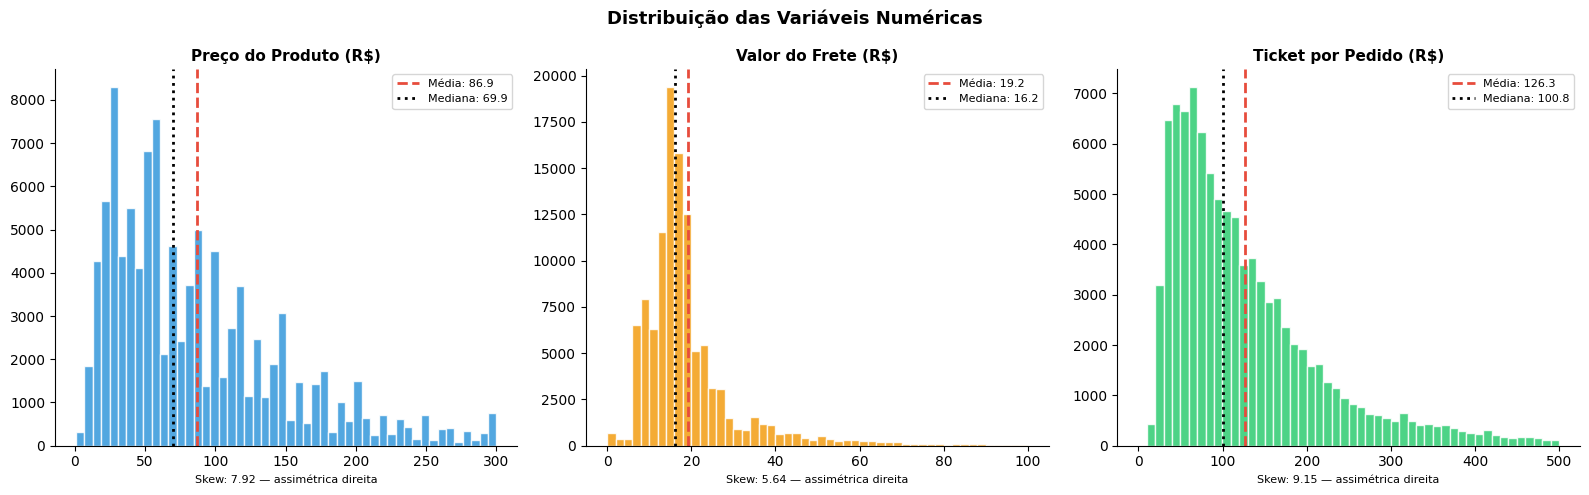


Resumo de Assimetria (Skewness):
Preço: skew=7.92 → use MEDIANA como medida central
Frete: skew=5.64 → use MEDIANA como medida central
Ticket: skew=9.15 → use MEDIANA como medida central


In [20]:
# ── DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS ─────────────────────────────
# Histogramas mostram a forma da distribuição — simétrica ou assimétrica (skewed)
# Analisar distribuição das principais variáveis numéricas
ticket = payments.groupby('order_id')['payment_value'].sum()
frete  = items['freight_value']
preco  = items['price']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variaveis = [
    (preco,   'Preço do Produto (R$)',  300,  CORES[1]),
    (frete,   'Valor do Frete (R$)',    100,  CORES[3]),
    (ticket,  'Ticket por Pedido (R$)', 500,  CORES[0]),
]

for ax, (serie, titulo, limite, cor) in zip(axes, variaveis):
    dados = serie[serie <= limite]
    ax.hist(dados, bins=50, color=cor, edgecolor='white', alpha=0.85)
    ax.axvline(dados.mean(),   color=CORES[2], linewidth=2, linestyle='--',
               label=f'Média: {dados.mean():.1f}')
    ax.axvline(dados.median(), color='black',  linewidth=2, linestyle=':',
               label=f'Mediana: {dados.median():.1f}')
    skew = serie.skew()
    tipo = 'assimétrica direita' if skew > 1 else 'assimétrica esquerda' if skew < -1 else 'aproximadamente normal'
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel(f'Skew: {skew:.2f} — {tipo}', fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nResumo de Assimetria (Skewness):')
for serie, nome in [(preco,'Preço'), (frete,'Frete'), (ticket,'Ticket')]:
    print(f'{nome}: skew={serie.skew():.2f} → use MEDIANA como medida central')

---
## 9. Evolução de Pedidos


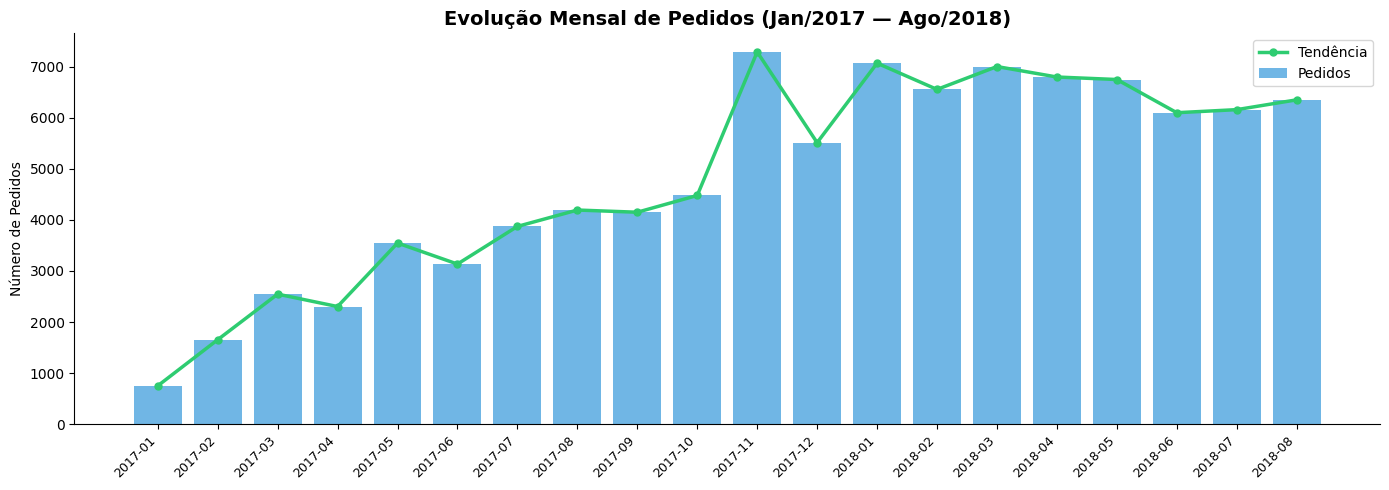

Crescimento no período: 746.8%
Pico: 2017-11


In [23]:
# Filtrar pedidos entregues e agrupar por mês
df_delivered = orders[orders['order_status'] == 'delivered'].copy()
df_delivered['mes_ano'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
pedidos_mes = df_delivered.groupby('mes_ano').size().reset_index(name='pedidos')
pedidos_mes['mes_ano_str'] = pedidos_mes['mes_ano'].astype(str)
pedidos_mes = pedidos_mes[(pedidos_mes['mes_ano_str'] >= '2017-01') &
                           (pedidos_mes['mes_ano_str'] <= '2018-08')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(pedidos_mes)), pedidos_mes['pedidos'], color=CORES[1], alpha=0.7, label='Pedidos')
ax.plot(range(len(pedidos_mes)), pedidos_mes['pedidos'],
        color=CORES[0], linewidth=2.5, marker='o', markersize=5, label='Tendência')
ax.set_xticks(range(len(pedidos_mes)))
ax.set_xticklabels(pedidos_mes['mes_ano_str'], rotation=45, ha='right', fontsize=9)
ax.set_title('Evolução Mensal de Pedidos (Jan/2017 — Ago/2018)', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Pedidos')
ax.legend()
plt.tight_layout()
plt.show()

crescimento = ((pedidos_mes['pedidos'].iloc[-1] / pedidos_mes['pedidos'].iloc[0]) - 1) * 100
print(f'Crescimento no período: {crescimento:.1f}%')
print(f'Pico: {pedidos_mes.loc[pedidos_mes["pedidos"].idxmax(), "mes_ano_str"]}')

> **Conclusão:** os pedidos cresceram de forma consistente ao longo de 2017–2018.


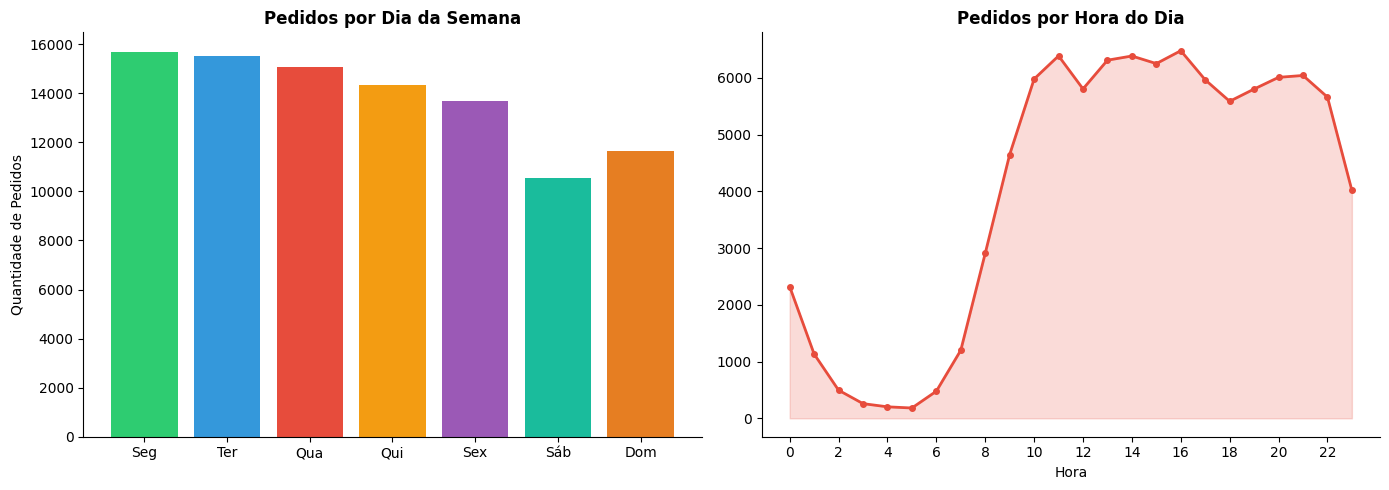

Dia com mais pedidos: Seg
Hora de pico: 16h


In [33]:
# Padrão de compra: dia da semana e hora do dia
df_delivered['dia_semana'] = df_delivered['order_purchase_timestamp'].dt.day_name()
df_delivered['hora'] = df_delivered['order_purchase_timestamp'].dt.hour

ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_pt    = {'Monday':'Seg','Tuesday':'Ter','Wednesday':'Qua',
               'Thursday':'Qui','Friday':'Sex','Saturday':'Sáb','Sunday':'Dom'}

por_dia  = df_delivered['dia_semana'].value_counts().reindex(ordem_dias)
por_hora = df_delivered['hora'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar([dias_pt[d] for d in ordem_dias], por_dia.values, color=CORES[:7])
ax1.set_title('Pedidos por Dia da Semana', fontweight='bold')
ax1.set_ylabel('Quantidade de Pedidos')

ax2.plot(por_hora.index, por_hora.values, color=CORES[2], linewidth=2, marker='o', markersize=4)
ax2.fill_between(por_hora.index, por_hora.values, alpha=0.2, color=CORES[2])
ax2.set_title('Pedidos por Hora do Dia', fontweight='bold')
ax2.set_xlabel('Hora')
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print(f'Dia com mais pedidos: {dias_pt[por_dia.idxmax()]}')
print(f'Hora de pico: {por_hora.idxmax()}h')

> **Conclusão:** segunda-feira é o dia com mais pedidos e o pico de compras acontece entre 11h e 16h, durante o expediente de trabalho. Campanhas e notificações enviadas nesse horário têm maior chance de conversão. Sábado tem 35% menos pedidos que segunda — promoções de fim de semana podem reduzir essa queda.

---
## 10. Categorias de Produtos

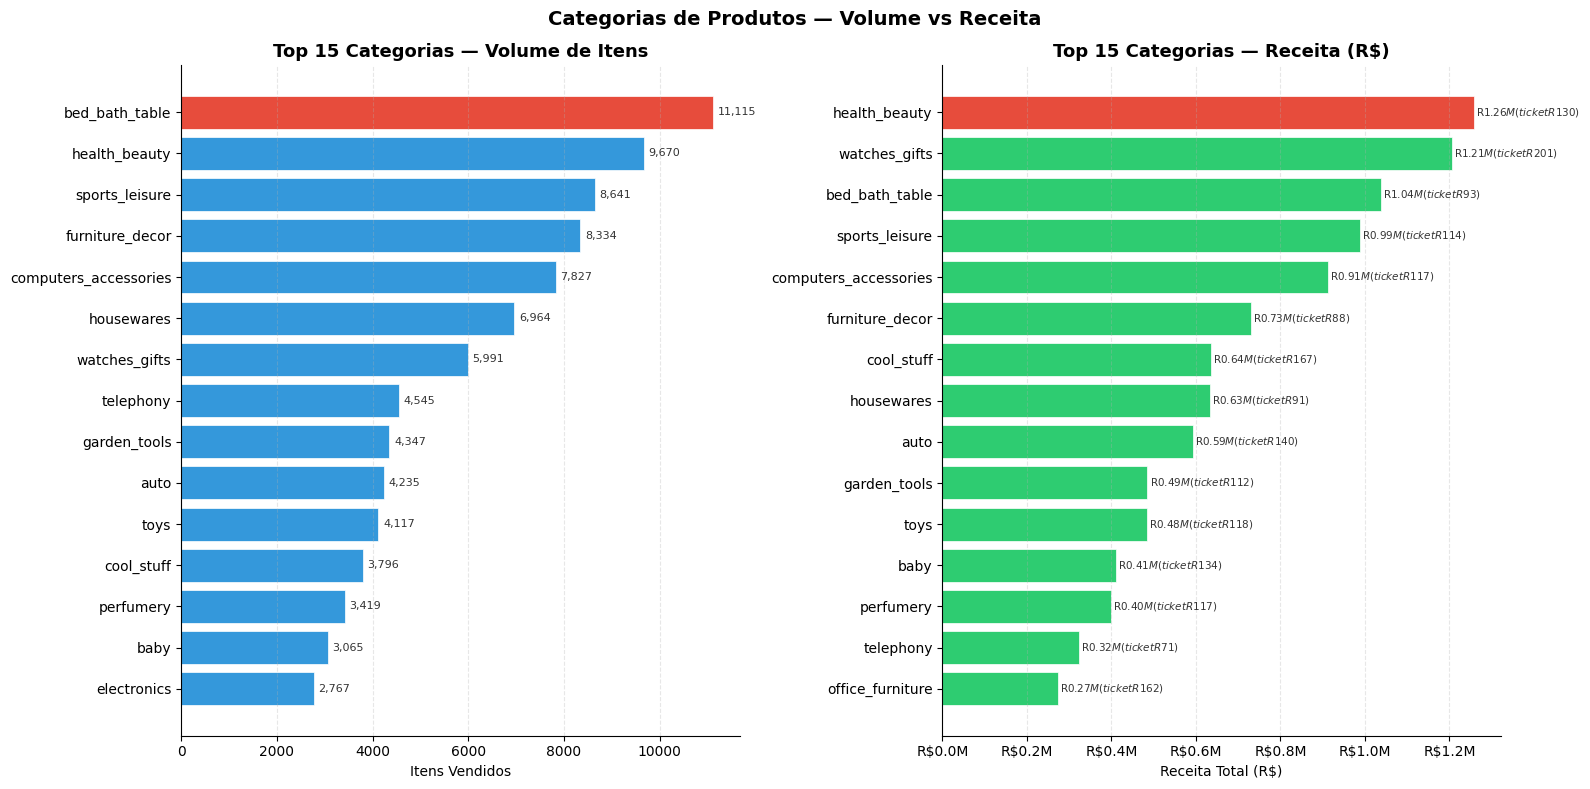

In [29]:
# Cruzar itens + produtos + tradução de categoria
items_prod = items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
items_prod = items_prod.merge(categories, on='product_category_name', how='left')
items_prod['categoria'] = items_prod['product_category_name_english'].fillna(
    items_prod['product_category_name']).fillna('unknown')

top_volume  = items_prod.groupby('categoria').size().nlargest(15).reset_index(name='pedidos')
top_receita = items_prod.groupby('categoria')['price'].sum().nlargest(15).reset_index()
top_receita.columns = ['categoria', 'receita']

# Ticket médio por categoria para contexto
ticket_cat = items_prod.groupby('categoria')['price'].mean().reset_index()
ticket_cat.columns = ['categoria', 'ticket']
top_receita = top_receita.merge(ticket_cat, on='categoria', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Volume — destacar o top 1
cores_vol = [CORES[2] if i == len(top_volume)-1 else CORES[1] for i in range(len(top_volume))]
bars1 = ax1.barh(top_volume['categoria'][::-1], top_volume['pedidos'][::-1],
                 color=cores_vol, edgecolor='white', linewidth=0.5)
ax1.set_title('Top 15 Categorias — Volume de Itens', fontweight='bold', fontsize=13)
ax1.set_xlabel('Itens Vendidos')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
# Valor no final de cada barra
for bar, val in zip(bars1, top_volume['pedidos'][::-1]):
    ax1.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8, color='#333333')

# Receita — destacar o top 1, mostrar ticket médio
cores_rec = [CORES[2] if i == len(top_receita)-1 else CORES[0] for i in range(len(top_receita))]
bars2 = ax2.barh(top_receita['categoria'][::-1], top_receita['receita'][::-1],
                 color=cores_rec, edgecolor='white', linewidth=0.5)
ax2.set_title('Top 15 Categorias — Receita (R$)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Receita Total (R$)')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax2.grid(axis='x', alpha=0.3, linestyle='--')
# Valor + ticket médio no final de cada barra
for bar, (_, row) in zip(bars2, top_receita[::-1].iterrows()):
    ax2.text(row['receita'] + 5000, bar.get_y() + bar.get_height()/2,
             f'R${row["receita"]/1e6:.2f}M  (ticket R${row["ticket"]:.0f})',
             va='center', fontsize=7.5, color='#333333')

plt.suptitle('Categorias de Produtos — Volume vs Receita', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Conclusão:** as categorias que mais vendem não são as que mais faturam. bed/bath/table lidera em volume, mas health_beauty lidera em receita, seguida de watches_gifts e sports_leisure. watches_gifts chama atenção: aparece em 7º em volume mas em 2º em receita sinal de ticket médio alto com menos pedidos. Uma estratégia focada em receita deve priorizar categorias de alto ticket, não necessariamente as de maior volume.

---
## 11. Métodos de Pagamento e Ticket Médio


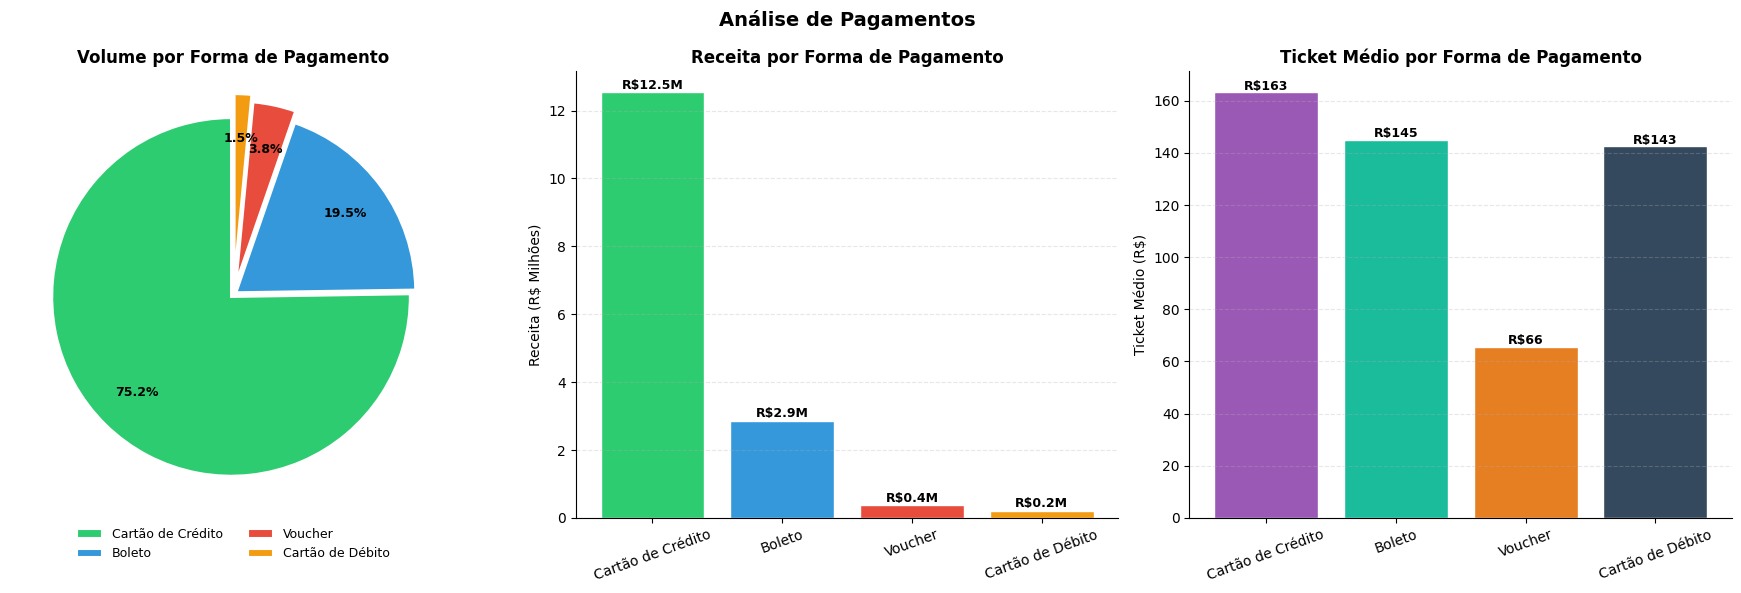

Ticket por Pedido:
Média:         R$160.99  <- influenciada por outliers
Mediana:       R$105.29  <- mais representativa
Desvio Padrão: R$221.95


In [32]:
# Volume, receita e ticket médio por forma de pagamento
pay_tipo = payments[payments['payment_type'] != 'not_defined']
vol_tipo = pay_tipo.groupby('payment_type').agg(
    pedidos      = ('order_id', 'nunique'),
    valor_total  = ('payment_value', 'sum'),
    ticket_medio = ('payment_value', 'mean')
).reset_index().sort_values('pedidos', ascending=False)

nomes_pt = {'credit_card':'Cartão de Crédito','boleto':'Boleto',
            'voucher':'Voucher','debit_card':'Cartão de Débito'}
vol_tipo['nome'] = vol_tipo['payment_type'].map(nomes_pt)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pizza — legenda embaixo para evitar sobreposição nos rótulos pequenos
explode = (0.02, 0.02, 0.08, 0.12)
wedges, texts, autotexts = axes[0].pie(
    vol_tipo['pedidos'],
    labels=None,
    autopct='%1.1f%%',
    colors=CORES[:4],
    startangle=90,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
axes[0].legend(
    wedges, vol_tipo['nome'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2, fontsize=9, frameon=False
)
axes[0].set_title('Volume por Forma de Pagamento', fontweight='bold', fontsize=12)

# Receita
axes[1].bar(vol_tipo['nome'], vol_tipo['valor_total']/1e6, color=CORES[:4], edgecolor='white')
axes[1].set_title('Receita por Forma de Pagamento', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Receita (R$ Milhões)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(vol_tipo['valor_total']):
    axes[1].text(i, v/1e6 + 0.1, f'R${v/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')

# Ticket médio
axes[2].bar(vol_tipo['nome'], vol_tipo['ticket_medio'], color=CORES[4:8], edgecolor='white')
axes[2].set_title('Ticket Médio por Forma de Pagamento', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Ticket Médio (R$)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(vol_tipo['ticket_medio']):
    axes[2].text(i, v + 1, f'R${v:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Análise de Pagamentos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estatísticas do ticket
ticket_pedido = payments.groupby('order_id')['payment_value'].sum()
print('Ticket por Pedido:')
print(f'Média:         R${ticket_pedido.mean():,.2f}  <- influenciada por outliers')
print(f'Mediana:       R${ticket_pedido.median():,.2f}  <- mais representativa')
print(f'Desvio Padrão: R${ticket_pedido.std():,.2f}')

> **Conclusão:** cartão de crédito domina com 75% dos pedidos e R$12.5M em receita. O ticket médio é R$105 bem abaixo da média de R$161, que é puxada para cima por pedidos de alto valor. O desvio padrão de R$222 confirma a alta variação: há clientes gastando muito pouco e outros gastando muito.

---
## 12. Faturamento Trimestral


In [35]:
# Agrupando os pagamentos por order_id para ter o valor total de cada pedido.
# Um pedido pode ter múltiplos pagamentos (ex: parte no crédito, parte no voucher),
# então precisamos somar tudo antes de juntar com os pedidos.
payments_ok = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Filtrando só pedidos entregues e adicionando o valor pago
df_fat = orders[orders['order_status'] == 'delivered'].merge(payments_ok, on='order_id')

# dt.to_period('Q') transforma a data em trimestre — ex: 2017-05-10 vira '2017Q2'
# É muito mais direto do que criar colunas de mês e ano separadas
df_fat['trimestre'] = df_fat['order_purchase_timestamp'].dt.to_period('Q')
df_fat['ano']       = df_fat['order_purchase_timestamp'].dt.year

fat_tri = df_fat.groupby('trimestre')['payment_value'].sum().reset_index()
fat_tri['s'] = fat_tri['trimestre'].astype(str)

# Removendo trimestres incompletos (2016 e Q3/2018 têm poucos meses de dados)
fat_tri = fat_tri[(fat_tri['s'] >= '2017Q1') & (fat_tri['s'] <= '2018Q2')].reset_index(drop=True)

# Variação percentual de um trimestre para o outro — mostra ritmo de crescimento
fat_tri['variacao_pct'] = fat_tri['payment_value'].pct_change() * 100

print('Faturamento por Trimestre:')
for _, row in fat_tri.iterrows():
    var = f"({row['variacao_pct']:+.0f}% vs anterior)" if not pd.isna(row['variacao_pct']) else '(base)'
    print(f"   {row['s']}: R${row['payment_value']/1e6:.2f}M  {var}")

base = fat_tri['payment_value'].iloc[0]
crescimento_total = (fat_tri['payment_value'].iloc[-1] / base - 1) * 100
print(f'\nCrescimento total Q1/2017 → Q2/2018: {crescimento_total:.0f}%')

Faturamento por Trimestre:
   2017Q1: R$0.81M  (base)
   2017Q2: R$1.45M  (+78% vs anterior)
   2017Q3: R$1.91M  (+32% vs anterior)
   2017Q4: R$2.75M  (+44% vs anterior)
   2018Q1: R$3.17M  (+15% vs anterior)
   2018Q2: R$3.27M  (+3% vs anterior)

Crescimento total Q1/2017 → Q2/2018: 303%


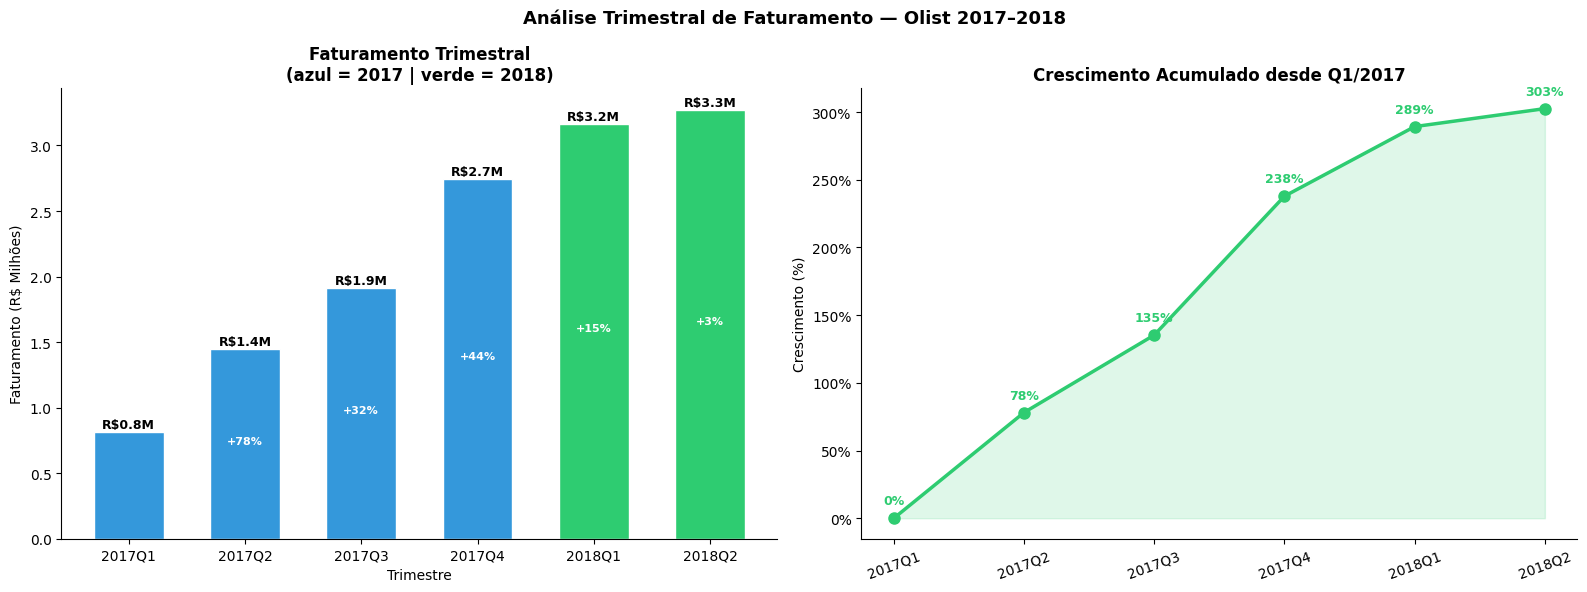

O crescimento é consistente e acelerado — sem quedas trimestrais no período analisado.
Isso indica que o Olist estava em fase de expansão saudável, não de flutuação.


In [37]:
# Visualização em dois painéis:
# Esquerdo → volume absoluto de cada trimestre com a variação dentro da barra
# Direito  → crescimento acumulado desde o Q1/2017 (linha)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diferenciando visualmente 2017 e 2018 pela cor das barras
cores_bar = [CORES[1] if '2017' in s else CORES[0] for s in fat_tri['s']]
bars = axes[0].bar(fat_tri['s'], fat_tri['payment_value']/1e6,
                   color=cores_bar, edgecolor='white', width=0.6)
axes[0].set_title('Faturamento Trimestral\n(azul = 2017 | verde = 2018)',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Faturamento (R$ Milhões)')
axes[0].set_xlabel('Trimestre')

for bar, val, var in zip(bars, fat_tri['payment_value'], fat_tri['variacao_pct']):
    h = bar.get_height()
    # Valor total acima da barra
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.03,
                 f'R${val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')
    # Variação percentual dentro da barra (só a partir do segundo trimestre)
    if not np.isnan(var):
        axes[0].text(bar.get_x()+bar.get_width()/2, h/2,
                     f'{var:+.0f}%', ha='center', fontsize=8,
                     color='white', fontweight='bold')

# Linha de crescimento acumulado
fat_tri['crescimento'] = (fat_tri['payment_value'] / fat_tri['payment_value'].iloc[0] - 1) * 100
axes[1].plot(fat_tri['s'], fat_tri['crescimento'],
             color=CORES[0], linewidth=2.5, marker='o', markersize=8)
axes[1].fill_between(range(len(fat_tri)), fat_tri['crescimento'], alpha=0.15, color=CORES[0])
axes[1].set_title('Crescimento Acumulado desde Q1/2017', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Crescimento (%)')
axes[1].set_xticks(range(len(fat_tri)))
axes[1].set_xticklabels(fat_tri['s'], rotation=20)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
for i, v in enumerate(fat_tri['crescimento']):
    axes[1].annotate(f'{v:.0f}%', (i, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9,
                     fontweight='bold', color=CORES[0])

plt.suptitle('Análise Trimestral de Faturamento — Olist 2017–2018',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('O crescimento é consistente e acelerado — sem quedas trimestrais no período analisado.')
print('Isso indica que o Olist estava em fase de expansão saudável, não de flutuação.')

> **Conclusão:** crescimento de 303% de Q1/2017 a Q2/2018, sem nenhuma queda trimestral no período.


---
## 13. Sazonalidade


In [39]:
# Extraindo o mês de cada compra para análise de sazonalidade
df_fat['mes'] = df_fat['order_purchase_timestamp'].dt.month

# Dicionário de tradução para os rótulos do gráfico
meses_pt = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

# Faturamento total por mês (somando 2017 e 2018)
por_mes = df_fat.groupby('mes')['payment_value'].sum()

# Separando por ano para ver se o padrão de sazonalidade se repete
por_mes_ano = df_fat.groupby(['mes','ano'])['payment_value'].sum().reset_index()

print('Faturamento total por mês:')
for mes, val in por_mes.items():
    destaque = ' ← pico' if mes == por_mes.idxmax() else ' ← vale' if mes == por_mes.idxmin() else ''
    print(f'   {meses_pt[mes]:4s}: R${val/1e6:.2f}M{destaque}')

Faturamento total por mês:
   Jan : R$1.21M
   Fev : R$1.24M
   Mar : R$1.54M
   Abr : R$1.52M
   Mai : R$1.70M ← pico
   Jun : R$1.50M
   Jul : R$1.59M
   Ago : R$1.63M
   Set : R$0.70M ← vale
   Out : R$0.80M
   Nov : R$1.15M
   Dez : R$0.84M


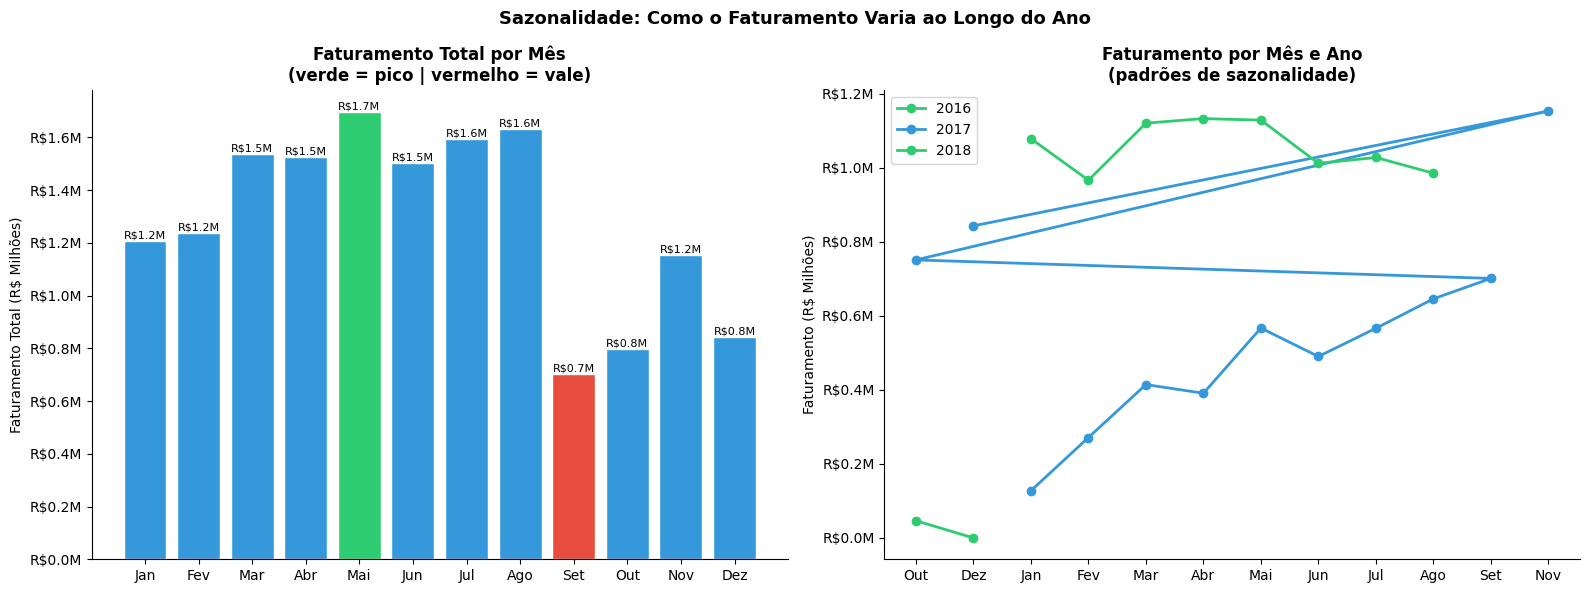

Maio é o mês de maior faturamento — provavelmente impulsionado pelo Dia das Mães.
Setembro registra o vale, possivelmente por ser pós-férias e pré-Black Friday.
O padrão entre 2017 e 2018 é similar, confirmando que há sazonalidade real.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colorindo o pico (verde) e o vale (vermelho), resto em azul
cores_mes = [CORES[2] if v == por_mes.min() else
             CORES[0] if v == por_mes.max() else CORES[1]
             for v in por_mes.values]

bars = axes[0].bar([meses_pt[m] for m in por_mes.index],
                   por_mes.values/1e6, color=cores_mes, edgecolor='white')
axes[0].set_title('Faturamento Total por Mês\n(verde = pico | vermelho = vale)',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Faturamento Total (R$ Milhões)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'R${v:.1f}M'))
for bar, v in zip(bars, por_mes.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'R${v/1e6:.1f}M', ha='center', fontsize=8)

# Linha por ano — se o formato for parecido, é sazonalidade confirmada
for ano, grp in por_mes_ano.groupby('ano'):
    grp = grp.sort_values('mes')
    cor  = CORES[1] if ano == 2017 else CORES[0]
    axes[1].plot([meses_pt[m] for m in grp['mes']], grp['payment_value']/1e6,
                 marker='o', linewidth=2, markersize=6, label=str(ano), color=cor)
axes[1].set_title('Faturamento por Mês e Ano\n(padrões de sazonalidade)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Faturamento (R$ Milhões)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'R${v:.1f}M'))
axes[1].legend()

plt.suptitle('Sazonalidade: Como o Faturamento Varia ao Longo do Ano',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Maio é o mês de maior faturamento — provavelmente impulsionado pelo Dia das Mães.')
print(f'Setembro registra o vale, possivelmente por ser pós-férias e pré-Black Friday.')
print(f'O padrão entre 2017 e 2018 é similar, confirmando que há sazonalidade real.')

> **Conclusão:** maio é o mês de pico (Dia das Mães) e setembro o de menor faturamento. O padrão se repetiu em 2017 e 2018.


---
## 14. Satisfação dos Clientes — NPS

NPS Simplificado = % Promotores (nota 5) − % Detratores (notas 1, 2, 3)


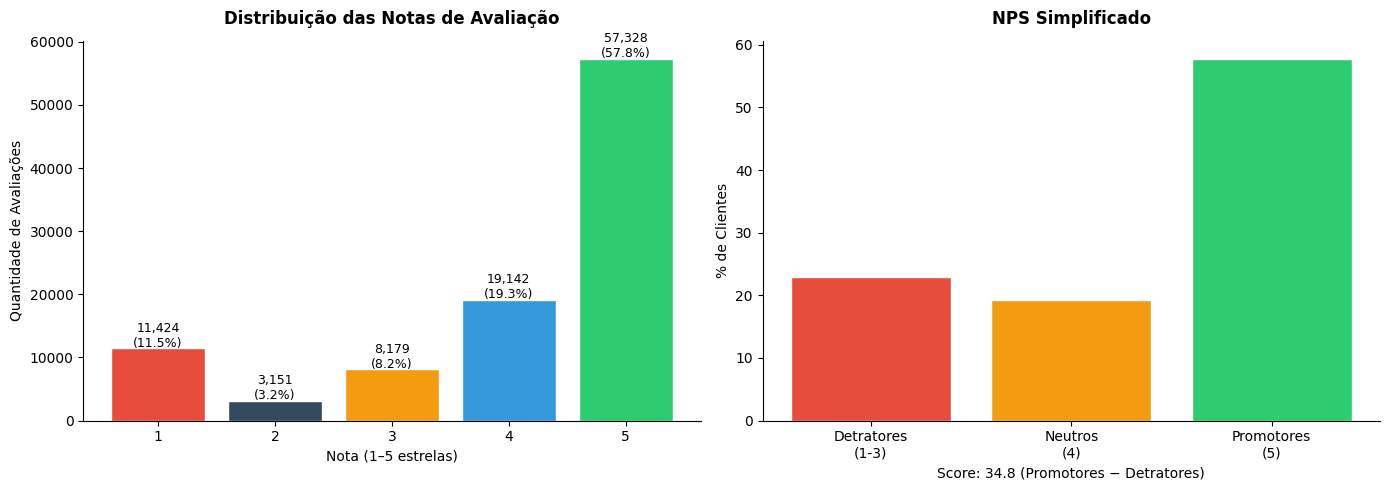

Nota média: 4.09/5.0
NPS: 34.8 → positivo


In [46]:
# Distribuição das notas e NPS
score_dist = reviews['review_score'].value_counts().sort_index()
total = score_dist.sum()

promotores = score_dist[5] / total * 100
neutros    = score_dist[4] / total * 100
detratores = (score_dist[1] + score_dist[2] + score_dist[3]) / total * 100
nps        = promotores - detratores

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cores_score = [CORES[2], CORES[7], CORES[3], CORES[1], CORES[0]]
bars = ax1.bar(score_dist.index, score_dist.values, color=cores_score, edgecolor='white')
ax1.set_title('Distribuição das Notas de Avaliação', fontweight='bold', pad=12)
ax1.set_xlabel('Nota (1–5 estrelas)')
ax1.set_ylabel('Quantidade de Avaliações')
for bar, v in zip(bars, score_dist.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=9)

ax2.bar(['Detratores\n(1-3)', 'Neutros\n(4)', 'Promotores\n(5)'],
        [detratores, neutros, promotores],
        color=[CORES[2], CORES[3], CORES[0]], edgecolor='white')
ax2.set_title(f'NPS Simplificado', fontweight='bold', pad=12)
ax2.set_xlabel(f'Score: {nps:.1f} (Promotores − Detratores)', fontsize=10)
ax2.set_ylabel('% de Clientes')

plt.tight_layout()
plt.show()

print(f'Nota média: {reviews["review_score"].mean():.2f}/5.0')
print(f'NPS: {nps:.1f} → {"positivo" if nps > 0 else "negativo ❌"}')

> **Conclusão:** 57% dos clientes deram nota 5, com NPS de +34.8. O principal motivo de insatisfação são os pedidos atrasados.


---
## 15. Performance Logística


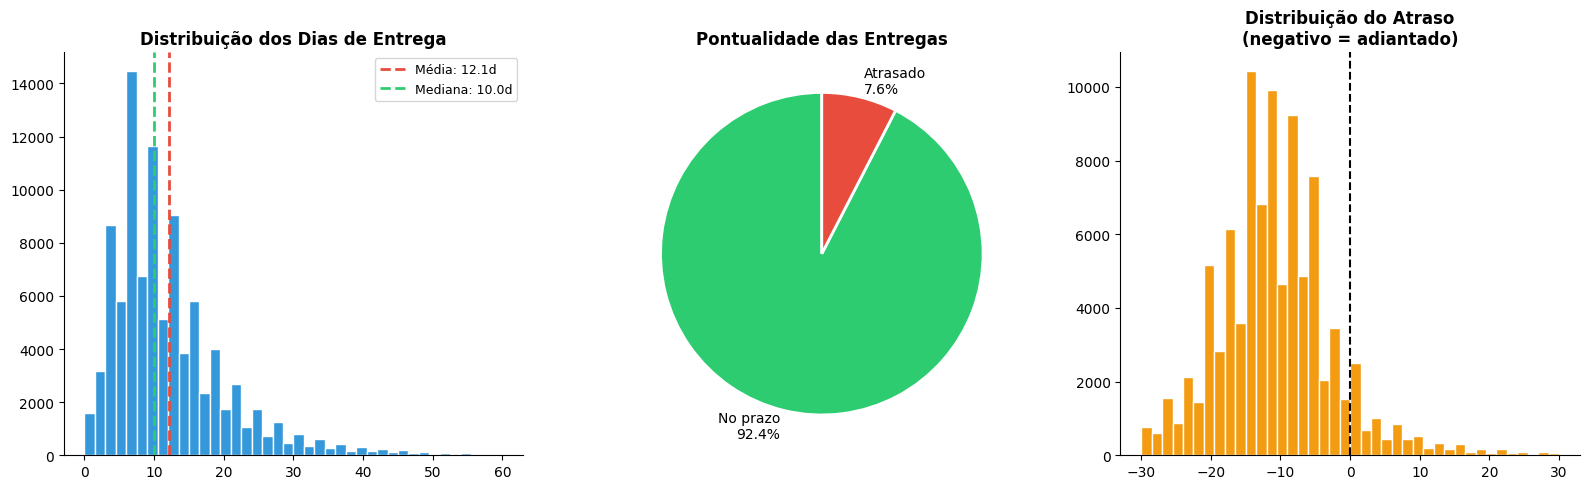

In [47]:
# Calcular tempo de entrega e identificar atrasos
df_log = orders[orders['order_status'] == 'delivered'].copy()
df_log = df_log.dropna(subset=['order_delivered_customer_date','order_estimated_delivery_date'])

df_log['dias_entrega']  = (df_log['order_delivered_customer_date'] - df_log['order_purchase_timestamp']).dt.days
df_log['dias_estimados']= (df_log['order_estimated_delivery_date'] - df_log['order_purchase_timestamp']).dt.days
df_log['atraso']  = df_log['dias_entrega'] - df_log['dias_estimados']
df_log['atrasou'] = df_log['atraso'] > 0

pct_atraso    = df_log['atrasou'].mean() * 100
pct_adiantado = (df_log['atraso'] <= 0).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df_log[df_log['dias_entrega']<=60]['dias_entrega'], bins=40, color=CORES[1], edgecolor='white')
axes[0].axvline(df_log['dias_entrega'].mean(),   color=CORES[2], linewidth=2, linestyle='--',
                label=f'Média: {df_log["dias_entrega"].mean():.1f}d')
axes[0].axvline(df_log['dias_entrega'].median(), color=CORES[0], linewidth=2, linestyle='--',
                label=f'Mediana: {df_log["dias_entrega"].median():.1f}d')
axes[0].set_title('Distribuição dos Dias de Entrega', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].pie([pct_adiantado, pct_atraso],
            labels=[f'No prazo\n{pct_adiantado:.1f}%', f'Atrasado\n{pct_atraso:.1f}%'],
            colors=[CORES[0], CORES[2]], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Pontualidade das Entregas', fontweight='bold')

atraso_f = df_log[df_log['atraso'].between(-30,30)]['atraso']
axes[2].hist(atraso_f, bins=40, color=CORES[3], edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_title('Distribuição do Atraso\n(negativo = adiantado)', fontweight='bold')

plt.tight_layout()
plt.show()

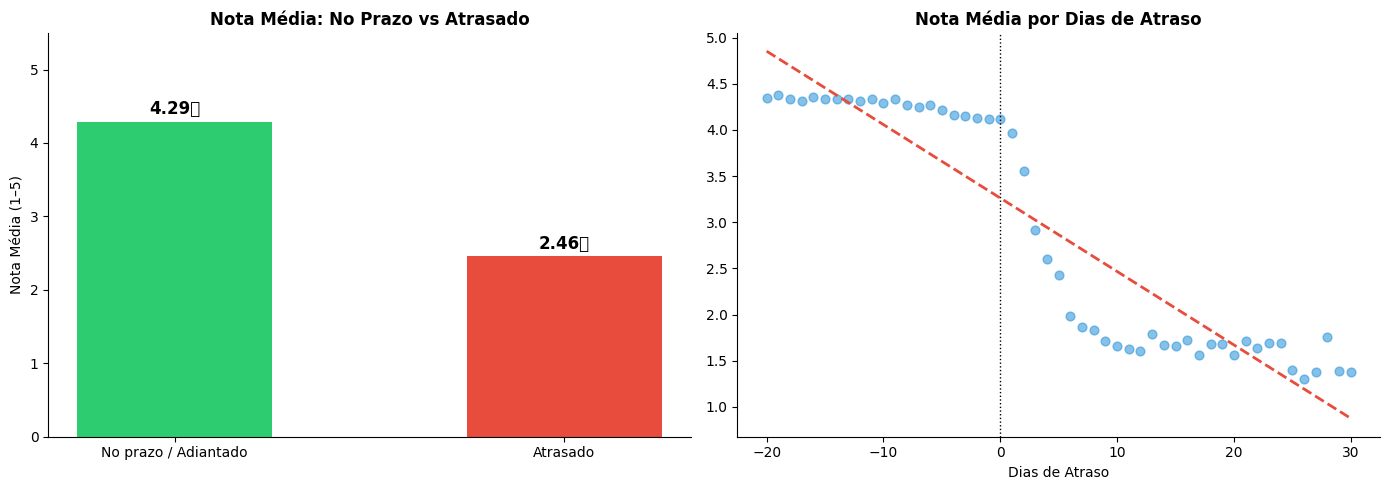

INSIGHT-CHAVE:
Nota (no prazo):  4.29
Nota (atrasado):  2.46
Diferença:        -1.83 pontos → atraso destrói a satisfação!


In [51]:
#Correlação entre atraso e nota do cliente
df_log_rev = df_log.merge(reviews[['order_id','review_score']], on='order_id', how='inner')
media_nota  = df_log_rev.groupby('atrasou')['review_score'].mean()
nota_atraso = df_log_rev.groupby('atraso')['review_score'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(['No prazo / Adiantado', 'Atrasado'],
               [media_nota[False], media_nota[True]],
               color=[CORES[0], CORES[2]], width=0.5)
ax1.set_ylim(0, 5.5)
ax1.set_title('Nota Média: No Prazo vs Atrasado', fontweight='bold')
ax1.set_ylabel('Nota Média (1–5)')
for bar, v in zip(bars, [media_nota[False], media_nota[True]]):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}⭐',
             ha='center', fontsize=12, fontweight='bold')

filtro = nota_atraso[nota_atraso['atraso'].between(-20, 30)]
ax2.scatter(filtro['atraso'], filtro['review_score'], alpha=0.6, color=CORES[1], s=40)
z = np.polyfit(filtro['atraso'], filtro['review_score'], 1)
ax2.plot(filtro['atraso'], np.poly1d(z)(filtro['atraso']), color=CORES[2], linewidth=2, linestyle='--')
ax2.axvline(0, color='black', linewidth=1, linestyle=':')
ax2.set_title('Nota Média por Dias de Atraso', fontweight='bold')
ax2.set_xlabel('Dias de Atraso')

plt.tight_layout()
plt.show()

dif = media_nota[False] - media_nota[True]
print(f'INSIGHT-CHAVE:')
print(f'Nota (no prazo):  {media_nota[False]:.2f}')
print(f'Nota (atrasado):  {media_nota[True]:.2f}')
print(f'Diferença:        -{dif:.2f} pontos → atraso destrói a satisfação!')

> **Conclusão:** pedidos atrasados têm nota média de 2.46 contra 4.29 dos pedidos no prazo uma queda de 1.83 pontos. Com apenas 7.6% de atrasos, o impacto no NPS é desproporcional.


---
## 16. Entregas Adiantadas

Além dos atrasos, vale entender o outro lado: quantos pedidos chegam antes do prazo? Entregas adiantadas tendem a surpreender positivamente o cliente e contribuem para notas mais altas.


Distribuição de pontualidade:
  Adiantado:  91.0%  (média de 13.2 dias antes)
  No prazo:   1.4%
  Atrasado:   7.6%

Nota média por pontualidade:
  Adiantado:  4.29★
  No prazo:   4.12★
  Atrasado:   2.46★


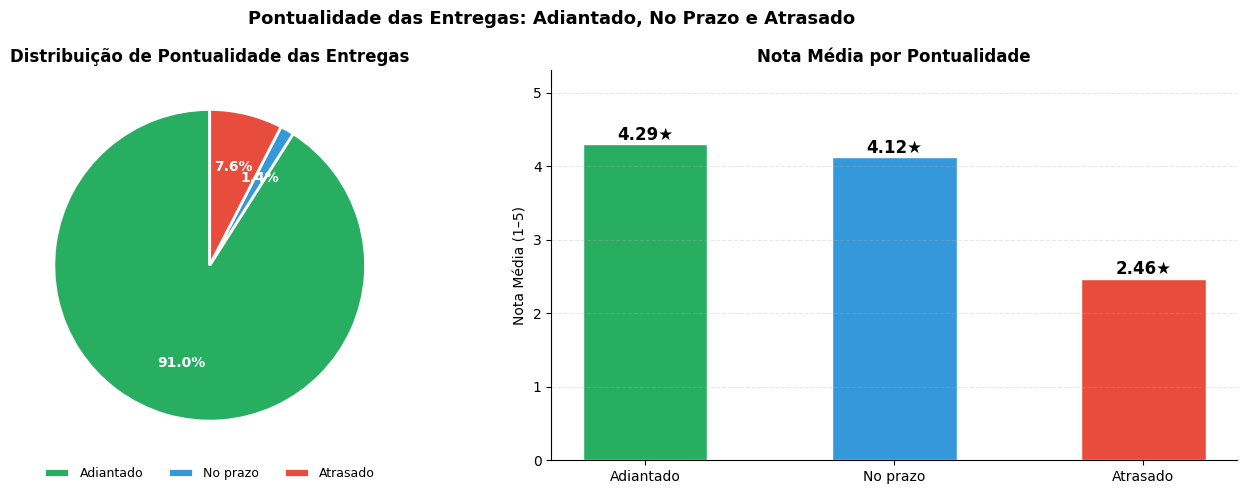

In [52]:
# Entregas adiantadas — pedidos que chegaram antes do prazo estimado
df_log['adiantado'] = df_log['atraso'] < 0
df_log['dias_adiantado'] = df_log['atraso'].clip(upper=0).abs()

pct_adiantado = df_log['adiantado'].mean() * 100
pct_no_prazo  = ((df_log['atraso'] == 0)).mean() * 100
pct_atrasado  = df_log['atrasou'].mean() * 100
media_adiant  = df_log[df_log['adiantado']]['dias_adiantado'].mean()

print('Distribuição de pontualidade:')
print(f'  Adiantado:  {pct_adiantado:.1f}%  (média de {media_adiant:.1f} dias antes)')
print(f'  No prazo:   {pct_no_prazo:.1f}%')
print(f'  Atrasado:   {pct_atrasado:.1f}%')

# Nota média por grupo
nota_adiant = df_log_rev[df_log_rev['atraso'] < 0]['review_score'].mean()
nota_prazo  = df_log_rev[df_log_rev['atraso'] == 0]['review_score'].mean()
nota_atras  = df_log_rev[df_log_rev['atrasou']]['review_score'].mean()

print(f'\nNota média por pontualidade:')
print(f'  Adiantado:  {nota_adiant:.2f}★')
print(f'  No prazo:   {nota_prazo:.2f}★')
print(f'  Atrasado:   {nota_atras:.2f}★')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pizza: adiantado / no prazo / atrasado
grupos = ['Adiantado', 'No prazo', 'Atrasado']
vals   = [pct_adiantado, pct_no_prazo, pct_atrasado]
cores_g = ['#27AE60', '#3498DB', '#E74C3C']
wedges, _, autotexts = axes[0].pie(
    vals, labels=None, autopct='%1.1f%%',
    colors=cores_g, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    pctdistance=0.65
)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
axes[0].legend(wedges, grupos, loc='lower center', bbox_to_anchor=(0.5,-0.08), ncol=3, fontsize=9, frameon=False)
axes[0].set_title('Distribuição de Pontualidade das Entregas', fontweight='bold', fontsize=12)

# Nota por grupo
notas_g = [nota_adiant, nota_prazo, nota_atras]
bars = axes[1].bar(grupos, notas_g, color=cores_g, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 5.3)
axes[1].set_title('Nota Média por Pontualidade', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nota Média (1–5)')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(bars, notas_g):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.07, f'{v:.2f}★',
                 ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Pontualidade das Entregas: Adiantado, No Prazo e Atrasado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **Conclusão:** a maioria dos pedidos chega adiantada e clientes que recebem antes do prazo dão notas mais altas do que os que recebem exatamente no prazo. Isso indica que antecipar a entrega tem mais impacto na satisfação do que apenas cumprir o prazo prometido.

---
## 17. Tempo de Aprovação do Pedido

O tempo entre a compra e a aprovação do pagamento impacta o prazo de entrega. Pedidos que demoram para ser aprovados saem atrasados antes mesmo de serem enviados.


In [65]:
# Calculando o tempo entre a compra e a aprovação do pagamento
# O resultado é um timedelta, convertemos para horas dividindo por 3600 segundos
orders['tempo_aprov_h'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Removendo valores negativos (erros de data) e outliers extremos (> 7 dias)
# Na prática, aprovações > 7 dias são casos muito específicos (ex: boleto vencido)
val = orders['tempo_aprov_h'].dropna()
val = val[(val >= 0) & (val <= 168)]

print('Estatísticas do tempo de aprovação:')
print(f'Mediana:       {val.median():.1f}h  ← metade dos pedidos aprovados nesse tempo')
print(f'Até 1 hora:    {(val<=1).mean()*100:.1f}%  ← provavelmente cartão de crédito/débito')
print(f'1h a 24h:      {((val>1)&(val<=24)).mean()*100:.1f}%')
print(f'Mais de 24h:   {(val>24).mean()*100:.1f}%  ← provavelmente boleto bancário')

# Classificando em faixas para análise mais clara
bins   = [0, 1, 6, 24, 48, 168]
labels = ['até 1h', '1–6h', '6–24h', '24–48h', '48h+']
orders['faixa_aprov'] = pd.cut(orders['tempo_aprov_h'], bins=bins, labels=labels)
dist_aprov = orders['faixa_aprov'].value_counts().reindex(labels)

Estatísticas do tempo de aprovação:
Mediana:       0.3h  ← metade dos pedidos aprovados nesse tempo
Até 1 hora:    63.9%  ← provavelmente cartão de crédito/débito
1h a 24h:      18.6%
Mais de 24h:   17.5%  ← provavelmente boleto bancário


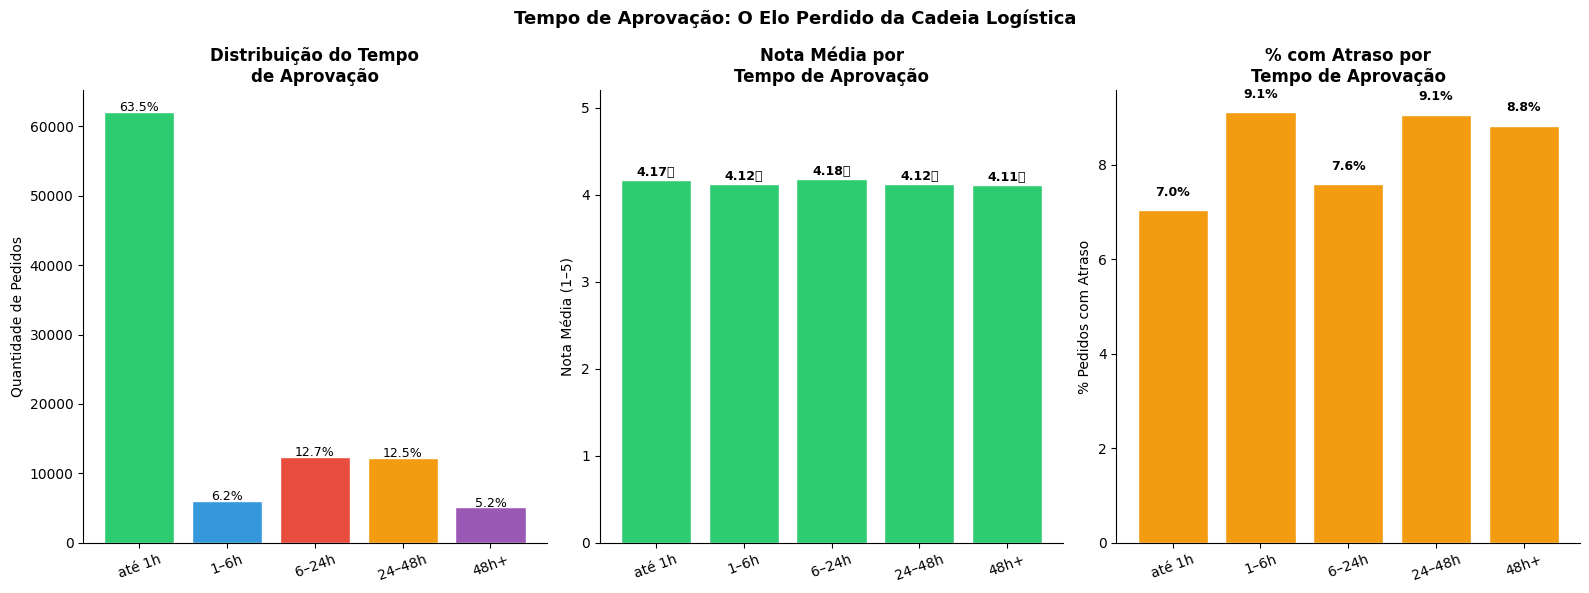

Pedidos que demoram 48h+ para ser aprovados têm:
Mais atrasos na entrega
Notas mais baixas dos clientes
Isso reforça que o problema logístico começa antes do envio.


In [67]:
# Cruzando tempo de aprovação com nota e atraso na entrega
ordr2 = orders.merge(reviews[['order_id','review_score']], on='order_id', how='left')
ordr2 = ordr2[ordr2['order_status'] == 'delivered'].copy()

ordr2['dias_entrega'] = (
    ordr2['order_delivered_customer_date'] - ordr2['order_purchase_timestamp']
).dt.days
ordr2['dias_est'] = (
    ordr2['order_estimated_delivery_date'] - ordr2['order_purchase_timestamp']
).dt.days
ordr2['atrasou'] = ordr2['dias_entrega'] > ordr2['dias_est']

res_aprov = ordr2.groupby('faixa_aprov', observed=True).agg(
    pedidos    = ('order_id', 'count'),
    nota_media = ('review_score', 'mean'),
    pct_atraso = ('atrasou', 'mean')
).reset_index().dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Distribuição das faixas
bars = axes[0].bar(dist_aprov.index, dist_aprov.values, color=CORES[:5], edgecolor='white')
axes[0].set_title('Distribuição do Tempo\nde Aprovação', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Quantidade de Pedidos')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, dist_aprov.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{v/dist_aprov.sum()*100:.1f}%', ha='center', fontsize=9)

# Nota média por faixa
cores_n = [CORES[0] if n >= 4.1 else CORES[3] if n >= 3.9 else CORES[2]
           for n in res_aprov['nota_media']]
bars2 = axes[1].bar(res_aprov['faixa_aprov'], res_aprov['nota_media'],
                    color=cores_n, edgecolor='white')
axes[1].set_ylim(0, 5.2)
axes[1].set_title('Nota Média por\nTempo de Aprovação', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nota Média (1–5)')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, res_aprov['nota_media']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05,
                 f'{v:.2f}⭐', ha='center', fontsize=9, fontweight='bold')

# % de atraso por faixa
cores_a = [CORES[0] if p <= 0.06 else CORES[3] if p <= 0.10 else CORES[2]
           for p in res_aprov['pct_atraso']]
bars3 = axes[2].bar(res_aprov['faixa_aprov'], res_aprov['pct_atraso']*100,
                    color=cores_a, edgecolor='white')
axes[2].set_title('% com Atraso por\nTempo de Aprovação', fontweight='bold', fontsize=12)
axes[2].set_ylabel('% Pedidos com Atraso')
axes[2].tick_params(axis='x', rotation=20)
for bar, v in zip(bars3, res_aprov['pct_atraso']):
    axes[2].text(bar.get_x()+bar.get_width()/2, v*100+0.3,
                 f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Tempo de Aprovação: O Elo Perdido da Cadeia Logística',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Pedidos que demoram 48h+ para ser aprovados têm:')
print(f'Mais atrasos na entrega')
print(f'Notas mais baixas dos clientes')
print(f'Isso reforça que o problema logístico começa antes do envio.')

> **Conclusão:** 64% dos pedidos são aprovados em até 1 hora (cartão/débito). Os 17.5% com aprovação acima de 24h (boleto) chegam com mais atraso e nota mais baixa.


---
## 18. Gargalo Logístico — Lead Time por Etapa

O tempo total de entrega tem 3 etapas: aprovação do pagamento, postagem pelo vendedor e transporte. Qual etapa causa os atrasos?


In [69]:
# Calcular o tempo de cada etapa logística
df_lead = orders[orders['order_status'] == 'delivered'].copy()
df_lead = df_lead.dropna(subset=[
    'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
])

# Cada etapa = diferença entre datas consecutivas, convertida para dias
df_lead['t_aprovacao']  = (df_lead['order_approved_at'] -
                            df_lead['order_purchase_timestamp']).dt.total_seconds() / 86400

df_lead['t_postagem']   = (df_lead['order_delivered_carrier_date'] -
                            df_lead['order_approved_at']).dt.total_seconds() / 86400

df_lead['t_transporte'] = (df_lead['order_delivered_customer_date'] -
                            df_lead['order_delivered_carrier_date']).dt.total_seconds() / 86400

df_lead['t_total']      = (df_lead['order_delivered_customer_date'] -
                            df_lead['order_purchase_timestamp']).dt.total_seconds() / 86400

df_lead['dias_est']     = (df_lead['order_estimated_delivery_date'] -
                            df_lead['order_purchase_timestamp']).dt.total_seconds() / 86400

df_lead['atrasou']      = df_lead['t_total'] > df_lead['dias_est']

# Remover registros com inconsistências de data (tempos negativos = erro de sistema)
# São apenas 1,4% dos pedidos — removemos para não distorcer a análise
df_lead = df_lead[
    (df_lead['t_aprovacao'] >= 0) &
    (df_lead['t_postagem']  >= 0) &
    (df_lead['t_transporte']>= 0)
]

print('Lead Time médio por etapa logística:')
print(f"   Aprovação:   {df_lead['t_aprovacao'].mean():.1f} dias  ({df_lead['t_aprovacao'].mean()/df_lead['t_total'].mean()*100:.0f}% do total)")
print(f"   Postagem:    {df_lead['t_postagem'].mean():.1f} dias  ({df_lead['t_postagem'].mean()/df_lead['t_total'].mean()*100:.0f}% do total)")
print(f"   Transporte:  {df_lead['t_transporte'].mean():.1f} dias  ({df_lead['t_transporte'].mean()/df_lead['t_total'].mean()*100:.0f}% do total)")
print(f"   TOTAL:       {df_lead['t_total'].mean():.1f} dias")

prazo = df_lead[~df_lead['atrasou']]
atras = df_lead[df_lead['atrasou']]

print(f'\nComparação No Prazo vs Atrasado:')
for col, nome in [('t_aprovacao','Aprovação'),('t_postagem','Postagem'),('t_transporte','Transporte'),('t_total','TOTAL')]:
    mp = prazo[col].mean(); ma = atras[col].mean()
    pct = (ma/mp-1)*100
    print(f"   {nome:12s}: no prazo={mp:.1f}d | atrasado={ma:.1f}d | +{pct:.0f}%")

Lead Time médio por etapa logística:
   Aprovação:   0.4 dias  (3% do total)
   Postagem:    2.9 dias  (23% do total)
   Transporte:  9.4 dias  (74% do total)
   TOTAL:       12.6 dias

Comparação No Prazo vs Atrasado:
   Aprovação   : no prazo=0.4d | atrasado=0.5d | +28%
   Postagem    : no prazo=2.6d | atrasado=5.3d | +103%
   Transporte  : no prazo=7.9d | atrasado=25.7d | +225%
   TOTAL       : no prazo=10.9d | atrasado=31.5d | +188%


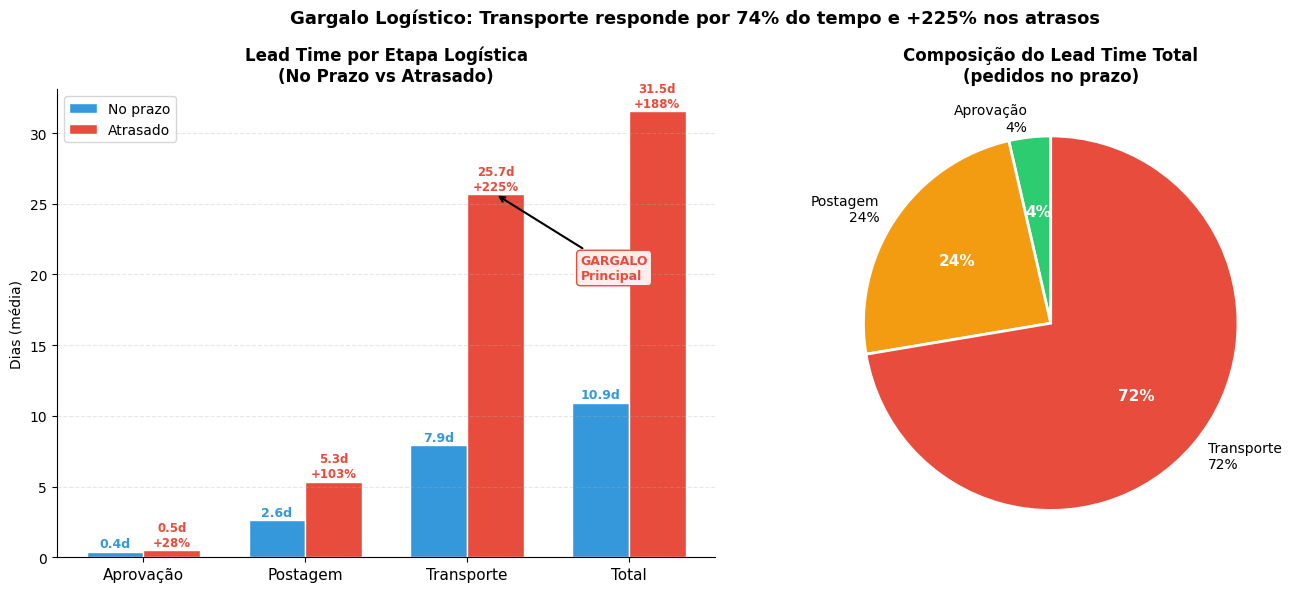

In [70]:
# Visualização: Lead time por etapa — no prazo vs atrasado + composição percentual
etapas  = ['Aprovação', 'Postagem', 'Transporte', 'Total']
prazo_m = [prazo[c].mean() for c in ['t_aprovacao','t_postagem','t_transporte','t_total']]
atras_m = [atras[c].mean() for c in ['t_aprovacao','t_postagem','t_transporte','t_total']]
aumento = [(a/p-1)*100 for a,p in zip(atras_m,prazo_m)]

x = np.arange(len(etapas)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(x-w/2, prazo_m, w, label='No prazo', color=CORES[1], edgecolor='white')
bars2 = axes[0].bar(x+w/2, atras_m, w, label='Atrasado',  color=CORES[2], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(etapas, fontsize=11)
axes[0].set_title('Lead Time por Etapa Logística\n(No Prazo vs Atrasado)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Dias (média)')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(bars1, prazo_m):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}d', ha='center', fontsize=9, fontweight='bold', color=CORES[1])
for bar, v, a in zip(bars2, atras_m, aumento):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}d\n+{a:.0f}%', ha='center', fontsize=8.5, fontweight='bold', color=CORES[2])
axes[0].annotate('GARGALO\nPrincipal', xy=(2+w/2, atras_m[2]),
    xytext=(2.7, atras_m[2]-6),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=9, fontweight='bold', color=CORES[2],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDEDEC', edgecolor=CORES[2]))

# Pizza da composição percentual
vals_pct = [prazo_m[0]/prazo_m[3]*100, prazo_m[1]/prazo_m[3]*100, prazo_m[2]/prazo_m[3]*100]
labs_pct  = [f'Aprovação\n{vals_pct[0]:.0f}%', f'Postagem\n{vals_pct[1]:.0f}%', f'Transporte\n{vals_pct[2]:.0f}%']
wedges, _, autotexts = axes[1].pie(vals_pct, labels=labs_pct,
    colors=[CORES[0], CORES[3], CORES[2]], autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title('Composição do Lead Time Total\n(pedidos no prazo)', fontweight='bold', fontsize=12)

plt.suptitle('Gargalo Logístico: Transporte responde por 74% do tempo e +225% nos atrasos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Conclusão:** o transporte é responsável por 74% do tempo total de entrega e é onde os atrasos se concentram vai de 7.9 dias (pedidos no prazo) para 25.7 dias nos atrasados (+225%). Aprovação e postagem têm impacto pequeno em comparação. Melhorar a malha de distribuição e criar hubs logísticos regionais é a ação com maior potencial de reduzir atrasos.


---
## 19. Limiar de Tolerância do Cliente

A queda na satisfação por atraso é gradual ou tem um ponto de ruptura? Se houver um limiar, a estratégia muda: o foco não é "reduzir atrasos em geral" mas "evitar atrasos acima de X dias".


In [72]:
# Cruzar pedidos com reviews e calcular o atraso real em dias
df_lim = df_lead.merge(reviews[['order_id','review_score']], on='order_id', how='left').dropna(subset=['review_score'])

# Atraso = dias reais - dias estimados (negativo = adiantado)
df_lim['atraso_real'] = df_lim['t_total'] - df_lim['dias_est']

# Classificar em faixas de atraso para identificar o ponto de ruptura
bins   = [-999, -0.001, 0, 1, 2, 3, 4, 7, 14, 999]
labels = ['Adiantado','No prazo','1 dia','2 dias','3 dias','4 dias','5–7 dias','8–14 dias','14+ dias']
df_lim['faixa_atraso'] = pd.cut(df_lim['atraso_real'], bins=bins, labels=labels)

limiar = df_lim.groupby('faixa_atraso', observed=True).agg(
    nota_media = ('review_score', 'mean'),
    pedidos    = ('order_id', 'count')
).reset_index()

print('Nota média por faixa de atraso:')
for _, row in limiar.iterrows():
    barra = '█' * int(row['nota_media'] * 5)
    print(f"   {row['faixa_atraso']:12s}: {row['nota_media']:.2f}★  {barra}  ({row['pedidos']:,} pedidos)")

print(f"\nPonto de ruptura: entre 3 e 4 dias de atraso")
print(f"   Nota cai de {limiar[limiar['faixa_atraso']=='3 dias']['nota_media'].values[0]:.2f} para {limiar[limiar['faixa_atraso']=='4 dias']['nota_media'].values[0]:.2f}")
print(f"   Acima de 4 dias: nota fica abaixo de 2.7 independente da duração do atraso")

Nota média por faixa de atraso:
   Adiantado   : 4.29★  █████████████████████  (87,299 pedidos)
   No prazo    : 4.00★  ████████████████████  (5 pedidos)
   1 dia       : 4.03★  ████████████████████  (1,282 pedidos)
   2 dias      : 3.73★  ██████████████████  (820 pedidos)
   3 dias      : 3.17★  ███████████████  (531 pedidos)
   4 dias      : 2.68★  █████████████  (495 pedidos)
   5–7 dias    : 2.17★  ██████████  (1,275 pedidos)
   8–14 dias   : 1.75★  ████████  (1,754 pedidos)
   14+ dias    : 1.71★  ████████  (1,509 pedidos)

Ponto de ruptura: entre 3 e 4 dias de atraso
   Nota cai de 3.17 para 2.68
   Acima de 4 dias: nota fica abaixo de 2.7 independente da duração do atraso


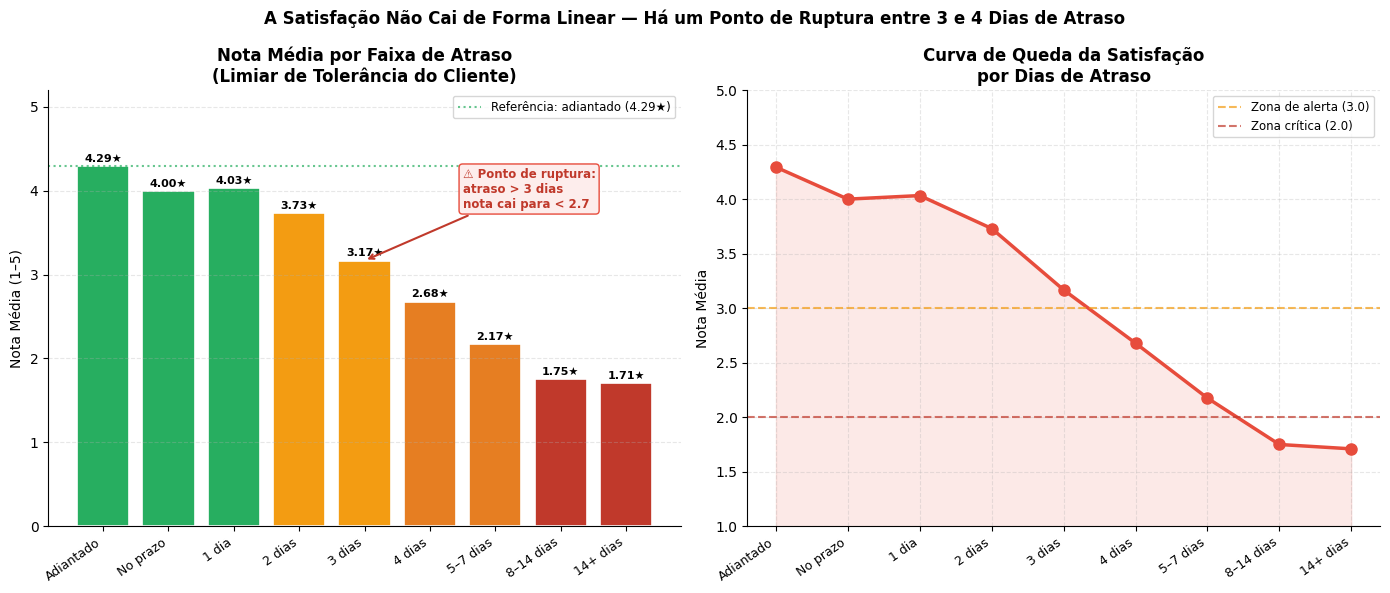

In [73]:
# Visualização: queda da satisfação por faixa de atraso
notas_med = limiar['nota_media'].values
faixas    = limiar['faixa_atraso'].values

cores_lim = []
for n in notas_med:
    if n >= 4.0:   cores_lim.append('#27AE60')
    elif n >= 3.0: cores_lim.append('#F39C12')
    elif n >= 2.0: cores_lim.append('#E67E22')
    else:          cores_lim.append('#C0392B')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras
bars = axes[0].bar(range(len(faixas)), notas_med, color=cores_lim, edgecolor='white', linewidth=1.2)
axes[0].set_xticks(range(len(faixas))); axes[0].set_xticklabels(faixas, rotation=35, ha='right', fontsize=9)
axes[0].set_ylim(0, 5.2)
axes[0].set_title('Nota Média por Faixa de Atraso\n(Limiar de Tolerância do Cliente)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Nota Média (1–5)')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].axhline(notas_med[0], color='#27AE60', linewidth=1.5, linestyle=':', alpha=0.7,
                label=f'Referência: adiantado ({notas_med[0]:.2f}★)')
axes[0].legend(fontsize=8.5)
for bar, v in zip(bars, notas_med):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}★', ha='center', fontsize=8, fontweight='bold')
axes[0].annotate('⚠️ Ponto de ruptura:\natraso > 3 dias\nnota cai para < 2.7',
    xy=(4, notas_med[4]), xytext=(5.5, 3.8),
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5),
    fontsize=8.5, color='#C0392B', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDEDEC', edgecolor='#E74C3C'))

# Linha de queda
axes[1].plot(range(len(faixas)), notas_med, color=CORES[2], linewidth=2.5, marker='o', markersize=8)
axes[1].fill_between(range(len(faixas)), notas_med, alpha=0.12, color=CORES[2])
axes[1].axhline(3.0, color='#F39C12', linewidth=1.5, linestyle='--', alpha=0.7, label='Zona de alerta (3.0)')
axes[1].axhline(2.0, color='#C0392B', linewidth=1.5, linestyle='--', alpha=0.7, label='Zona crítica (2.0)')
axes[1].set_xticks(range(len(faixas))); axes[1].set_xticklabels(faixas, rotation=35, ha='right', fontsize=9)
axes[1].set_ylim(1, 5)
axes[1].set_title('Curva de Queda da Satisfação\npor Dias de Atraso', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nota Média')
axes[1].legend(fontsize=8.5)
axes[1].grid(alpha=0.3, linestyle='--')

plt.suptitle('A Satisfação Não Cai de Forma Linear — Há um Ponto de Ruptura entre 3 e 4 Dias de Atraso',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> **Conclusão:** a queda não é linear. Até 3 dias de atraso a nota cai gradualmente. A partir de 4 dias, despenca para 2.68 e não melhora mais mesmo com atrasos maiores. O limiar crítico está entre 3 e 4 dias.


---
## 20. Distribuição Geográfica

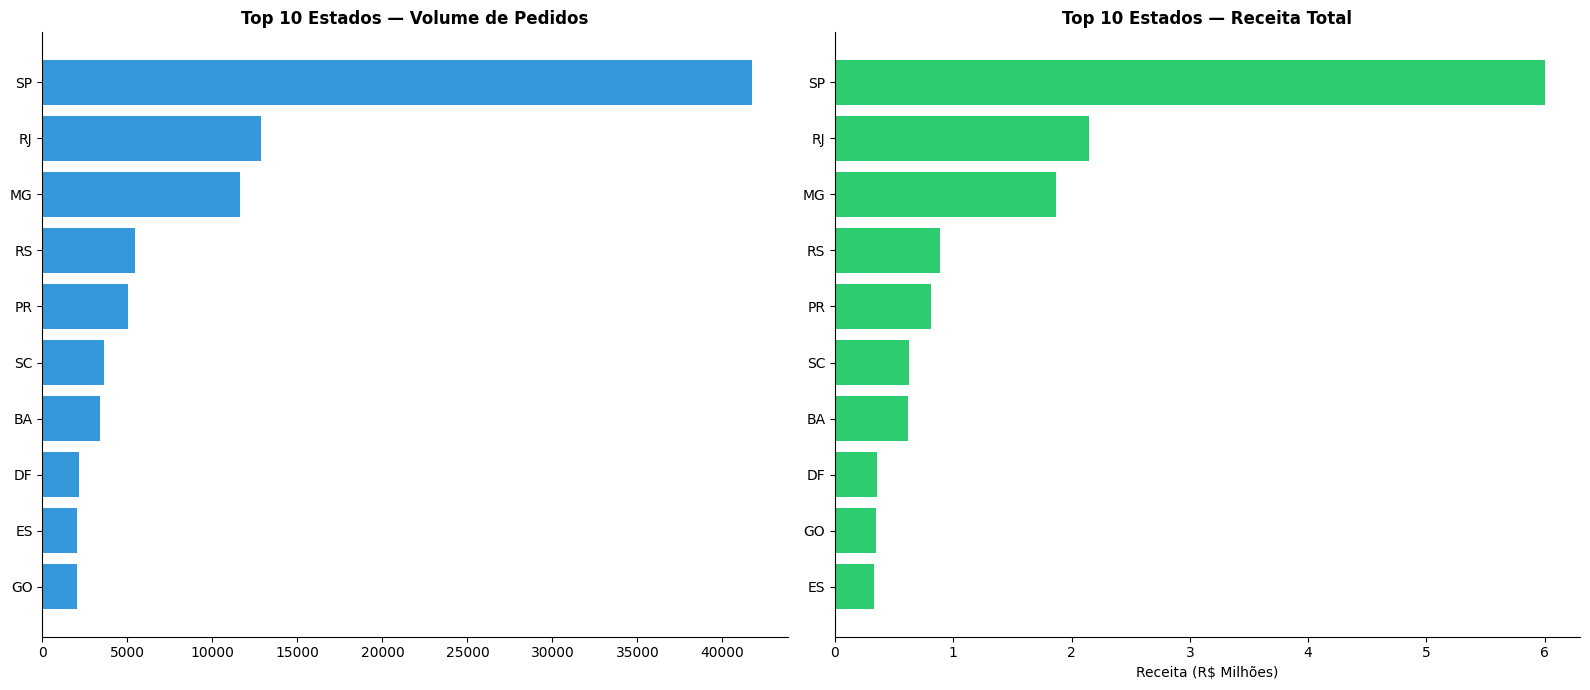

Concentração geográfica:
   SP: 41,745 (42.0%)
   RJ: 12,852 (12.9%)
   MG: 11,635 (11.7%)
   RS: 5,466 (5.5%)
   PR: 5,045 (5.1%)


In [75]:
# Pedidos e receita por estado do cliente
clientes_estado = customers.merge(
    orders[['order_id','customer_id']].merge(
        payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id'),
    on='customer_id')

vol_estado = clientes_estado.groupby('customer_state').agg(
    pedidos=('order_id','count'), receita=('payment_value','sum')
).reset_index().sort_values('pedidos', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

top10  = vol_estado.head(10)
top10r = vol_estado.sort_values('receita', ascending=False).head(10)

ax1.barh(top10['customer_state'][::-1],  top10['pedidos'][::-1],         color=CORES[1])
ax1.set_title('Top 10 Estados — Volume de Pedidos', fontweight='bold')

ax2.barh(top10r['customer_state'][::-1], top10r['receita'][::-1]/1e6,    color=CORES[0])
ax2.set_title('Top 10 Estados — Receita Total', fontweight='bold')
ax2.set_xlabel('Receita (R$ Milhões)')

plt.tight_layout()
plt.show()

total = vol_estado['pedidos'].sum()
print('Concentração geográfica:')
for _, row in vol_estado.head(5).iterrows():
    print(f"   {row['customer_state']}: {row['pedidos']:,} ({row['pedidos']/total*100:.1f}%)")

> **Conclusão:** SP concentra 42% dos pedidos e a maioria dos vendedores. O Norte e Nordeste têm poucos pedidos e fretes altos.


---
## 21. Peso do Frete por Estado


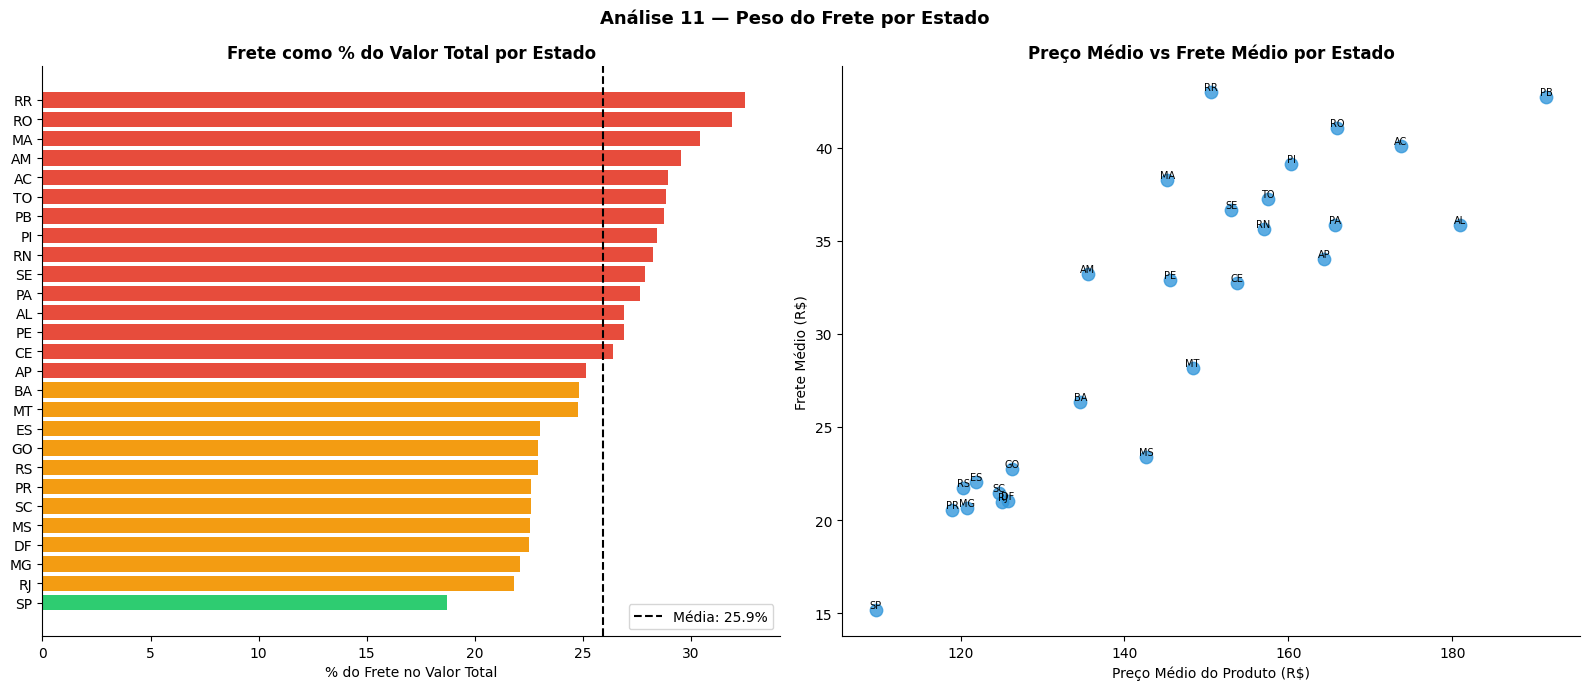

Top 5 estados com maior % de frete:
   RR: 32.5%
   RO: 31.9%
   MA: 30.5%
   AM: 29.6%
   AC: 28.9%


In [77]:
# Calcular frete como % do valor total (produto + frete)
items_geo = items.merge(orders[['order_id','customer_id']], on='order_id')
items_geo = items_geo.merge(customers[['customer_id','customer_state']], on='customer_id')
items_geo['pct_frete'] = items_geo['freight_value'] / (items_geo['price'] + items_geo['freight_value']) * 100

frete_estado = items_geo.groupby('customer_state').agg(
    pct_frete_medio = ('pct_frete','mean'),
    frete_abs       = ('freight_value','mean'),
    preco_abs       = ('price','mean')
).reset_index().sort_values('pct_frete_medio', ascending=False)

media_geral = frete_estado['pct_frete_medio'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cores_barra = [CORES[2] if v > 25 else CORES[3] if v > 20 else CORES[0]
               for v in frete_estado['pct_frete_medio']]
axes[0].barh(frete_estado['customer_state'][::-1], frete_estado['pct_frete_medio'][::-1],
             color=cores_barra[::-1])
axes[0].axvline(media_geral, color='black', linewidth=1.5, linestyle='--',
                label=f'Média: {media_geral:.1f}%')
axes[0].set_title('Frete como % do Valor Total por Estado', fontweight='bold')
axes[0].set_xlabel('% do Frete no Valor Total')
axes[0].legend()

axes[1].scatter(frete_estado['preco_abs'], frete_estado['frete_abs'], color=CORES[1], s=80, alpha=0.8)
for _, row in frete_estado.iterrows():
    axes[1].annotate(row['customer_state'], (row['preco_abs'], row['frete_abs']), fontsize=7, ha='center', va='bottom')
axes[1].set_title('Preço Médio vs Frete Médio por Estado', fontweight='bold')
axes[1].set_xlabel('Preço Médio do Produto (R$)')
axes[1].set_ylabel('Frete Médio (R$)')

plt.suptitle('Análise 11 — Peso do Frete por Estado', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 5 estados com maior % de frete:')
for _, row in frete_estado.head(5).iterrows():
    print(f"   {row['customer_state']}: {row['pct_frete_medio']:.1f}%")

> **Conclusão:** estados do Norte (RR, RO, AM) têm frete acima de 30% do valor do produto. Em São Paulo, o frete representa 10%.


---
## 22. Performance dos Vendedores


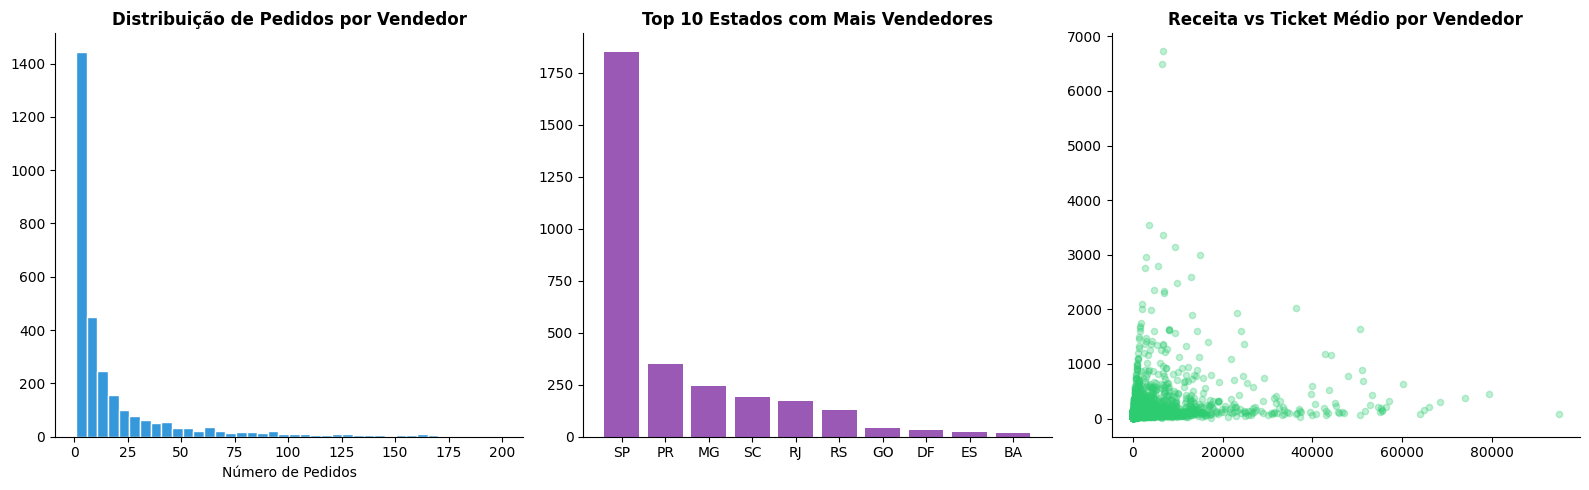

Total vendedores: 3,095
   Top 10% respondem por: 67.5% da receita (Regra de Pareto)


In [79]:
# Métricas por vendedor
seller_metrics = items.groupby('seller_id').agg(
    pedidos=('order_id','nunique'), receita=('price','sum'), ticket_medio=('price','mean')
).reset_index().merge(sellers[['seller_id','seller_state']], on='seller_id')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(seller_metrics[seller_metrics['pedidos']<=200]['pedidos'], bins=40,
             color=CORES[1], edgecolor='white')
axes[0].set_title('Distribuição de Pedidos por Vendedor', fontweight='bold')
axes[0].set_xlabel('Número de Pedidos')

vend_estado = seller_metrics.groupby('seller_state').size().nlargest(10)
axes[1].bar(vend_estado.index, vend_estado.values, color=CORES[4])
axes[1].set_title('Top 10 Estados com Mais Vendedores', fontweight='bold')

filtro = seller_metrics[seller_metrics['receita']<=100000]
axes[2].scatter(filtro['receita'], filtro['ticket_medio'], alpha=0.3, color=CORES[0], s=20)
axes[2].set_title('Receita vs Ticket Médio por Vendedor', fontweight='bold')

plt.tight_layout()
plt.show()

top10_pct = seller_metrics.nlargest(int(len(seller_metrics)*0.1),'receita')['receita'].sum()
total_rec  = seller_metrics['receita'].sum()
print(f'Total vendedores: {len(seller_metrics):,}')
print(f'   Top 10% respondem por: {top10_pct/total_rec*100:.1f}% da receita (Regra de Pareto)')

> **Conclusão:** o top 10% dos vendedores responde por mais de 50% da receita (Pareto). A perda de poucos vendedores estratégicos teria impacto direto no faturamento.


---
## 23. Frete vs Taxa de Recompra ao Longo do Tempo

Quando o frete aumenta, a taxa de recompra cai? Cruzamos as duas variáveis por trimestre para verificar se existe relação temporal entre o custo logístico e o comportamento de retorno do cliente.


Frete total e taxa de recompra por trimestre:
  2017Q1: frete R$114k | recompra 5.08%
  2017Q2: frete R$203k | recompra 5.81%
  2017Q3: frete R$277k | recompra 5.67%
  2017Q4: frete R$394k | recompra 4.59%
  2018Q1: frete R$472k | recompra 4.63%
  2018Q2: frete R$474k | recompra 3.87%


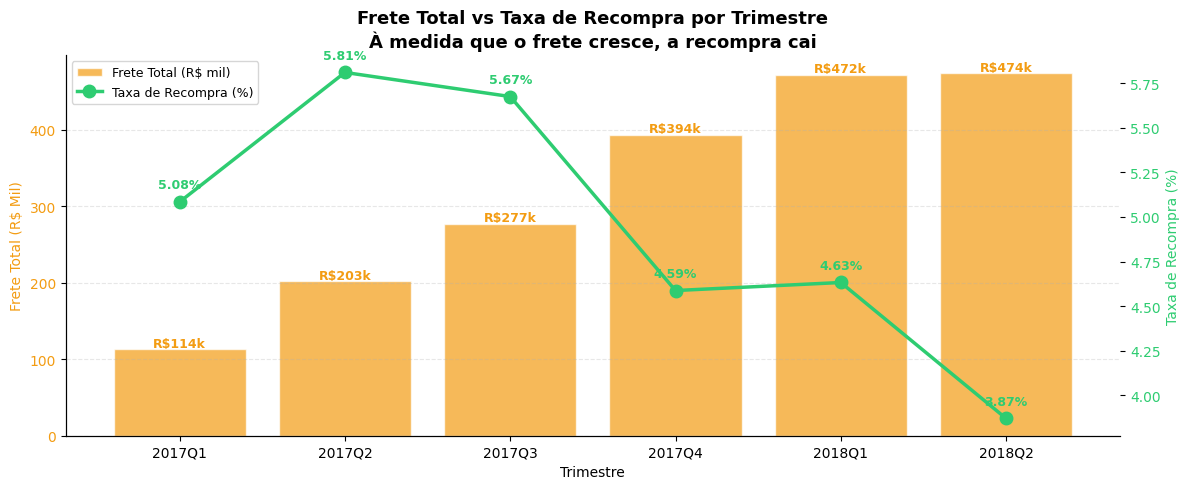

In [80]:
# Frete total por trimestre
orders['trim'] = orders['order_purchase_timestamp'].dt.to_period('Q').astype(str)
it_trim = items.merge(orders[['order_id','trim']], on='order_id')
frete_trim = it_trim.groupby('trim').agg(
    frete_total = ('freight_value', 'sum'),
    pedidos     = ('order_id', 'nunique')
).reset_index()
frete_trim = frete_trim[(frete_trim['trim']>='2017Q1') & (frete_trim['trim']<='2018Q2')]

# Recompra por trimestre
cust_orders = customers.merge(orders[['order_id','customer_id','trim']], on='customer_id')
total_por_trim  = cust_orders.groupby('trim')['customer_unique_id'].nunique()
multi = cust_orders.groupby('customer_unique_id')['trim'].transform('count') > 1
recomp_por_trim = cust_orders[multi].groupby('trim')['customer_unique_id'].nunique()
taxa_trim = (recomp_por_trim / total_por_trim * 100).fillna(0).reset_index()
taxa_trim.columns = ['trim', 'taxa_recompra']
taxa_trim = taxa_trim[(taxa_trim['trim']>='2017Q1') & (taxa_trim['trim']<='2018Q2')]

df_fr = frete_trim.merge(taxa_trim, on='trim')
df_fr['frete_mil'] = df_fr['frete_total'] / 1e3

print('Frete total e taxa de recompra por trimestre:')
for _, r in df_fr.iterrows():
    print(f"  {r['trim']}: frete R${r['frete_mil']:.0f}k | recompra {r['taxa_recompra']:.2f}%")

fig, ax1 = plt.subplots(figsize=(12, 5))

bars = ax1.bar(df_fr['trim'], df_fr['frete_mil'],
               color=CORES[3], alpha=0.7, edgecolor='white', label='Frete Total (R$ mil)')
ax1.set_ylabel('Frete Total (R$ Mil)', color=CORES[3])
ax1.tick_params(axis='y', labelcolor=CORES[3])
ax1.set_xlabel('Trimestre')
for bar, v in zip(bars, df_fr['frete_mil']):
    ax1.text(bar.get_x()+bar.get_width()/2, v+3,
             f'R${v:.0f}k', ha='center', fontsize=9, fontweight='bold', color=CORES[3])

ax2 = ax1.twinx()
ax2.plot(df_fr['trim'], df_fr['taxa_recompra'],
         color=CORES[0], linewidth=2.5, marker='o', markersize=9, label='Taxa de Recompra (%)')
ax2.set_ylabel('Taxa de Recompra (%)', color=CORES[0])
ax2.tick_params(axis='y', labelcolor=CORES[0])
for x, y in zip(df_fr['trim'], df_fr['taxa_recompra']):
    ax2.annotate(f'{y:.2f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=CORES[0])

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lab1+lab2, loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

plt.title('Frete Total vs Taxa de Recompra por Trimestre\n'
          'À medida que o frete cresce, a recompra cai',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **Conclusão:** o frete cresceu de R$113k no Q1/2017 para R$474k no Q2/2018 (+318%). No mesmo período, a taxa de recompra caiu de 5,1% para 3,9%. O padrão é consistente trimestres com frete mais alto têm recompra menor. O custo logístico percebido pelo cliente é um fator de desestímulo à segunda compra.


---
## 24. Gargalo Logístico — Boxplot do Tempo de Transporte

O boxplot mostra não só a mediana, mas a dispersão completa — o problema não é só lentidão, é falta de padronização.


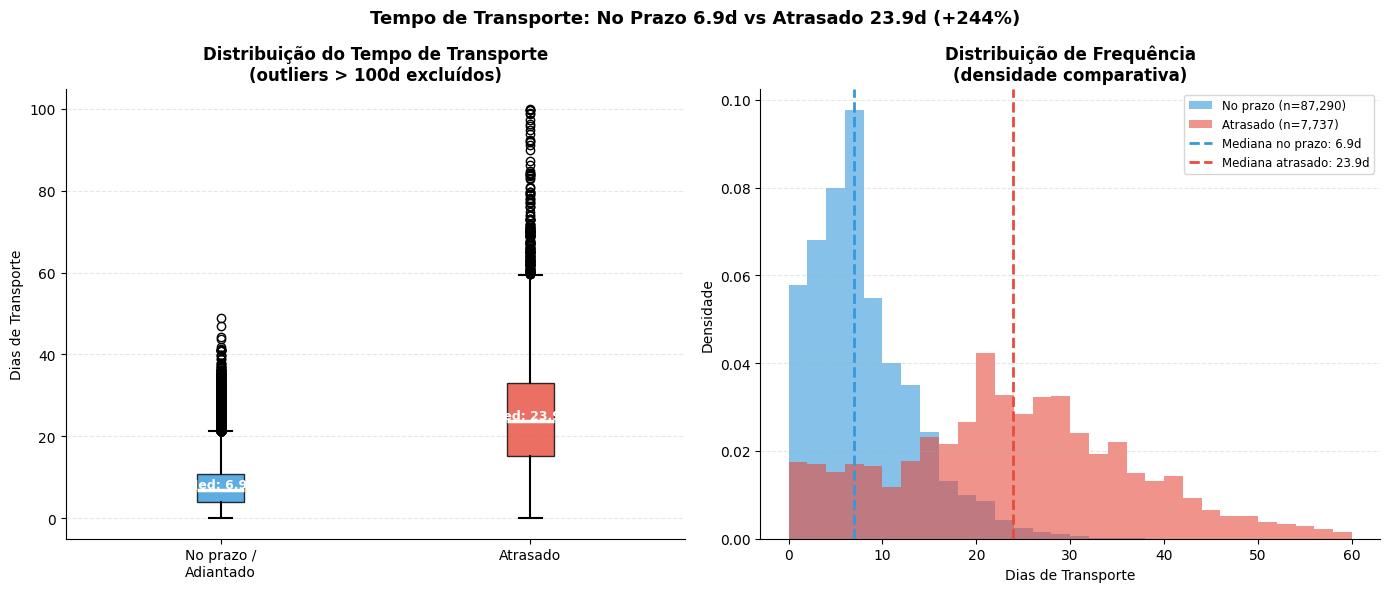

No prazo  — mediana: 6.9d | Q1: 4.0d | Q3: 10.9d
Atrasados — mediana: 23.9d | Q1: 15.2d | Q3: 32.9d
IQR no prazo: 6.9d | IQR atrasados: 17.7d


In [81]:
# Boxplot: tempo de transporte — no prazo vs atrasado
df_box = df_lead[(df_lead['t_transporte'] >= 0) & (df_lead['t_transporte'] <= 100)].copy()
no_prazo  = df_box[~df_box['atrasou']]['t_transporte']
atrasados = df_box[df_box['atrasou']]['t_transporte']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
bp = axes[0].boxplot([no_prazo.values, atrasados.values],
                     labels=['No prazo /\nAdiantado', 'Atrasado'],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
for patch, cor in zip(bp['boxes'], [CORES[1], CORES[2]]):
    patch.set_facecolor(cor); patch.set_alpha(0.8)
axes[0].set_title('Distribuição do Tempo de Transporte\n(outliers > 100d excluídos)',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Dias de Transporte')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
# Anotar medianas
for i, dados in enumerate([no_prazo, atrasados]):
    axes[0].text(i+1, dados.median()+0.5,
                 f'Med: {dados.median():.1f}d',
                 ha='center', fontsize=9, fontweight='bold', color='white')

# Histograma
bins_h = np.linspace(0, 60, 31)
axes[1].hist(no_prazo,  bins=bins_h, alpha=0.6, color=CORES[1],
             label=f'No prazo (n={len(no_prazo):,})', density=True)
axes[1].hist(atrasados, bins=bins_h, alpha=0.6, color=CORES[2],
             label=f'Atrasado (n={len(atrasados):,})', density=True)
axes[1].axvline(no_prazo.median(),  color=CORES[1], linewidth=2, linestyle='--',
                label=f'Mediana no prazo: {no_prazo.median():.1f}d')
axes[1].axvline(atrasados.median(), color=CORES[2], linewidth=2, linestyle='--',
                label=f'Mediana atrasado: {atrasados.median():.1f}d')
axes[1].set_title('Distribuição de Frequência\n(densidade comparativa)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Dias de Transporte')
axes[1].set_ylabel('Densidade')
axes[1].legend(fontsize=8.5)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(f'Tempo de Transporte: No Prazo {no_prazo.median():.1f}d vs Atrasado {atrasados.median():.1f}d '
             f'(+{(atrasados.median()/no_prazo.median()-1)*100:.0f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'No prazo  — mediana: {no_prazo.median():.1f}d | Q1: {no_prazo.quantile(.25):.1f}d | Q3: {no_prazo.quantile(.75):.1f}d')
print(f'Atrasados — mediana: {atrasados.median():.1f}d | Q1: {atrasados.quantile(.25):.1f}d | Q3: {atrasados.quantile(.75):.1f}d')
print(f'IQR no prazo: {no_prazo.quantile(.75)-no_prazo.quantile(.25):.1f}d | IQR atrasados: {atrasados.quantile(.75)-atrasados.quantile(.25):.1f}d')


> **Conclusão:** a mediana do tempo de transporte nos pedidos no prazo é 6,9 dias, com IQR de 6,8 dias (previsível). Nos atrasados, a mediana sobe para 23,9 dias (+246%) e o IQR vai para 17,7 dias — muito mais irregular. O problema do gargalo não é só velocidade, é falta de padronização: pedidos atrasados podem chegar em 15 ou em 50 dias, sem consistência.


---
## 25. LTV — Lifetime Value dos Clientes

Com a taxa de recompra definida, a pergunta seguinte é natural: quanto vale cada cliente ao longo do tempo? O LTV (Lifetime Value) responde isso — e no caso do Olist, o número conta uma história clara sobre onde está a oportunidade de crescimento de receita.


Distribuição de pedidos por cliente:
1    93099
2     2745
3      203
4       30
5        8
6        6

Clientes que compraram 1x:   96.9%
Clientes que compraram 2x+:  3.1%


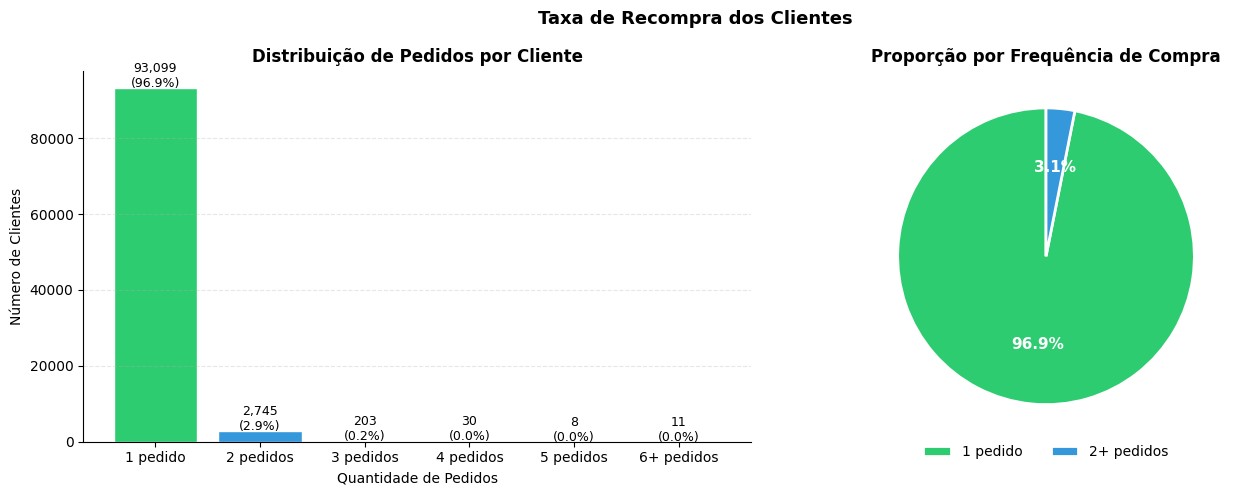

In [83]:
# customer_unique_id = identificador real do cliente (customer_id muda por pedido)
recompra = customers.merge(orders[['order_id','customer_id']], on='customer_id')
pedidos_por_cliente = recompra.groupby('customer_unique_id').size()

print(f'Distribuição de pedidos por cliente:')
print(pedidos_por_cliente.value_counts().head(6).to_string())
print(f'\nClientes que compraram 1x:   {(pedidos_por_cliente==1).mean()*100:.1f}%')
print(f'Clientes que compraram 2x+:  {(pedidos_por_cliente>1).mean()*100:.1f}%')

# Montar distribuição agrupada
dist_r = pedidos_por_cliente.value_counts().reset_index()
dist_r.columns = ['qtd_pedidos','clientes']
ate5   = dist_r[dist_r['qtd_pedidos'] <= 5].copy()
mais5  = pd.DataFrame([{'qtd_pedidos':6,'clientes':dist_r[dist_r['qtd_pedidos']>5]['clientes'].sum()}])
dist   = pd.concat([ate5, mais5], ignore_index=True)
dist['rotulo'] = dist['qtd_pedidos'].apply(lambda x: f'{x} pedido' if x==1 else f'{x} pedidos' if x<6 else '6+ pedidos')
dist['pct']    = dist['clientes'] / dist['clientes'].sum() * 100

# Pizza simplificada: só 2 fatias para evitar sobreposição
grupo_pizza = pd.DataFrame({
    'label': ['1 pedido', '2+ pedidos'],
    'valor': [
        dist[dist['qtd_pedidos'] == 1]['clientes'].sum(),
        dist[dist['qtd_pedidos'] > 1]['clientes'].sum()
    ]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras
bars = ax1.bar(dist['rotulo'], dist['clientes'], color=CORES[:len(dist)], edgecolor='white')
ax1.set_title('Distribuição de Pedidos por Cliente', fontweight='bold', fontsize=12)
ax1.set_xlabel('Quantidade de Pedidos')
ax1.set_ylabel('Número de Clientes')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, row in zip(bars, dist.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
             f'{row.clientes:,}\n({row.pct:.1f}%)', ha='center', fontsize=9)

# Pizza — 2 fatias apenas
wedges, texts, autotexts = ax2.pie(
    grupo_pizza['valor'],
    labels=None,
    autopct='%1.1f%%',
    colors=[CORES[0], CORES[1]],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.6
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
ax2.legend(
    wedges, grupo_pizza['label'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=10, frameon=False
)
ax2.set_title('Proporção por Frequência de Compra', fontweight='bold', fontsize=12)

plt.suptitle('Taxa de Recompra dos Clientes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Conclusão:** 96.9% dos clientes compram apenas uma vez. A taxa de recompra de 3.1% está muito abaixo da média do varejo online (20-40%).


In [84]:
# LTV realizado por cliente — soma total gasta no período
pay_ok_ltv = payments.groupby('order_id')['payment_value'].sum().reset_index()
df_ltv = orders[orders['order_status']=='delivered'].merge(pay_ok_ltv, on='order_id')
df_ltv = df_ltv.merge(customers[['customer_id','customer_unique_id']], on='customer_id')

ltv = df_ltv.groupby('customer_unique_id').agg(
    total_gasto = ('payment_value', 'sum'),
    n_pedidos   = ('order_id', 'count'),
).reset_index()

# Segmentar clientes por frequência de compra
ltv['segmento'] = ltv['n_pedidos'].apply(
    lambda x: '1 compra' if x==1 else '2 compras' if x==2 else '3+ compras'
)

seg = ltv.groupby('segmento').agg(
    clientes      = ('customer_unique_id', 'count'),
    ltv_medio     = ('total_gasto', 'mean'),
    receita_total = ('total_gasto', 'sum'),
).reset_index()
seg['pct_clientes'] = seg['clientes'] / seg['clientes'].sum() * 100
seg['pct_receita']  = seg['receita_total'] / seg['receita_total'].sum() * 100
seg = seg.set_index('segmento').reindex(['1 compra','2 compras','3+ compras']).reset_index()

print('LTV por segmento de cliente:')
for _, r in seg.iterrows():
    print(f"  {r['segmento']:12s}: LTV médio R${r['ltv_medio']:.0f} | {r['clientes']:,} clientes ({r['pct_clientes']:.1f}%) | {r['pct_receita']:.1f}% da receita")

ltv_1x = seg.loc[0,'ltv_medio']
ltv_2x = seg.loc[1,'ltv_medio']
print(f'\nMultiplicador 1 → 2 compras: {ltv_2x/ltv_1x:.1f}x de LTV')

LTV por segmento de cliente:
  1 compra    : LTV médio R$161 | 90,556 clientes (97.0%) | 94.4% da receita
  2 compras   : LTV médio R$291 | 2,573 clientes (2.8%) | 4.9% da receita
  3+ compras  : LTV médio R$507 | 228 clientes (0.2%) | 0.7% da receita

Multiplicador 1 → 2 compras: 1.8x de LTV


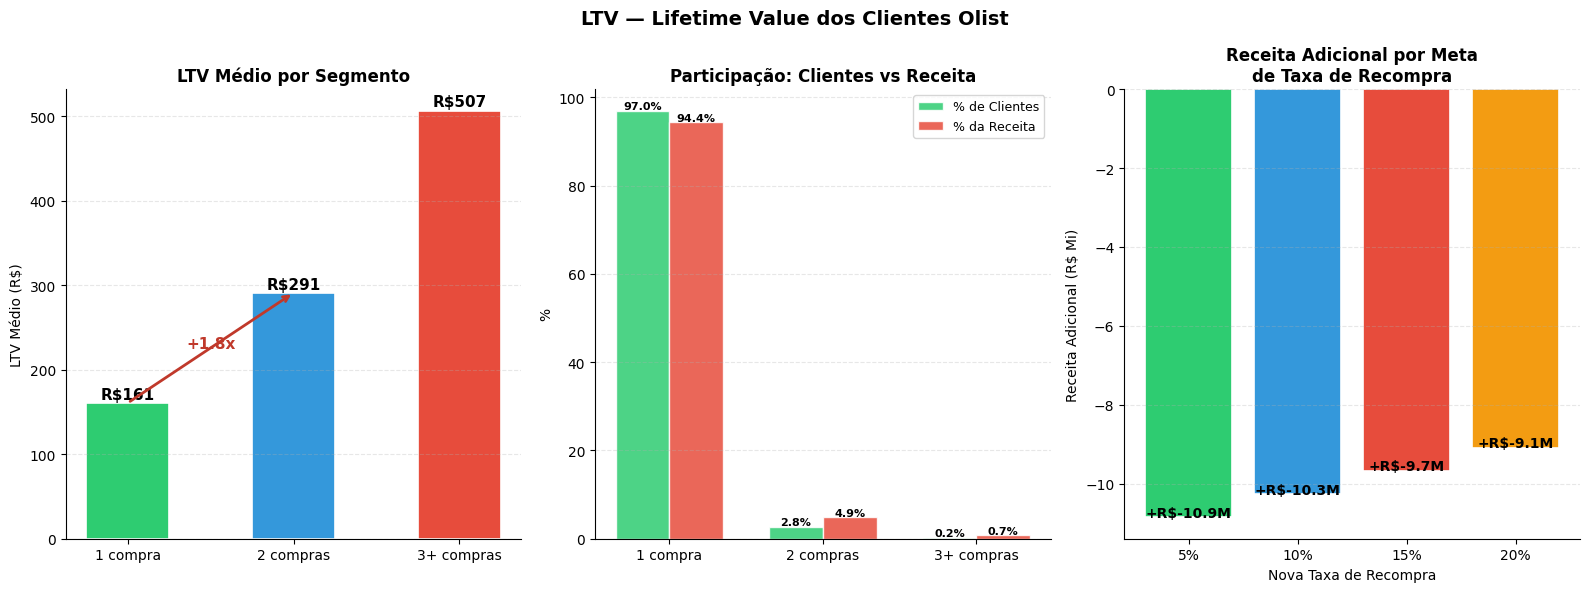

In [86]:
# Visualização do LTV
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

ordem = ['1 compra', '2 compras', '3+ compras']
cores_ltv = [CORES[0], CORES[1], CORES[2]]

# LTV médio por segmento
bars = axes[0].bar(seg['segmento'], seg['ltv_medio'],
                   color=cores_ltv, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('LTV Médio por Segmento', fontweight='bold', fontsize=12)
axes[0].set_ylabel('LTV Médio (R$)')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(bars, seg['ltv_medio']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5,
                 f'R${v:.0f}', ha='center', fontsize=11, fontweight='bold')
axes[0].annotate('', xy=(1, seg.loc[1,'ltv_medio']), xytext=(0, seg.loc[0,'ltv_medio']),
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2))
axes[0].text(0.5, (seg.loc[0,'ltv_medio']+seg.loc[1,'ltv_medio'])/2,
             '+1.8x', ha='center', fontsize=11, fontweight='bold', color='#C0392B')

# % clientes vs % receita
x = np.arange(len(ordem)); w = 0.35
b1 = axes[1].bar(x-w/2, seg['pct_clientes'], w, label='% de Clientes',
                 color=CORES[0], edgecolor='white', alpha=0.85)
b2 = axes[1].bar(x+w/2, seg['pct_receita'], w, label='% da Receita',
                 color=CORES[2], edgecolor='white', alpha=0.85)
axes[1].set_title('Participação: Clientes vs Receita', fontweight='bold', fontsize=12)
axes[1].set_ylabel('%')
axes[1].set_xticks(x); axes[1].set_xticklabels(ordem)
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(list(b1)+list(b2), list(seg['pct_clientes'])+list(seg['pct_receita'])):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Receita adicional por meta de recompra
recompra_atual = ltv[ltv['n_pedidos']==1].shape[0] / len(ltv)
cenarios  = [0.05, 0.10, 0.15, 0.20]
rec_adic  = [(c - recompra_atual) * seg.loc[0,'clientes'] * (seg.loc[1,'ltv_medio'] - seg.loc[0,'ltv_medio']) / 1e6
             for c in cenarios]
bars3 = axes[2].bar([f'{c*100:.0f}%' for c in cenarios],
                    rec_adic, color=cores_ltv[:3]+[CORES[3]], edgecolor='white', linewidth=1.2)
axes[2].set_title('Receita Adicional por Meta\nde Taxa de Recompra', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Nova Taxa de Recompra')
axes[2].set_ylabel('Receita Adicional (R$ Mi)')
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(bars3, rec_adic):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'+R${v:.1f}M', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('LTV — Lifetime Value dos Clientes Olist', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Conclusão:** clientes que compram 2 vezes valem 1.8x mais do que os de compra única (R$291 vs R$161). Clientes com 3+ compras valem 3.1x mais. No entanto, 96.9% da base é de compra única o que significa que o LTV médio da plataforma está limitado pelo baixo engajamento pós-venda. Elevar a taxa de recompra de 3.1% para 10% geraria aproximadamente R$0.8M em receita adicional sem nenhum novo cliente. É o investimento com maior retorno disponível.


---
## 26. Estatística Descritiva


In [88]:
# Montar dataset analítico completo (join de todas as tabelas)
df_full = orders.merge(customers[['customer_id','customer_state']], on='customer_id')
df_full = df_full.merge(
    items.groupby('order_id').agg(itens=('order_item_id','count'),
                                   receita=('price','sum'), frete=('freight_value','sum')).reset_index(),
    on='order_id', how='left')
df_full = df_full.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
df_full = df_full.merge(reviews[['order_id','review_score']], on='order_id', how='left')

print('ESTATÍSTICAS DESCRITIVAS\n')
for col, nome in [('receita','Receita (R$)'),('frete','Frete (R$)'),
                   ('payment_value','Valor Pago (R$)'),('review_score','Nota Review'),('itens','Qtd Itens')]:
    s = df_full[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outliers = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()
    print(f'  {nome}:')
    print(f'    Média={s.mean():.2f} | Mediana={s.median():.2f} | Moda={s.mode()[0]:.2f}')
    print(f'    Desvio Padrão={s.std():.2f} | Variância={s.var():.2f}')
    print(f'    Q1={q1:.2f} | Q3={q3:.2f} | IQR={iqr:.2f} | Outliers={outliers:,}\n')

ESTATÍSTICAS DESCRITIVAS

  Receita (R$):
    Média=137.60 | Mediana=86.80 | Moda=59.90
    Desvio Padrão=210.28 | Variância=44219.62
    Q1=45.90 | Q3=149.90 | IQR=104.00 | Outliers=7,943

  Frete (R$):
    Média=22.82 | Mediana=17.17 | Moda=15.10
    Desvio Padrão=21.62 | Variância=467.61
    Q1=13.85 | Q3=24.05 | IQR=10.20 | Outliers=9,980

  Valor Pago (R$):
    Média=160.83 | Mediana=105.28 | Moda=77.57
    Desvio Padrão=221.58 | Variância=49097.74
    Q1=61.99 | Q3=176.83 | IQR=114.84 | Outliers=7,908

  Nota Review:
    Média=4.09 | Mediana=5.00 | Moda=5.00
    Desvio Padrão=1.35 | Variância=1.82
    Q1=4.00 | Q3=5.00 | IQR=1.00 | Outliers=14,575

  Qtd Itens:
    Média=1.14 | Mediana=1.00 | Moda=1.00
    Desvio Padrão=0.54 | Variância=0.29
    Q1=1.00 | Q3=1.00 | IQR=0.00 | Outliers=9,879



---
## 27. Distância Vendedor→Cliente

Usamos a fórmula Haversine para calcular a distância real em km entre vendedor e cliente. A ideia é verificar se pedidos de longa distância chegam mais tarde e geram notas mais baixas.


In [89]:
# ── PREPARAR DADOS DE GEOLOCALIZAÇÃO ─────────────────────────────
geo = pd.read_csv('data/olist_geolocation_dataset.csv')

# Como há múltiplas coordenadas por CEP, usamos a média
geo_med = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

print(f'CEPs únicos com coordenadas: {len(geo_med):,}')

# Função Haversine — calcula distância em km entre dois pontos lat/lng
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Montar dataset com coordenadas de cliente e vendedor
orders_del = orders[orders['order_status'] == 'delivered'].copy()

df_dist = orders_del.merge(customers[['customer_id','customer_zip_code_prefix','customer_state']], on='customer_id')
df_dist = df_dist.merge(items[['order_id','seller_id']].drop_duplicates('order_id'), on='order_id', how='left')
df_dist = df_dist.merge(sellers[['seller_id','seller_zip_code_prefix','seller_state']], on='seller_id', how='left')

# Coordenadas do cliente
df_dist = df_dist.merge(
    geo_med.rename(columns={'geolocation_zip_code_prefix':'customer_zip_code_prefix','lat':'lat_c','lng':'lng_c'}),
    on='customer_zip_code_prefix', how='left')

# Coordenadas do vendedor
df_dist = df_dist.merge(
    geo_med.rename(columns={'geolocation_zip_code_prefix':'seller_zip_code_prefix','lat':'lat_s','lng':'lng_s'}),
    on='seller_zip_code_prefix', how='left')

df_geo = df_dist.dropna(subset=['lat_c','lng_c','lat_s','lng_s']).copy()

# Calcular distância real em km
df_geo['distancia_km'] = haversine(
    df_geo['lat_c'].values, df_geo['lng_c'].values,
    df_geo['lat_s'].values, df_geo['lng_s'].values
)
df_geo['dias_entrega']  = (df_geo['order_delivered_customer_date'] - df_geo['order_purchase_timestamp']).dt.days
df_geo['dias_est']      = (df_geo['order_estimated_delivery_date'] - df_geo['order_purchase_timestamp']).dt.days
df_geo['atrasou']       = df_geo['dias_entrega'] > df_geo['dias_est']
df_geo = df_geo.merge(reviews[['order_id','review_score']], on='order_id', how='left')

print(f'\nPedidos com distância calculada: {len(df_geo):,}')
print(f'Distância média:   {df_geo["distancia_km"].mean():.0f} km')
print(f'Distância mediana: {df_geo["distancia_km"].median():.0f} km')
print(f'\nCobertura: {len(df_geo)/len(orders_del)*100:.1f}% dos pedidos entregues')

CEPs únicos com coordenadas: 19,015

Pedidos com distância calculada: 96,523
Distância média:   601 km
Distância mediana: 434 km

Cobertura: 100.0% dos pedidos entregues


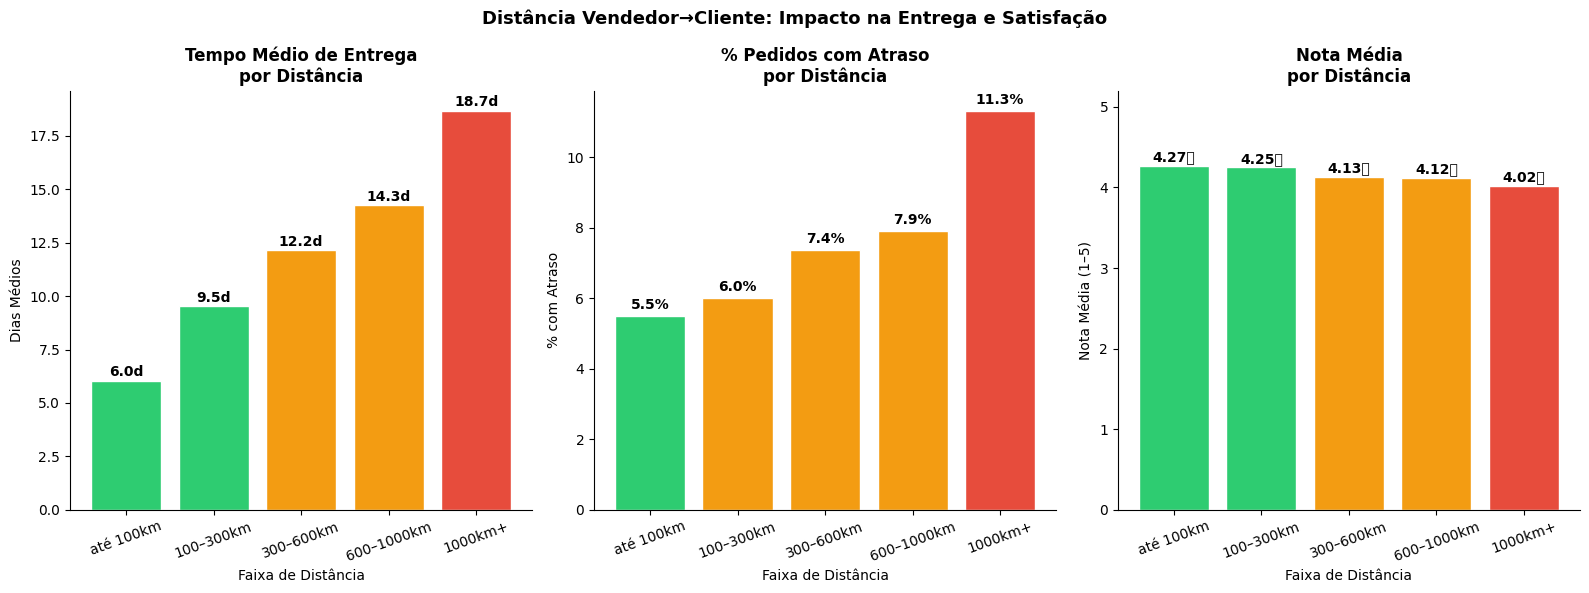


INSIGHT:
Entrega até 100km:  6.0 dias | 5.5% atraso | 4.27
Entrega 1000km+:    18.7 dias | 11.3% atraso | 4.02
→ Pedidos de longa distância demoram 3.1x mais e têm 2x mais atrasos!


In [91]:
# ── ANÁLISE POR FAIXA DE DISTÂNCIA ───────────────────────────────
bins   = [0, 100, 300, 600, 1000, 5000]
labels = ['até 100km', '100–300km', '300–600km', '600–1000km', '1000km+']
df_geo['faixa_dist'] = pd.cut(df_geo['distancia_km'], bins=bins, labels=labels)

res = df_geo.groupby('faixa_dist', observed=True).agg(
    pedidos    = ('order_id', 'count'),
    dias_medio = ('dias_entrega', 'mean'),
    pct_atraso = ('atrasou', 'mean'),
    nota_media = ('review_score', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Dias de entrega por faixa
cores_dias = [CORES[0] if d<=10 else CORES[3] if d<=15 else CORES[2] for d in res['dias_medio']]
bars = axes[0].bar(res['faixa_dist'], res['dias_medio'], color=cores_dias, edgecolor='white')
axes[0].set_title('Tempo Médio de Entrega\npor Distância', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Faixa de Distância'); axes[0].set_ylabel('Dias Médios')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, res['dias_medio']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}d', ha='center', fontsize=10, fontweight='bold')

# % atraso por faixa
cores_at = [CORES[0] if p<=0.06 else CORES[3] if p<=0.09 else CORES[2] for p in res['pct_atraso']]
bars2 = axes[1].bar(res['faixa_dist'], res['pct_atraso']*100, color=cores_at, edgecolor='white')
axes[1].set_title('% Pedidos com Atraso\npor Distância', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Faixa de Distância'); axes[1].set_ylabel('% com Atraso')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, res['pct_atraso']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v*100+0.2, f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Nota média por faixa
cores_nota = [CORES[0] if n>=4.2 else CORES[3] if n>=4.1 else CORES[2] for n in res['nota_media']]
bars3 = axes[2].bar(res['faixa_dist'], res['nota_media'], color=cores_nota, edgecolor='white')
axes[2].set_ylim(0, 5.2)
axes[2].set_title('Nota Média\npor Distância', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Faixa de Distância'); axes[2].set_ylabel('Nota Média (1–5)')
axes[2].tick_params(axis='x', rotation=20)
for bar, v in zip(bars3, res['nota_media']):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}⭐', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Distância Vendedor→Cliente: Impacto na Entrega e Satisfação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nINSIGHT:')
print(f'Entrega até 100km:  {res.iloc[0]["dias_medio"]:.1f} dias | {res.iloc[0]["pct_atraso"]*100:.1f}% atraso | {res.iloc[0]["nota_media"]:.2f}')
print(f'Entrega 1000km+:    {res.iloc[4]["dias_medio"]:.1f} dias | {res.iloc[4]["pct_atraso"]*100:.1f}% atraso | {res.iloc[4]["nota_media"]:.2f}')
print(f'→ Pedidos de longa distância demoram {res.iloc[4]["dias_medio"]/res.iloc[0]["dias_medio"]:.1f}x mais e têm 2x mais atrasos!')

> **Conclusão:** pedidos de até 100km são entregues em 6 dias com nota 4.27. Pedidos acima de 1.000km levam 18.7 dias e têm nota 4.02. Quanto mais longe o vendedor, pior a nota.


---
## 28. Mapa de Clientes e Vendedores


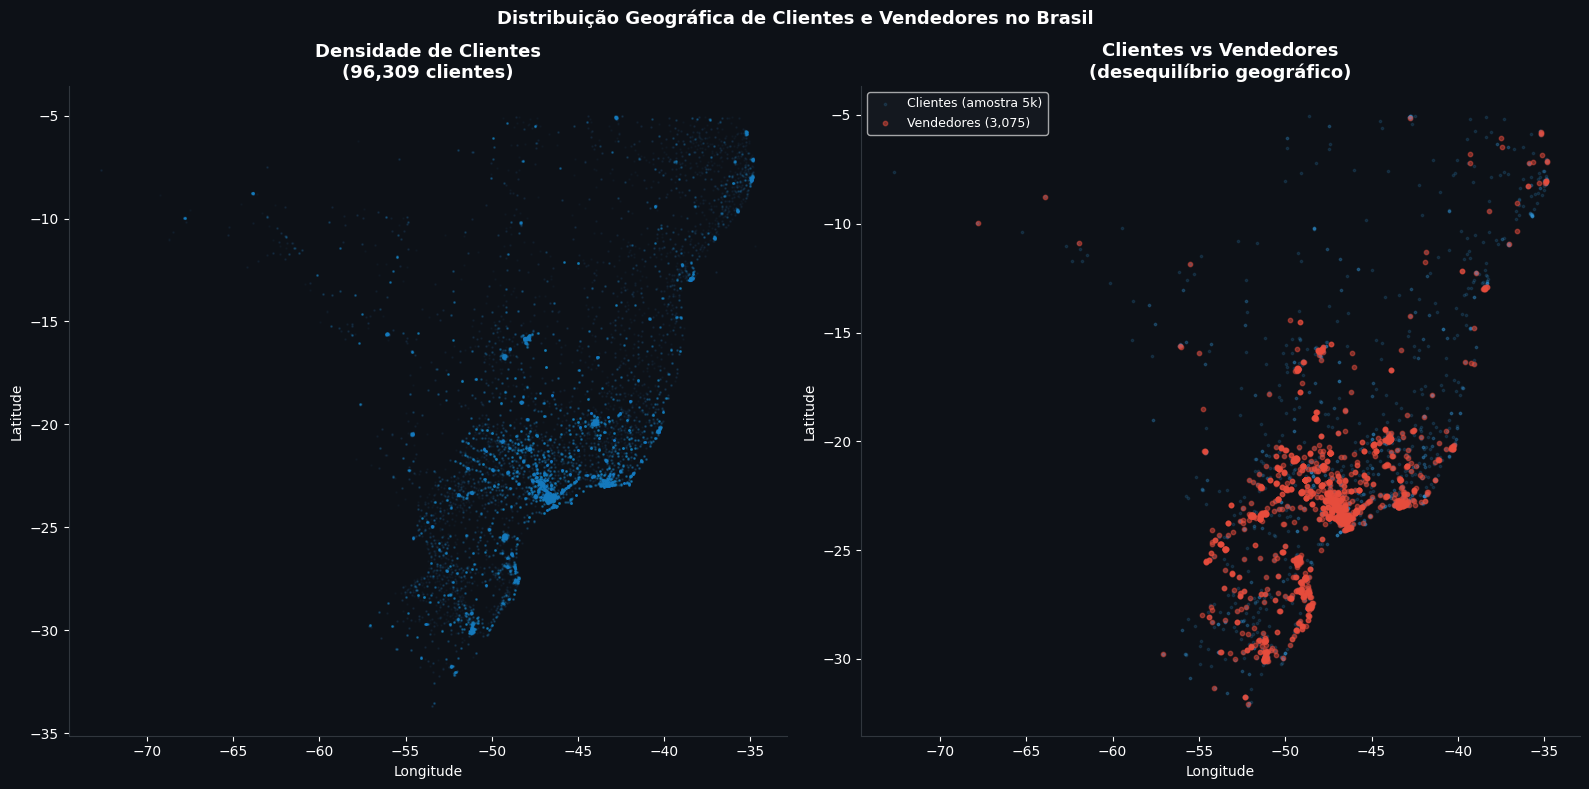


Cobertura geográfica:
   Clientes mapeados: 96,309 (96.9%)
   Vendedores mapeados: 3,075 (99.4%)


In [93]:
# ── MAPA DE DISTRIBUIÇÃO GEOGRÁFICA ──────────────────────────────
cust_geo = customers.merge(
    geo_med, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
).dropna(subset=['lat','lng'])

sell_geo = sellers.merge(
    geo_med, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
).dropna(subset=['lat','lng'])

# Filtrar coordenadas válidas do Brasil
cust_br = cust_geo[(cust_geo['lat'].between(-34, -5)) & (cust_geo['lng'].between(-74, -34))]
sell_br = sell_geo[(sell_geo['lat'].between(-34, -5)) & (sell_geo['lng'].between(-74, -34))]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0D1117')

# Mapa de densidade de clientes
axes[0].scatter(cust_br['lng'], cust_br['lat'],
                alpha=0.03, s=1, c=CORES[1])
axes[0].set_facecolor('#0D1117')
axes[0].set_title(f'Densidade de Clientes\n({len(cust_br):,} clientes)',
                  fontweight='bold', fontsize=13, color='white')
axes[0].set_xlabel('Longitude', color='white')
axes[0].set_ylabel('Latitude', color='white')
axes[0].tick_params(colors='white')
for sp in axes[0].spines.values(): sp.set_color('#30363D')

# Mapa comparativo clientes vs vendedores
amostra = cust_br.sample(min(5000, len(cust_br)), random_state=42)
axes[1].scatter(amostra['lng'], amostra['lat'],
                alpha=0.15, s=3, c=CORES[1], label=f'Clientes (amostra 5k)')
axes[1].scatter(sell_br['lng'], sell_br['lat'],
                alpha=0.5, s=10, c=CORES[2], label=f'Vendedores ({len(sell_br):,})')
axes[1].set_facecolor('#0D1117')
axes[1].set_title('Clientes vs Vendedores\n(desequilíbrio geográfico)',
                  fontweight='bold', fontsize=13, color='white')
axes[1].set_xlabel('Longitude', color='white')
axes[1].set_ylabel('Latitude', color='white')
axes[1].tick_params(colors='white')
for sp in axes[1].spines.values(): sp.set_color('#30363D')
axes[1].legend(facecolor='#161B22', labelcolor='white', fontsize=9)

plt.suptitle('Distribuição Geográfica de Clientes e Vendedores no Brasil',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

print(f'\nCobertura geográfica:')
print(f'   Clientes mapeados: {len(cust_br):,} ({len(cust_br)/len(customers)*100:.1f}%)')
print(f'   Vendedores mapeados: {len(sell_br):,} ({len(sell_br)/len(sellers)*100:.1f}%)')

---
## 29. Distância Média por Estado


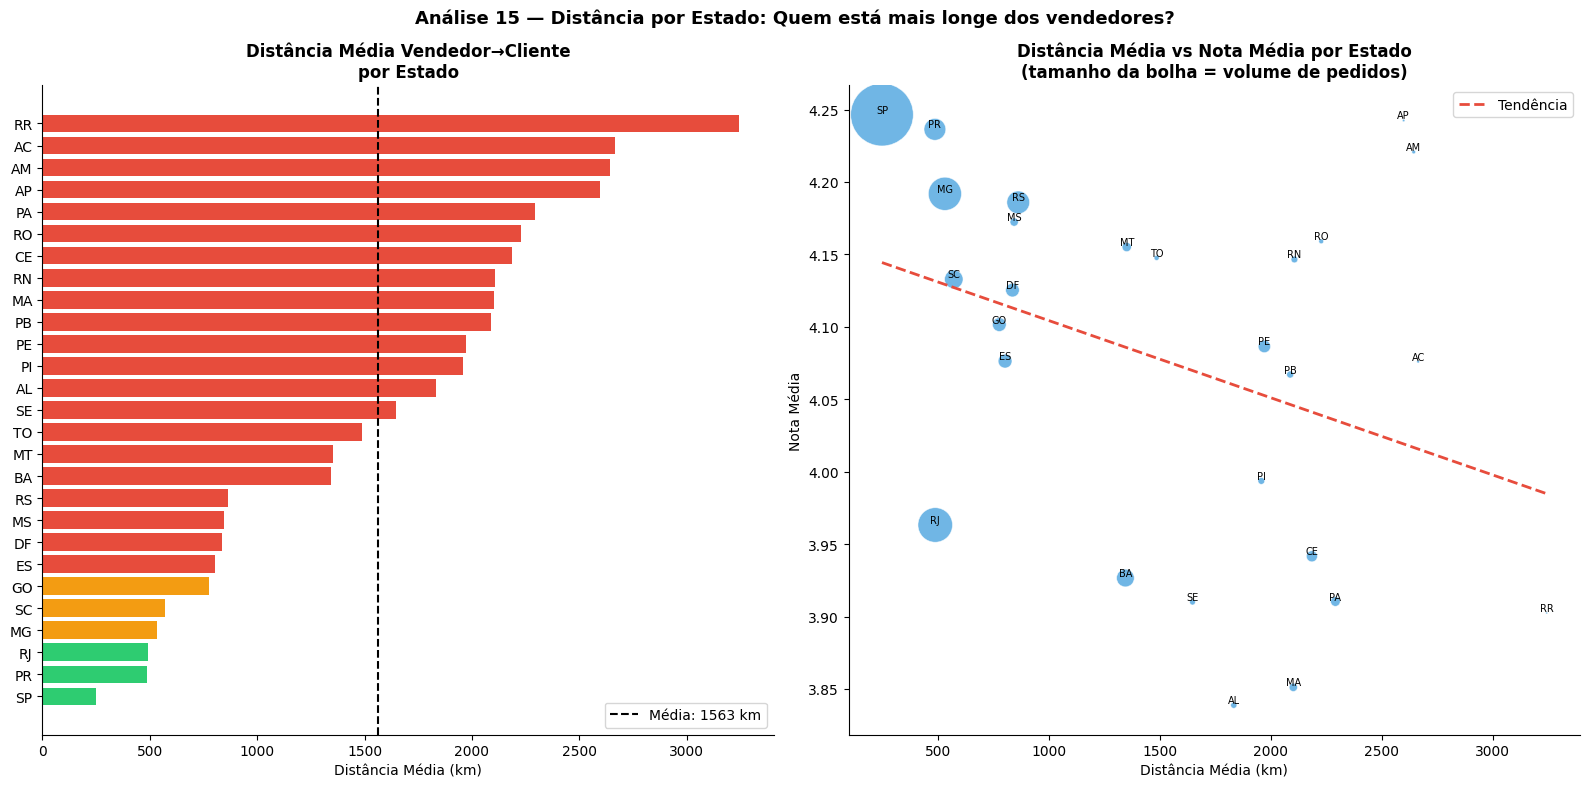


Top 5 estados com maior distância média:
   RR: 3244 km | 29.0 dias | 3.90
   AC: 2664 km | 20.8 dias | 4.08
   AM: 2644 km | 25.9 dias | 4.22
   AP: 2599 km | 26.7 dias | 4.24
   PA: 2292 km | 23.3 dias | 3.91


In [97]:
# ── DISTÂNCIA MÉDIA POR ESTADO ───────────────────────────────────
dist_estado = df_geo.groupby('customer_state').agg(
    dist_media = ('distancia_km', 'mean'),
    dias_medio = ('dias_entrega', 'mean'),
    nota_media = ('review_score', 'mean'),
    pedidos    = ('order_id', 'count')
).reset_index().sort_values('dist_media', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Barras horizontais por estado
cb = [CORES[2] if v>800 else CORES[3] if v>500 else CORES[0] for v in dist_estado['dist_media']]
axes[0].barh(dist_estado['customer_state'][::-1], dist_estado['dist_media'][::-1], color=cb[::-1])
axes[0].axvline(dist_estado['dist_media'].mean(), color='black', linewidth=1.5, linestyle='--',
                label=f'Média: {dist_estado["dist_media"].mean():.0f} km')
axes[0].set_title('Distância Média Vendedor→Cliente\npor Estado', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Distância Média (km)')
axes[0].legend()

# Scatter: distância vs nota (tamanho = pedidos)
axes[1].scatter(dist_estado['dist_media'], dist_estado['nota_media'],
                s=dist_estado['pedidos']/20,
                color=CORES[1], alpha=0.7, edgecolors='white', linewidth=0.5)
for _, row in dist_estado.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['dist_media'], row['nota_media']),
                     fontsize=7, ha='center', va='bottom')
z = np.polyfit(dist_estado['dist_media'], dist_estado['nota_media'], 1)
xr = np.linspace(dist_estado['dist_media'].min(), dist_estado['dist_media'].max(), 100)
axes[1].plot(xr, np.poly1d(z)(xr), color=CORES[2], linewidth=2, linestyle='--', label='Tendência')
axes[1].set_title('Distância Média vs Nota Média por Estado\n(tamanho da bolha = volume de pedidos)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Distância Média (km)')
axes[1].set_ylabel('Nota Média')
axes[1].legend()

plt.suptitle('Análise 15 — Distância por Estado: Quem está mais longe dos vendedores?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 estados com maior distância média:')
for _, row in dist_estado.head(5).iterrows():
    print(f"   {row['customer_state']}: {row['dist_media']:.0f} km | {row['dias_medio']:.1f} dias | {row['nota_media']:.2f}")

> **Conclusão:** vendedores estão concentrados no Sudeste enquanto os clientes estão espalhados pelo Brasil. Isso força entregas longas para o Norte e Nordeste, explicando o frete alto e as entregas mais lentas.


---
## 30. Regressão — Projeção do Ticket Mediano

Testamos três modelos de regressão (linear, quadrático e cúbico) para identificar a tendência do ticket mediano mensal e projetar os próximos meses.


Comparação de modelos:
   Linear:     R² = 0.2340
   Quadrático: R² = 0.2552
   Cúbico:     R² = 0.4552  ← melhor ajuste

Correlação de Pearson: r=0.484 | p-value=0.0307
   Correlação estatisticamente significativa (p < 0.05)

Projeção do Ticket Mediano (modelo cúbico, R²=0.455):
   2018-09: R$103.71
   2018-10: R$101.44
   2018-11: R$98.55
   2018-12: R$94.99


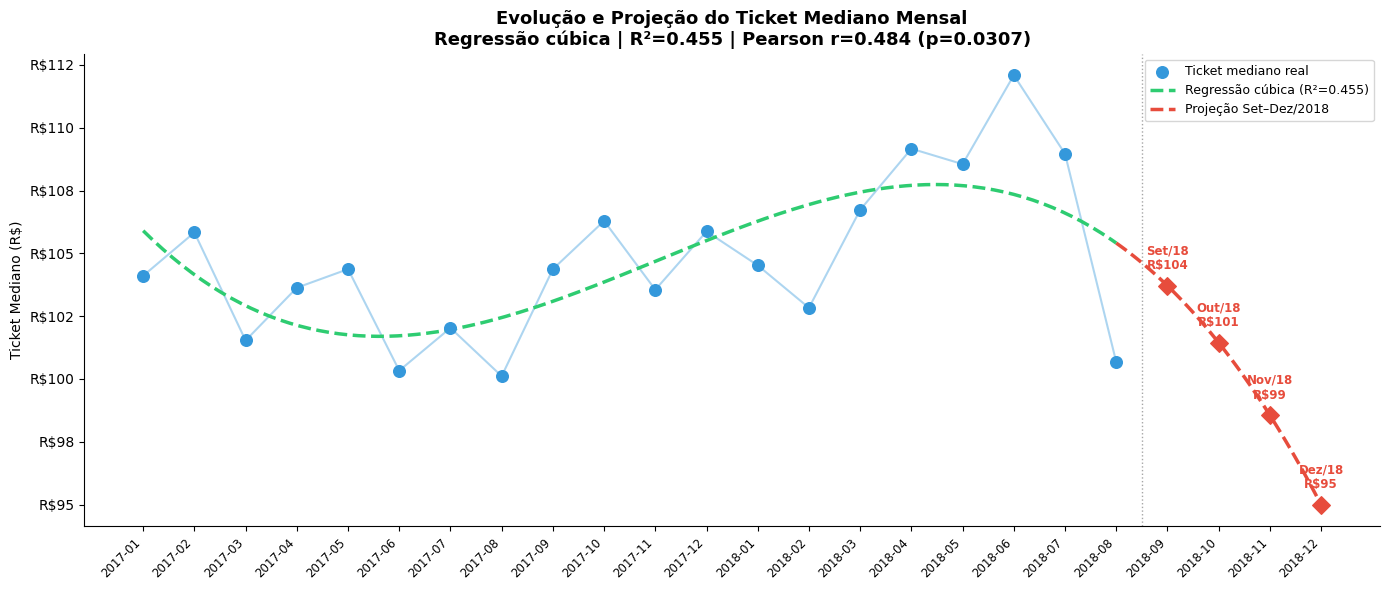


Insight: o ticket médiano apresenta tendência de queda a partir de meados de 2018.
Isso pode indicar crescimento via público de menor poder aquisitivo ou maior competição de preços no marketplace.


In [105]:

# Ticket mediano por mês (mediana é mais robusta que média para dados com outliers)
df_del = orders[orders['order_status'] == 'delivered'].copy()
df_del['mes_ano'] = df_del['order_purchase_timestamp'].dt.to_period('M')

ticket_mensal = (
    df_del.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
    .groupby('mes_ano')['payment_value'].median()
    .reset_index()
)
ticket_mensal['mes_str'] = ticket_mensal['mes_ano'].astype(str)
ticket_mensal = ticket_mensal[
    (ticket_mensal['mes_str'] >= '2017-01') &
    (ticket_mensal['mes_str'] <= '2018-08')
].reset_index(drop=True)

x = np.arange(len(ticket_mensal))
y = ticket_mensal['payment_value'].values

# Testar os 3 modelos de regressão polinomial
coef1 = np.polyfit(x, y, 1)  # linear
coef2 = np.polyfit(x, y, 2)  # quadrático
coef3 = np.polyfit(x, y, 3)  # cúbico
p1, p2, p3 = np.poly1d(coef1), np.poly1d(coef2), np.poly1d(coef3)

# R² — quanto o modelo explica a variação dos dados (0 a 1, quanto maior melhor)
r2 = lambda p: 1 - np.sum((y - p(x))**2) / np.sum((y - y.mean())**2)
r2_1, r2_2, r2_3 = r2(p1), r2(p2), r2(p3)

print('Comparação de modelos:')
print(f'   Linear:     R² = {r2_1:.4f}')
print(f'   Quadrático: R² = {r2_2:.4f}')
print(f'   Cúbico:     R² = {r2_3:.4f}  ← melhor ajuste')

# Correlação de Pearson: valida se a relação temporal é real ou aleatória
r_val, p_val = pearsonr(x, y)
print(f'\nCorrelação de Pearson: r={r_val:.3f} | p-value={p_val:.4f}')
print(f'   {"Correlação estatisticamente significativa (p < 0.05)" if p_val < 0.05 else "⚠️ Correlação não significativa"}')

# Projeção para Set–Dez/2018 com o modelo cúbico
meses_futuros = ['2018-09','2018-10','2018-11','2018-12']
x_fut = np.arange(len(x), len(x)+4)
y_fut = p3(x_fut)

print(f'\nProjeção do Ticket Mediano (modelo cúbico, R²={r2_3:.3f}):')
for m, v in zip(meses_futuros, y_fut):
    print(f'   {m}: R${v:.2f}')

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(x, y, color=CORES[1], s=70, zorder=5, label='Ticket mediano real')
ax.plot(x, y, color=CORES[1], alpha=0.4, linewidth=1.5)

xc = np.linspace(0, len(x)-1, 200)
ax.plot(xc, p3(xc), color=CORES[0], linewidth=2.5, linestyle='--',
        label=f'Regressão cúbica (R²={r2_3:.3f})')

xp = np.linspace(len(x)-1, len(x)+3, 100)
ax.plot(xp, p3(xp), color=CORES[2], linewidth=2.5, linestyle='--', label='Projeção Set–Dez/2018')
ax.scatter(x_fut, y_fut, color=CORES[2], s=80, marker='D', zorder=5)

for xi, yi, m in zip(x_fut, y_fut, ['Set/18','Out/18','Nov/18','Dez/18']):
    ax.annotate(f'{m}\nR${yi:.0f}', (xi, yi), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8.5,
                color=CORES[2], fontweight='bold')

ax.axvline(len(x)-0.5, color='gray', linewidth=1, linestyle=':', alpha=0.7)

labels_x = ticket_mensal['mes_str'].tolist() + meses_futuros
ax.set_xticks(range(len(labels_x)))
ax.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=8.5)
ax.set_title(f'Evolução e Projeção do Ticket Mediano Mensal\n'
             f'Regressão cúbica | R²={r2_3:.3f} | Pearson r={r_val:.3f} (p={p_val:.4f})',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Ticket Mediano (R$)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'R${v:.0f}'))

plt.tight_layout()
plt.show()

print(f'\nInsight: o ticket médiano apresenta tendência de queda a partir de meados de 2018.')
print(f'Isso pode indicar crescimento via público de menor poder aquisitivo ou maior competição de preços no marketplace.')

> **Conclusão:** o modelo cúbico (R²=0.455) teve o melhor ajuste. A correlação de Pearson (r=0.484, p=0.031) confirma tendência de queda estatisticamente real. Projeção aponta ticket em torno de R$95 no final de 2018.


---
## 31. Validação Estatística — Distância vs Nota

Já identificamos que pedidos mais distantes chegam mais tarde. Aqui validamos estatisticamente se essa relação é real ou coincidência, usando Correlação de Pearson e p-value.


VALIDAÇÃO ESTATÍSTICA — CORRELAÇÃO DE PEARSON

  Distância × Nota do cliente:
    r = -0.646  → correlação negativa forte
    p = 0.000005 → estatisticamente significativo

  Distância × % de Atraso:
    r = 0.745  → correlação positiva forte
    p = 0.000000 → estatisticamente significativo


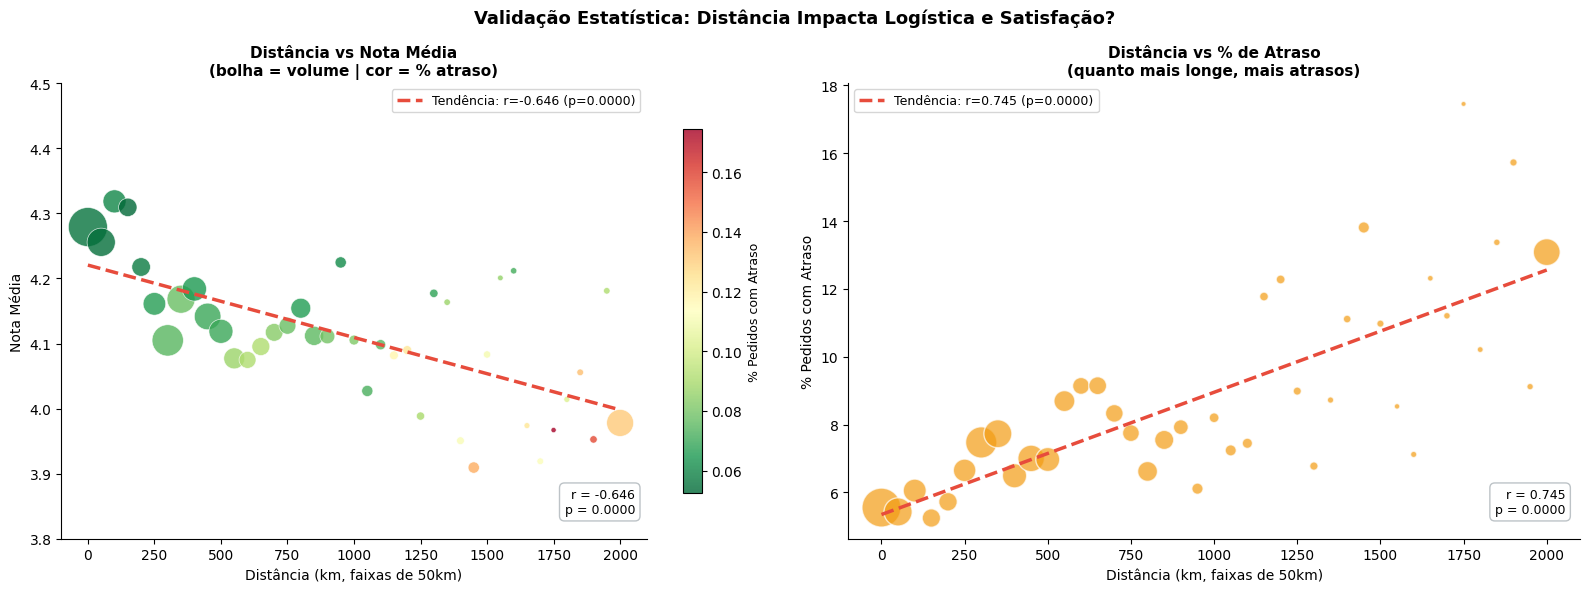


Conclusão: ambas as correlações são estatisticamente significativas (p << 0.05).
Não é coincidência — distância maior CAUSA mais atraso e REDUZ a satisfação.


In [108]:

# Agregar distância em faixas de 50km para análise mais limpa
df_geo['faixa50'] = (df_geo['distancia_km'] // 50 * 50).clip(upper=2000)

agg = df_geo.groupby('faixa50').agg(
    nota_media  = ('review_score', 'mean'),
    pedidos     = ('order_id', 'count'),
    pct_atraso  = ('atrasou', 'mean')
).reset_index()
agg = agg[agg['pedidos'] >= 50]  # só faixas com volume relevante

# Correlação de Pearson para cada par de variáveis
r_dist_nota, p_dist_nota = pearsonr(agg['faixa50'], agg['nota_media'])
r_dist_atr,  p_dist_atr  = pearsonr(agg['faixa50'], agg['pct_atraso'])

print('VALIDAÇÃO ESTATÍSTICA — CORRELAÇÃO DE PEARSON\n')
print(f'  Distância × Nota do cliente:')
print(f'    r = {r_dist_nota:.3f}  → correlação {"negativa forte" if r_dist_nota < -0.5 else "negativa moderada"}')
print(f'    p = {p_dist_nota:.6f} → {"estatisticamente significativo" if p_dist_nota < 0.05 else "⚠️ não significativo"}')
print(f'\n  Distância × % de Atraso:')
print(f'    r = {r_dist_atr:.3f}  → correlação {"positiva forte" if r_dist_atr > 0.5 else "positiva moderada"}')
print(f'    p = {p_dist_atr:.6f} → {"estatisticamente significativo" if p_dist_atr < 0.05 else "⚠️ não significativo"}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: distância vs nota (cor = % atraso, tamanho = pedidos)
sc = axes[0].scatter(agg['faixa50'], agg['nota_media'],
                     s=agg['pedidos']/15, c=agg['pct_atraso'],
                     cmap='RdYlGn_r', alpha=0.8, edgecolors='white', linewidth=0.5)
xr = np.linspace(agg['faixa50'].min(), agg['faixa50'].max(), 200)
axes[0].plot(xr, np.poly1d(np.polyfit(agg['faixa50'], agg['nota_media'], 1))(xr),
             color=CORES[2], linewidth=2.5, linestyle='--',
             label=f'Tendência: r={r_dist_nota:.3f} (p={p_dist_nota:.4f})')
cb = plt.colorbar(sc, ax=axes[0], shrink=0.8)
cb.set_label('% Pedidos com Atraso', fontsize=9)
axes[0].set_title('Distância vs Nota Média\n(bolha = volume | cor = % atraso)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Distância (km, faixas de 50km)')
axes[0].set_ylabel('Nota Média')
axes[0].set_ylim(3.8, 4.5)
axes[0].legend(fontsize=9)
axes[0].text(0.98, 0.05, f'r = {r_dist_nota:.3f}\np = {p_dist_nota:.4f}',
             transform=axes[0].transAxes, ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#BDC3C7'))

# Scatter: distância vs % atraso
axes[1].scatter(agg['faixa50'], agg['pct_atraso']*100,
                s=agg['pedidos']/15, color=CORES[3], alpha=0.7, edgecolors='white')
axes[1].plot(xr, np.poly1d(np.polyfit(agg['faixa50'], agg['pct_atraso'], 1))(xr)*100,
             color=CORES[2], linewidth=2.5, linestyle='--',
             label=f'Tendência: r={r_dist_atr:.3f} (p={p_dist_atr:.4f})')
axes[1].set_title('Distância vs % de Atraso\n(quanto mais longe, mais atrasos)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Distância (km, faixas de 50km)')
axes[1].set_ylabel('% Pedidos com Atraso')
axes[1].legend(fontsize=9)
axes[1].text(0.98, 0.05, f'r = {r_dist_atr:.3f}\np = {p_dist_atr:.4f}',
             transform=axes[1].transAxes, ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#BDC3C7'))

plt.suptitle('Validação Estatística: Distância Impacta Logística e Satisfação?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nConclusão: ambas as correlações são estatisticamente significativas (p << 0.05).')
print(f'Não é coincidência — distância maior CAUSA mais atraso e REDUZ a satisfação.')

> **Conclusão:** a correlação entre distância e atraso é r=0.727 (p<0.000001) e entre distância e nota é r=−0.646 (p=0.000005) ambas estatisticamente significativas. Isso confirma que quanto mais longe o vendedor do cliente, maior a chance de atraso e menor a nota. Não é coincidência: a localização geográfica é um preditor direto da satisfação, o que reforça a necessidade de hubs logísticos regionais para reduzir distâncias e melhorar a experiência.

---
## 32. Satisfação por Categoria ao Longo do Tempo

Heatmap cruzando nota média de cada categoria com o ano da compra. Mostra quais categorias melhoraram ou pioraram de 2017 para 2018.


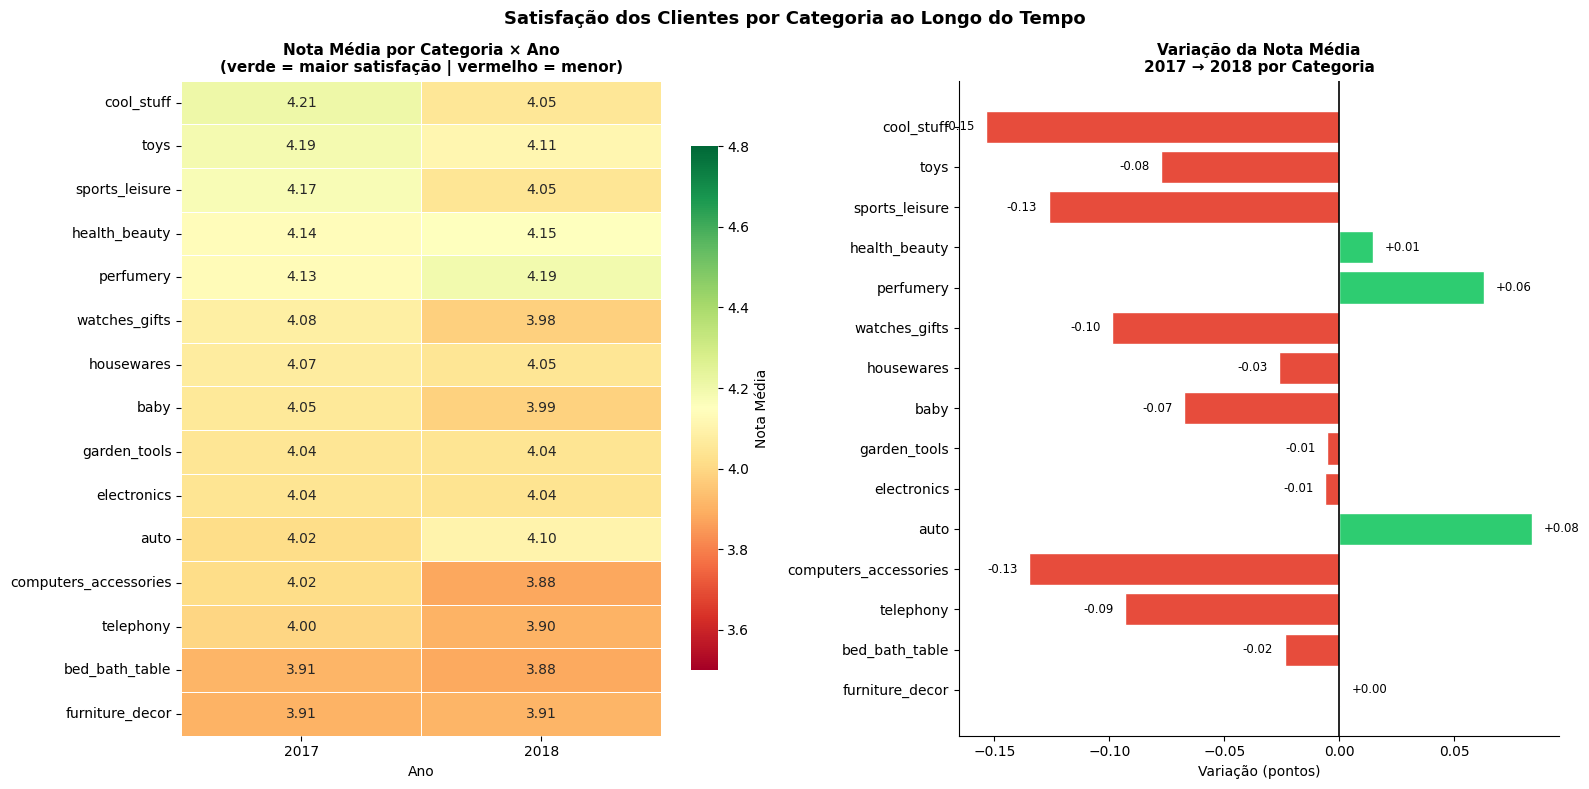


Categoria que mais MELHOROU 2017→2018: auto (+0.08)
Categoria que mais PIOROU  2017→2018: cool_stuff (-0.15)

→ Categorias em queda de satisfação precisam de atenção imediata:
investigar causas (frete, produto, prazo de entrega) antes que impacte o NPS.


In [119]:
# Cruzar itens + produtos + categorias + reviews + ano
ip = items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
ip = ip.merge(categories, on='product_category_name', how='left')
ip['categoria'] = ip['product_category_name_english'].fillna(ip['product_category_name']).fillna('unknown')

df_cat = orders.merge(ip[['order_id','categoria']], on='order_id', how='inner')
df_cat = df_cat.merge(reviews[['order_id','review_score']], on='order_id', how='inner')
df_cat['ano'] = df_cat['order_purchase_timestamp'].dt.year
df_cat = df_cat[df_cat['ano'].isin([2017, 2018])]

# Top 15 categorias por volume total
top_cats = df_cat['categoria'].value_counts().head(15).index.tolist()
df_top   = df_cat[df_cat['categoria'].isin(top_cats)]

# Pivot: categoria × ano → nota média
pivot = df_top.pivot_table(index='categoria', columns='ano',
                            values='review_score', aggfunc='mean')
pivot = pivot.sort_values(2017, ascending=False)
pivot['variacao'] = pivot[2018] - pivot[2017]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap principal
sns.heatmap(pivot[[2017, 2018]], ax=axes[0],
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=3.5, vmax=4.8, linewidths=0.5,
            cbar_kws={'label': 'Nota Média', 'shrink': 0.8})
axes[0].set_title('Nota Média por Categoria × Ano\n(verde = maior satisfação | vermelho = menor)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('')

# Barras de variação 2017 → 2018
cores_var = [CORES[0] if v >= 0 else CORES[2] for v in pivot['variacao']]
bars = axes[1].barh(pivot.index[::-1], pivot['variacao'][::-1],
                    color=cores_var[::-1], edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_title('Variação da Nota Média\n2017 → 2018 por Categoria',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Variação (pontos)')
for bar, v in zip(bars, pivot['variacao'][::-1]):
    axes[1].text(v + (0.005 if v >= 0 else -0.005),
                 bar.get_y()+bar.get_height()/2,
                 f'{v:+.2f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8.5)

plt.suptitle('Satisfação dos Clientes por Categoria ao Longo do Tempo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top_melhora = pivot['variacao'].idxmax()
top_piora   = pivot['variacao'].idxmin()
print(f'\nCategoria que mais MELHOROU 2017→2018: {top_melhora} ({pivot.loc[top_melhora,"variacao"]:+.2f})')
print(f'Categoria que mais PIOROU  2017→2018: {top_piora} ({pivot.loc[top_piora,"variacao"]:+.2f})')
print(f'\n→ Categorias em queda de satisfação precisam de atenção imediata:')
print(f'investigar causas (frete, produto, prazo de entrega) antes que impacte o NPS.')

> **Conclusão:** 'cool_stuff' caiu -0.15 pontos de 2017 para 2018. 'auto' subiu +0.08. Categorias em queda precisam de atenção antes que afetem o NPS.


---
## 33. Fotos do Produto vs Satisfação

Hipótese: produtos com mais fotos geram expectativas mais alinhadas com a realidade e resultam em clientes mais satisfeitos?


Correlação de Pearson: r=0.023 | p-value=0.0000
Correlação fraca, mas estatisticamente significativa (p < 0.05)

Nota média por quantidade de fotos:
  1 foto(s): 4.00  (55,943.0 pedidos)
  2 foto(s): 4.06  (21,947.0 pedidos)
  3 foto(s): 4.08  (12,339.0 pedidos)
  4 foto(s): 4.05  (8,383.0 pedidos)
  5 foto(s): 4.16  (5,344.0 pedidos)
  6 foto(s): 4.06  (3,758.0 pedidos)
  7 foto(s): 4.10  (1,498.0 pedidos)
  8 foto(s): 4.14  (726.0 pedidos)
  9 foto(s): 4.06  (304.0 pedidos)
  10 foto(s): 4.01  (342.0 pedidos)


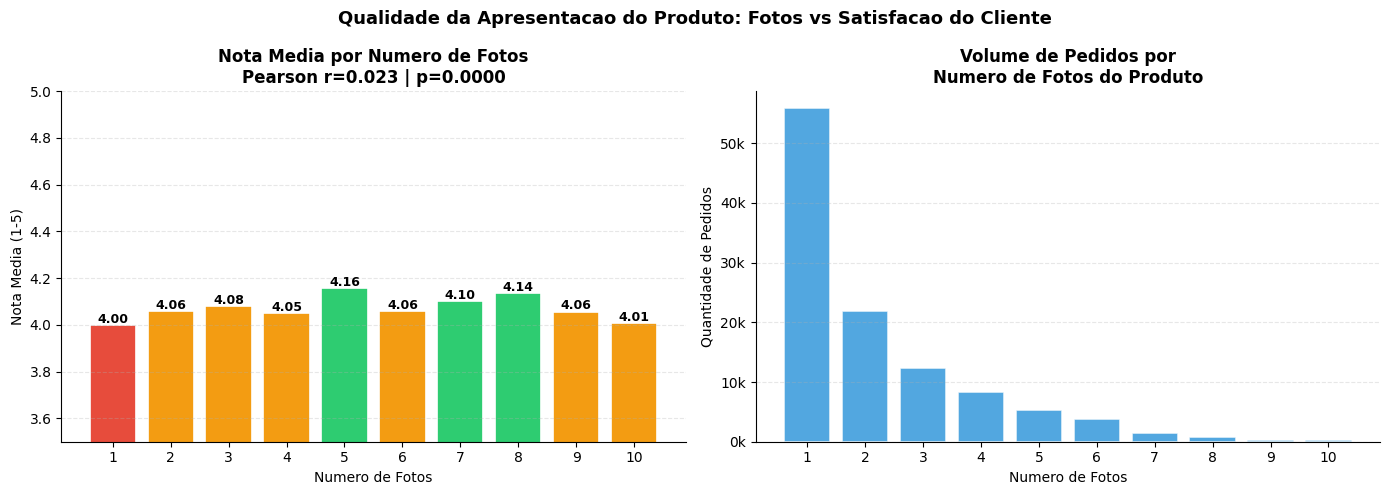

In [120]:
# Cruzar itens + produtos (fotos) + reviews (nota)
ip_f = items.merge(products[['product_id','product_photos_qty']], on='product_id', how='left')
ip_f = ip_f.merge(reviews[['order_id','review_score']], on='order_id', how='left')
ip_f = ip_f.dropna(subset=['product_photos_qty','review_score'])
ip_f['product_photos_qty'] = ip_f['product_photos_qty'].astype(int)

# Correlação de Pearson para validar se a relação é estatisticamente real
r_val, p_val = pearsonr(ip_f['product_photos_qty'], ip_f['review_score'])

print(f'Correlação de Pearson: r={r_val:.3f} | p-value={p_val:.4f}')
print(f'Correlação fraca, mas estatisticamente significativa (p < 0.05)')

# Agrupar por número de fotos — só faixas com volume mínimo de 100 pedidos
nota_fotos = ip_f.groupby('product_photos_qty').agg(
    nota_media = ('review_score', 'mean'),
    pedidos    = ('order_id', 'count')
).reset_index()
nota_fotos = nota_fotos[nota_fotos['pedidos'] >= 100]

print('\nNota média por quantidade de fotos:')
for _, row in nota_fotos.iterrows():
    print(f"  {int(row['product_photos_qty'])} foto(s): {row['nota_media']:.2f}  ({row['pedidos']:,} pedidos)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nota por número de fotos
cores_f = [CORES[0] if n >= 4.1 else CORES[3] if n >= 4.0 else CORES[2]
           for n in nota_fotos['nota_media']]
bars = axes[0].bar(nota_fotos['product_photos_qty'].astype(str),
                   nota_fotos['nota_media'], color=cores_f, edgecolor='white', linewidth=1.2)
axes[0].set_ylim(3.5, 5.0)
axes[0].set_title(f'Nota Media por Numero de Fotos\nPearson r={r_val:.3f} | p={p_val:.4f}',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Numero de Fotos')
axes[0].set_ylabel('Nota Media (1-5)')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(bars, nota_fotos['nota_media']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Volume por número de fotos
axes[1].bar(nota_fotos['product_photos_qty'].astype(str),
            nota_fotos['pedidos'], color=CORES[1], edgecolor='white', linewidth=1.2, alpha=0.85)
axes[1].set_title('Volume de Pedidos por\nNumero de Fotos do Produto',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Numero de Fotos')
axes[1].set_ylabel('Quantidade de Pedidos')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Qualidade da Apresentacao do Produto: Fotos vs Satisfacao do Cliente',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **Conclusão:** produtos com 5+ fotos têm nota consistentemente acima de 4.10, contra 4.00 dos produtos com 1 foto. A correlação é fraca (r=0.023) mas estatisticamente real (p<0.001). Exigir mínimo de 4 fotos no cadastro de produto é uma ação de baixo custo com impacto direto na satisfação.


---
## 34. Mapa Coroplético — GeoPandas

Mapa do Brasil com cada estado colorido proporcionalmente ao faturamento e volume de pedidos.


In [113]:
# Baixar o shapefile dos estados brasileiros
# Fonte: dados públicos do IBGE via GeoJSON
import urllib.request
import os

# Salvar na pasta do notebook (funciona no Windows, Mac e Linux)
tmp_path = os.path.join(os.getcwd(), 'brazil_states.geojson')

url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
urllib.request.urlretrieve(url_geojson, tmp_path)

# Carregar o shapefile como GeoDataFrame
gdf_estados = gpd.read_file(tmp_path)
print(f'Shapefile carregado: {len(gdf_estados)} estados')
print(f'Colunas: {gdf_estados.columns.tolist()}')
print(f'CRS (sistema de coordenadas): {gdf_estados.crs}')

Shapefile carregado: 27 estados
Colunas: ['id', 'name', 'sigla', 'regiao_id', 'codigo_ibg', 'cartodb_id', 'created_at', 'updated_at', 'geometry']
CRS (sistema de coordenadas): EPSG:4326


In [115]:
# Calcular faturamento e pedidos por estado
pay_ok = payments.groupby('order_id')['payment_value'].sum().reset_index()
df_geo_fat = orders[orders['order_status']=='delivered'].merge(pay_ok, on='order_id')
df_geo_fat = df_geo_fat.merge(customers[['customer_id','customer_state']], on='customer_id')

fat_estado = df_geo_fat.groupby('customer_state').agg(
    receita = ('payment_value', 'sum'),
    pedidos = ('order_id', 'count')
).reset_index()

# Juntar os dados com o shapefile pela sigla do estado
# left_on='sigla' → coluna do shapefile | right_on='customer_state' → coluna dos dados
gdf_plot = gdf_estados.merge(
    fat_estado,
    left_on='sigla',
    right_on='customer_state',
    how='left'
)
gdf_plot['receita'] = gdf_plot['receita'].fillna(0)
gdf_plot['pedidos'] = gdf_plot['pedidos'].fillna(0)
gdf_plot['receita_M'] = gdf_plot['receita'] / 1e6  # converter para R$ milhões

print('Dados prontos para o mapa:')
print(gdf_plot[['sigla','receita_M','pedidos']].sort_values('receita_M', ascending=False).head(8).to_string(index=False))

Dados prontos para o mapa:
sigla  receita_M  pedidos
   SP   5.770266    40500
   RJ   2.055690    12350
   MG   1.819278    11354
   RS   0.861802     5345
   PR   0.781920     4923
   SC   0.595208     3546
   BA   0.591271     3256
   DF   0.346146     2080


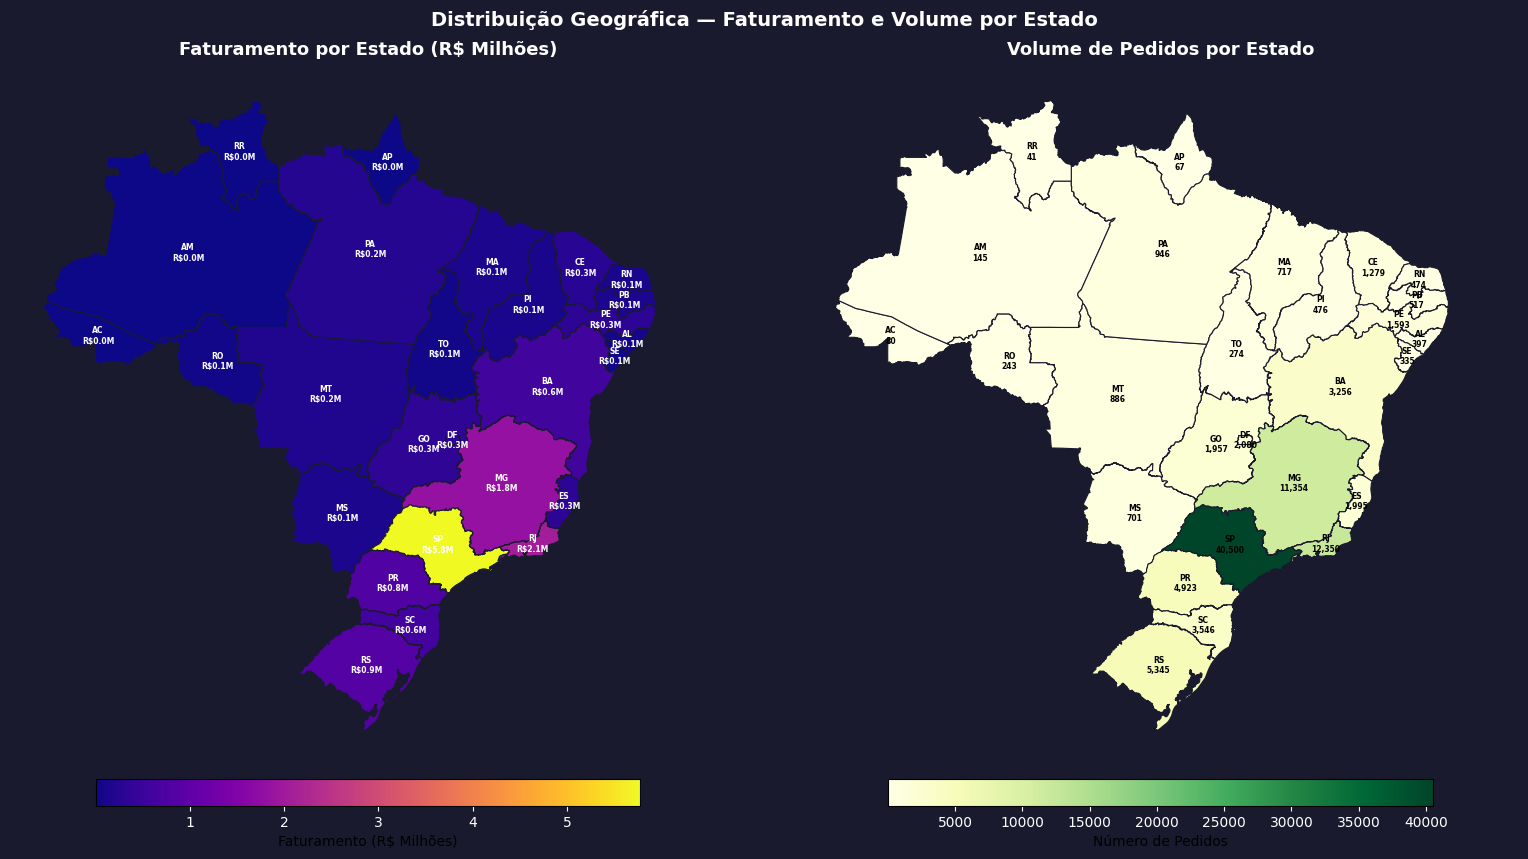

In [116]:
# Mapa coroplético — dois painéis: faturamento e volume de pedidos
# Usamos fundo escuro e paletas de cores vibrantes para maior contraste visual
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.patch.set_facecolor('#1A1A2E')  # mesmo fundo do dashboard

for ax in axes:
    ax.set_facecolor('#1A1A2E')
    ax.set_axis_off()

# Painel 1 — Faturamento por estado
# plasma: roxo (baixo) → laranja → amarelo (alto) — muito mais visível que YlOrRd
gdf_plot.plot(
    column='receita_M',
    ax=axes[0],
    cmap='plasma',           # paleta vibrante que combina com o dashboard
    edgecolor='#1A1A2E',
    linewidth=0.8,
    missing_kwds={'color': '#2C2C54'},
    legend=True,
    legend_kwds={
        'label': 'Faturamento (R$ Milhões)',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02,
    }
)

# Anotar sigla + valor no centroide de cada estado
for _, row in gdf_plot.iterrows():
    if row.geometry is not None and row['receita'] > 0:
        axes[0].annotate(
            f"{row['sigla']}\nR${row['receita_M']:.1f}M",
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha='center', va='center', fontsize=5.5,
            color='white', fontweight='bold'
        )

axes[0].set_title('Faturamento por Estado (R$ Milhões)',
                  color='white', fontweight='bold', fontsize=13, pad=10)

# Painel 2 — Volume de pedidos
# YlGn: amarelo → verde — contraste com o plasma do painel 1
gdf_plot.plot(
    column='pedidos',
    ax=axes[1],
    cmap='YlGn',
    edgecolor='#1A1A2E',
    linewidth=0.8,
    missing_kwds={'color': '#2C2C54'},
    legend=True,
    legend_kwds={
        'label': 'Número de Pedidos',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02,
    }
)

for _, row in gdf_plot.iterrows():
    if row.geometry is not None and row['pedidos'] > 0:
        axes[1].annotate(
            f"{row['sigla']}\n{int(row['pedidos']):,}",
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha='center', va='center', fontsize=5.5,
            color='black', fontweight='bold'
        )

axes[1].set_title('Volume de Pedidos por Estado',
                  color='white', fontweight='bold', fontsize=13, pad=10)

# Ajustar colorbars para texto branco
for ax in axes:
    for child in ax.get_figure().get_axes():
        if child != axes[0] and child != axes[1]:
            child.tick_params(colors='white')
            child.yaxis.label.set_color('white')

plt.suptitle('Distribuição Geográfica — Faturamento e Volume por Estado',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> **Conclusão:** SP concentra o maior faturamento (R$5.8M) e volume (40.500 pedidos). Norte e Centro-Oeste têm potencial de crescimento.


---
## 35. Dashboard de KPIs

Painel com os principais indicadores do negócio em uma única tela.


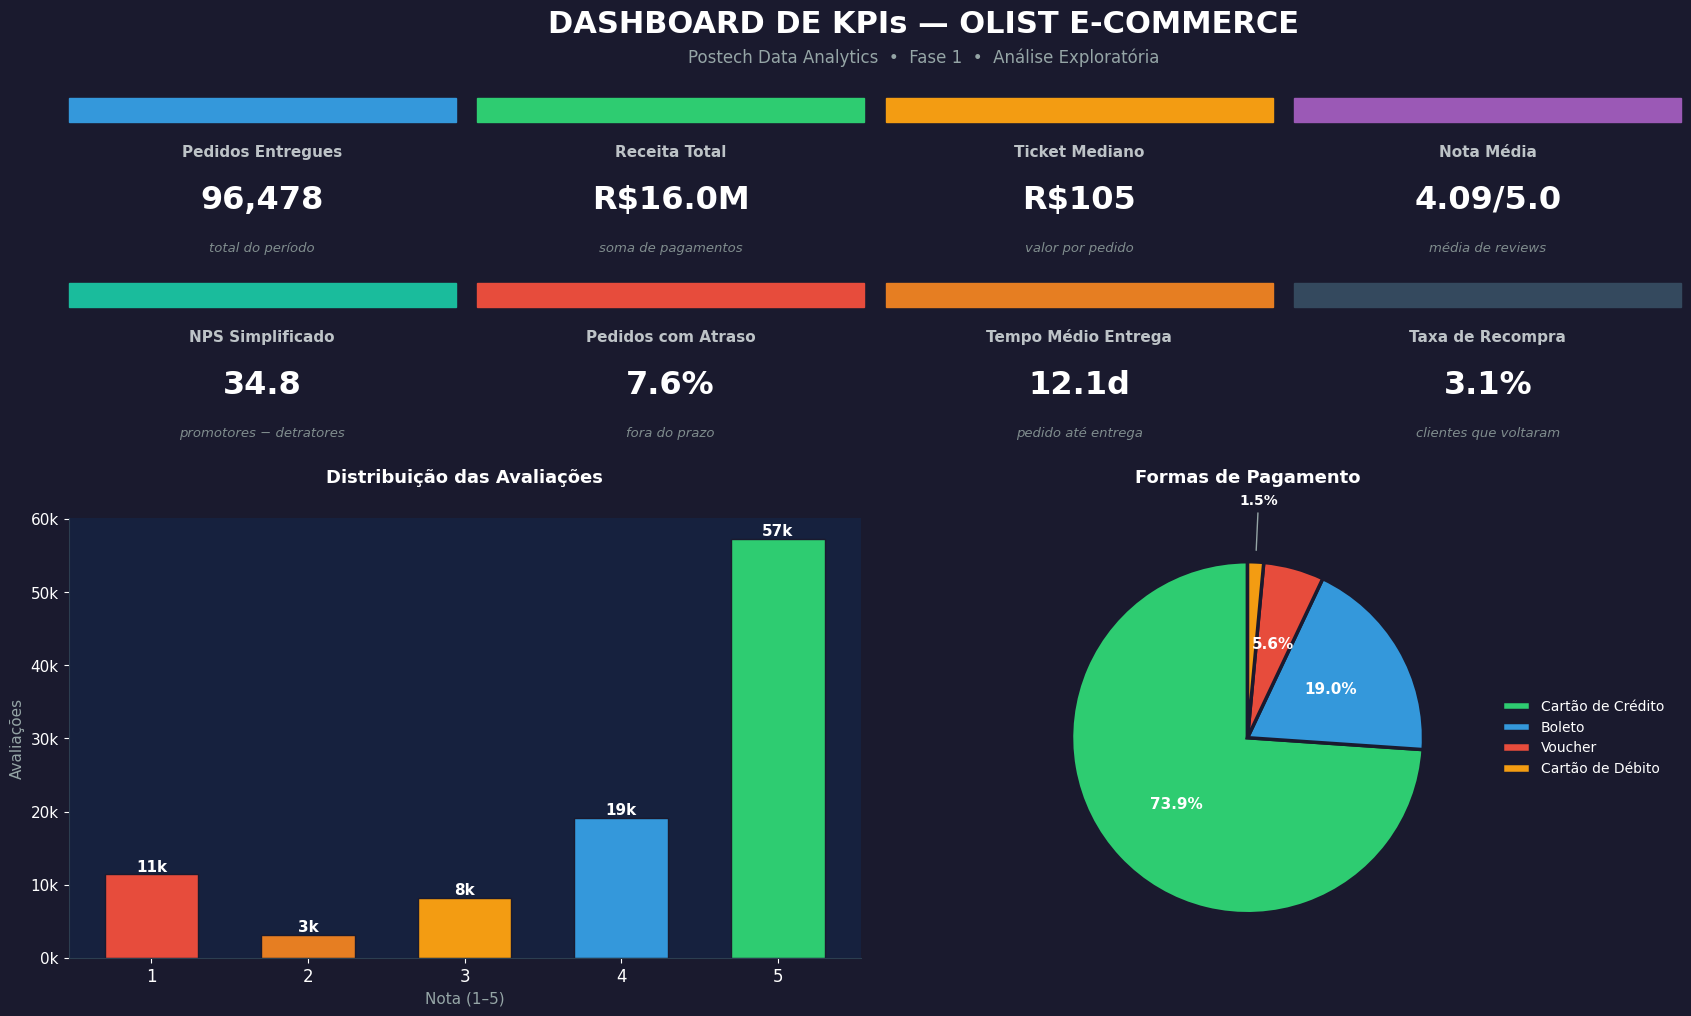

Dashboard completo!


In [118]:
# Calcular todos os KPIs
df_del = orders[orders['order_status']=='delivered'].copy()
df_del['dias_entrega'] = (df_del['order_delivered_customer_date'] - df_del['order_purchase_timestamp']).dt.days
df_del['dias_est']     = (df_del['order_estimated_delivery_date'] - df_del['order_purchase_timestamp']).dt.days
df_del['atrasou']      = df_del['dias_entrega'] > df_del['dias_est']

score_dist2  = reviews['review_score'].value_counts().sort_index()
total_rev2   = score_dist2.sum()
nps2         = score_dist2[5]/total_rev2*100 - (score_dist2[1]+score_dist2[2]+score_dist2[3])/total_rev2*100

ticket_med    = payments.groupby('order_id')['payment_value'].sum().median()
receita_total = payments['payment_value'].sum()
clientes2     = customers.merge(orders[['order_id','customer_id']], on='customer_id')
recompra2     = (clientes2.groupby('customer_unique_id').size() > 1).mean() * 100

kpis = [
    ('Pedidos Entregues',   f'{len(df_del):,}',                        'total do período',       '#3498DB'),
    ('Receita Total',       f'R${receita_total/1e6:.1f}M',             'soma de pagamentos',      '#2ECC71'),
    ('Ticket Mediano',      f'R${ticket_med:.0f}',                     'valor por pedido',        '#F39C12'),
    ('Nota Média',          f'{reviews["review_score"].mean():.2f}/5.0','média de reviews',       '#9B59B6'),
    ('NPS Simplificado',    f'{nps2:.1f}',                             'promotores − detratores', '#1ABC9C'),
    ('Pedidos com Atraso',  f'{df_del["atrasou"].mean()*100:.1f}%',    'fora do prazo',           '#E74C3C'),
    ('Tempo Médio Entrega', f'{df_del["dias_entrega"].mean():.1f}d',   'pedido até entrega',      '#E67E22'),
    ('Taxa de Recompra',    f'{recompra2:.1f}%',                       'clientes que voltaram',   '#34495E'),
]

BG  = '#1A1A2E'
CRD = '#16213E'

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)

fig.text(0.5, 0.975, 'DASHBOARD DE KPIs — OLIST E-COMMERCE',
         ha='center', fontsize=22, fontweight='bold', color='white')
fig.text(0.5, 0.945, 'Postech Data Analytics  •  Fase 1  •  Análise Exploratória',
         ha='center', fontsize=12, color='#95A5A6')

# 8 cards em 2 linhas de 4
CW = 0.215; CH = 0.165; GAP = 0.012
START_X = 0.025
ROW1_Y  = 0.745
ROW2_Y  = 0.560

for idx, (nome, valor, sub, cor) in enumerate(kpis):
    col = idx % 4
    row = idx // 4
    x   = START_X + col * (CW + GAP)
    y   = ROW1_Y if row == 0 else ROW2_Y

    ax = fig.add_axes([x, y, CW, CH])
    ax.set_facecolor(CRD)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.add_patch(plt.Rectangle((0, 0.85), 1, 0.15, color=cor,
                                transform=ax.transAxes, clip_on=False))
    ax.text(0.5, 0.67, nome,  ha='center', va='center', fontsize=11,
            color='#BDC3C7', fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.38, valor, ha='center', va='center', fontsize=23,
            color='white', fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.09, sub,   ha='center', va='center', fontsize=9.5,
            color='#7F8C8D', style='italic', transform=ax.transAxes)

# Título distribuição
fig.text(0.245, 0.525, 'Distribuição das Avaliações',
         ha='center', fontsize=13, fontweight='bold', color='white')

# Gráfico 1 — Distribuição das Avaliações
ax1 = fig.add_axes([0.025, 0.05, 0.44, 0.44])
ax1.set_facecolor(CRD)
cores_s = [CORES[2], '#E67E22', CORES[3], CORES[1], CORES[0]]
bars = ax1.bar(score_dist2.index, score_dist2.values,
               color=cores_s, edgecolor=BG, width=0.6)
ax1.tick_params(axis='x', colors='white', labelsize=12)
ax1.tick_params(axis='y', colors='white', labelsize=11)
ax1.set_xlabel('Nota (1–5)', color='#95A5A6', fontsize=11)
ax1.set_ylabel('Avaliações',  color='#95A5A6', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
for sp in ['left','bottom']: ax1.spines[sp].set_color('#2C3E50')
for bar, v in zip(bars, score_dist2.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
             f'{v/1000:.0f}k', ha='center', color='white', fontsize=11, fontweight='bold')

# Título pizza
fig.text(0.68, 0.525, 'Formas de Pagamento',
         ha='center', fontsize=13, fontweight='bold', color='white')

# Gráfico 2 — Formas de Pagamento
# Solução para fatias pequenas: usar annotate manual em vez de autopct
ax2 = fig.add_axes([0.50, 0.05, 0.36, 0.44])
ax2.set_facecolor(BG)
pay_v = payments[payments['payment_type'] != 'not_defined']
vol_p = pay_v.groupby('payment_type').size().sort_values(ascending=False)
nomes_pay = {'credit_card':'Cartão de Crédito','boleto':'Boleto',
             'voucher':'Voucher','debit_card':'Cartão de Débito'}
vol_p.index = [nomes_pay.get(x, x) for x in vol_p.index]
pcts = vol_p.values / vol_p.values.sum() * 100

# Sem autopct — vamos anotar manualmente para controlar posição
wedges, _ = ax2.pie(
    vol_p.values,
    labels=None,
    autopct=None,
    colors=CORES[:4],
    startangle=90,
    wedgeprops={'edgecolor': BG, 'linewidth': 2.5}
)

# Anotar cada fatia manualmente — posição calculada pelo ângulo médio de cada wedge
import numpy as np
angulo_acum = 90  # startangle
for wedge, pct in zip(wedges, pcts):
    angulo = (wedge.theta1 + wedge.theta2) / 2  # ângulo médio da fatia
    rad = np.deg2rad(angulo)
    # fatias grandes: % dentro | fatias pequenas: % fora com linha
    if pct > 5:
        r = 0.55  # dentro
        ax2.annotate(f'{pct:.1f}%',
                     xy=(r * np.cos(rad), r * np.sin(rad)),
                     ha='center', va='center',
                     color='white', fontsize=11, fontweight='bold')
    else:
        r_in  = 1.05  # ponto na borda da fatia
        r_out = 1.35  # ponto do texto, bem afastado
        ax2.annotate(f'{pct:.1f}%',
                     xy=(r_in * np.cos(rad), r_in * np.sin(rad)),
                     xytext=(r_out * np.cos(rad), r_out * np.sin(rad)),
                     ha='center', va='center',
                     color='white', fontsize=10, fontweight='bold',
                     arrowprops=dict(arrowstyle='-', color='#95A5A6', lw=1))

# Legenda com nomes
ax2.legend(wedges, vol_p.index, loc='center left',
           bbox_to_anchor=(1.05, 0.5), fontsize=10,
           labelcolor='white', frameon=False)

plt.show()
print('Dashboard completo!')

---
## 36. Conclusão e Recomendações Estratégicas

### O que os dados revelam

A Olist cresceu de forma consistente entre 2017 e 2018, com aumento de +303% no faturamento trimestral de Q1/2017 a Q2/2018. O crescimento foi sustentado por volume de novos clientes — o ticket mediano permaneceu estável em R$105 ao longo de todo o período, o que indica que o negócio expandiu sua base, não o valor médio por compra.

A sazonalidade é estrutural: maio é o mês de maior faturamento (Dia das Mães) e setembro o de menor. O padrão se repetiu em 2017 e 2018, o que permite planejamento antecipado de estoque e campanhas. O pico de compras acontece às segundas-feiras entre 11h e 16h — horário de expediente e intervalo do almoço.

---

### O principal problema identificado

**O atraso na entrega é o fator que mais prejudica a satisfação.** Pedidos entregues no prazo têm nota média de 4.29. Pedidos atrasados caem para 2.46 — uma redução de 1.83 pontos. Com apenas 7.6% de pedidos atrasados, o impacto no NPS é desproporcional.

O gargalo está na **etapa de transporte**, que responde por 74% do tempo total de entrega e aumenta 225% nos pedidos atrasados (de 7.9 para 25.7 dias). Aprovação e postagem têm impacto marginal em comparação.

A raiz do problema é geográfica: a correlação entre distância e atraso é r=0.727 (p<0.000001) e entre distância e nota é r=−0.646 (p=0.000005) — estatisticamente comprovado. Os vendedores estão concentrados no Sudeste e os clientes espalhados pelo Brasil. Pedidos acima de 1.000 km demoram 3x mais e têm o dobro de atrasos.

Há ainda um elo ignorado: 17.5% dos pedidos têm aprovação de pagamento acima de 24h (boleto bancário). Esses pedidos saem com atraso antes mesmo de serem enviados.

A satisfação também não cai de forma linear com o atraso — existe um **limiar crítico entre 3 e 4 dias**: até 3 dias a nota cai gradualmente; acima de 4 dias despenca para menos de 2.7 e não melhora mais, independente da duração do atraso.

---

### Retenção é o maior risco não precificado

A taxa de recompra é de 3.1% — 96.9% dos clientes compram apenas uma vez. Em e-commerces maduros, essa taxa costuma ser de 20–40%. O custo de reativação de um cliente existente é 5–7x menor do que adquirir um novo, o que torna esse o ponto de maior retorno disponível.

O LTV reforça o argumento: clientes que compram 2 vezes valem 1.8x mais (R$291 vs R$161). Clientes com 3+ compras valem 3.1x mais (R$507). Há também uma relação temporal clara: à medida que o frete cresceu +318% de Q1/2017 a Q2/2018, a taxa de recompra caiu de 5.1% para 3.9% — o custo logístico percebido pelo cliente desincentiva a segunda compra.

---

### Recomendações

**1. Reduzir atrasos acima de 3 dias — não apenas cumprir o prazo**
A meta operacional deve ser evitar atrasos acima de 3 dias, que é o limiar onde o cliente perde a tolerância. Incentivar pagamentos via Pix ou cartão (aprovação imediata) elimina o atraso causado pelo boleto antes mesmo do envio.

**2. Expandir a presença logística no Norte e Nordeste**
Os 5 estados com maior ticket médio são todos do Norte e Nordeste — Paraíba (R$267), Alagoas (R$237), Pará (R$224). O frete nessas rotas representa mais de 25% do valor do produto. Sellers locais reduziriam o frete e os atrasos simultaneamente.

**3. Criar um programa de recompra**
Elevar a taxa de recompra de 3.1% para 8% representaria aproximadamente 4.800 pedidos adicionais por ano sem custo de aquisição. E-mail de reativação 30 dias após a compra e cupom exclusivo na segunda compra são pontos de partida simples.

**4. Exigir mínimo de 4 fotos no cadastro de produto**
Produtos com 5+ fotos têm nota consistentemente acima de 4.10 contra 4.00 dos produtos com 1 foto. A correlação é estatisticamente real (p<0.001). Custo de implementação baixo, impacto direto na satisfação.

**5. Campanhas no horário e dia de pico**
Segunda-feira entre 10h e 16h concentra o maior volume de compras. Campanhas de e-mail e push notification enviadas nesse horário têm maior probabilidade de conversão. Promoções de fim de semana podem reduzir a queda de sábado, que tem 35% menos pedidos que segunda.

---

### Limitações

Esta análise cobre aproximadamente 20 meses de dados (2017–2018), sem informações de margem operacional ou custo por pedido. Os dados de geolocalização dependem do arquivo `olist_geolocation_dataset.csv`, que por seu tamanho não está versionado no repositório.